<a href="https://colab.research.google.com/github/s4tlaw/KTH_AH2179/blob/main/AH2179_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# f_pred at portal 8

## Data-Preprocess

[evaluation_dataset] 803,377 rows -> 180,876 for portals [7, 8]; 88 date(s), 2022-01-01 -> 2022-06-25
[final_evaluation_dataset] 803,501 rows -> 184,456 for portals [7, 8]; 90 date(s), 2022-01-05 -> 2022-06-30

[Merge check] shared row keys: 0; conflicting: 0 (0.00%); shared minutes under different sensor keys: 0.00%; duplicates inside files: A=0, B=0
[Merge check] dates present in both files: 0
[Merge] merged raw rows: 365,332 (A 180,876 + B 184,456; 0 shared copies removed)

[Filter] 175 of 181 calendar dates kept; 6 excluded (3 missing, 3 bad).

VALIDATION
All checks passed.
Rows: 126,312; days: 175; portals: [np.int64(7), np.int64(8)]
Range: 2022-01-01 04:00:00 -> 2022-06-30 10:00:00
Median spacing (portal 8): 60s
Zero-flow minutes: 0.3% of all processed rows

[Save] Processed evaluation file: /content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv

Files merged: evaluation_dataset (180,876 rows), final_evaluation_dataset (184,456 rows) -> 365,332 raw rows
S

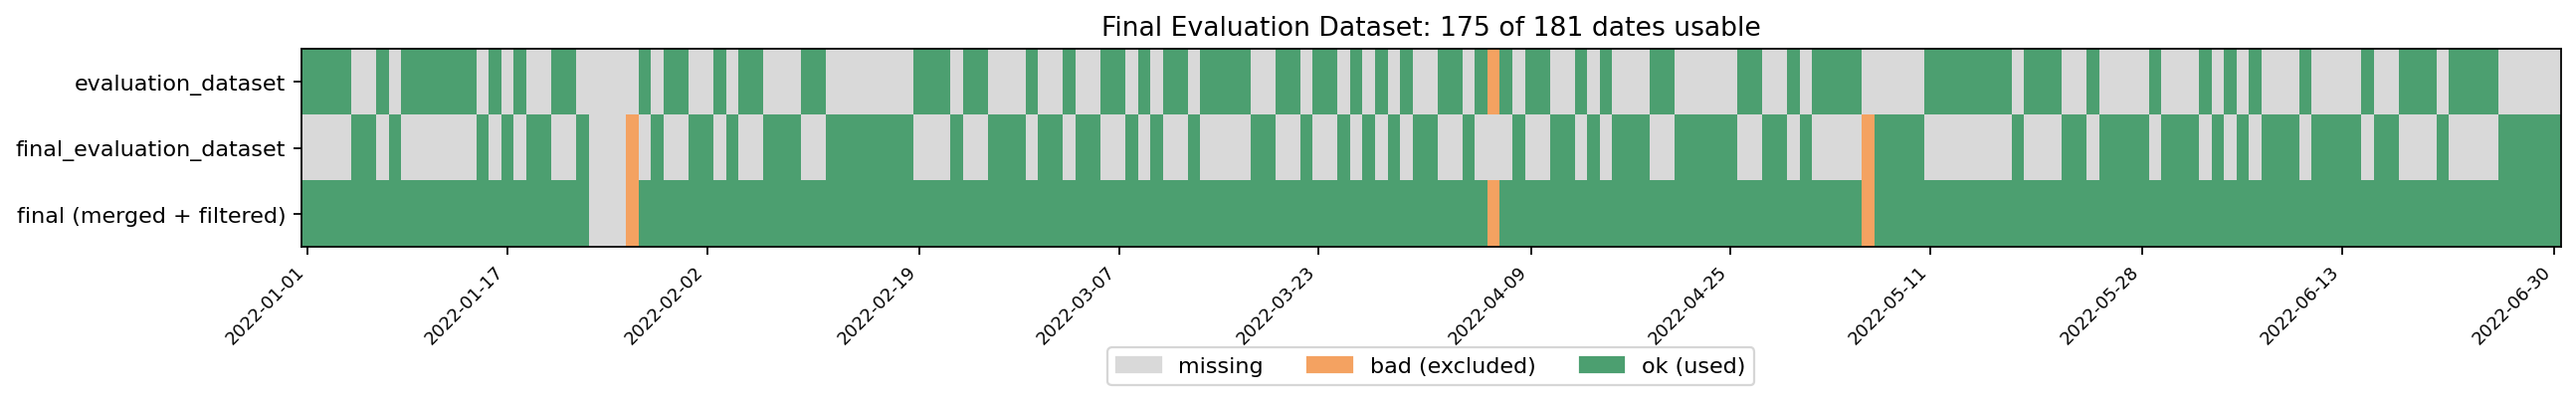

In [ ]:
"""
Merged Evaluation Data Preprocessing (standalone; separate from prediction/evaluation)
================================================================================
Turns the TWO raw evaluation files into ONE clean, model-ready 1-minute file.

    evaluation_dataset.csv  +  final_evaluation_dataset.csv
        -> row-level merge (shared rows kept once; unique rows all kept)
        -> day-quality filter (drops dates that are missing or effectively dead)
        -> same preprocessing as training (sensors combined per minute, 1-minute bins)
        -> processed_merged_evaluation_df_1min.csv   (columns: sequence, DateTime, v, f)

WHY NOT JUST CONCATENATE: preprocessing SUMS flow over rows within a minute, so any
row present in both files would be counted twice. Shared rows are therefore kept once.

WHY EXCLUDED DAYS ARE REMOVED HERE (not zero-filled): the earlier pipeline resampled
over the whole date range, which silently created all-zero rows for missing dates. Those
zero rows looked like complete data and passed the row-count coverage check, producing
the flat-zero "actual" days seen in the instance plots. This script resamples only
WITHIN each kept day, so removed dates simply do not exist downstream.

PREPROCESSING RULES (identical to the training pipeline):
  - PORTAL "E4S 56,160" -> numeric id -> sequence (56160 -> 7, 55620 -> 8)
  - DateTime = Date + Time
  - sensors combined per timestamp: v = mean of non-zero speeds (0.0 if none), f = sum of flow
  - 1-minute bins per portal; empty minutes inside a day -> v = 0, f = 0
  - only portals 7 and 8 are kept (the models use no others)

DAY QUALITY RULE (a date is kept only if BOTH portals pass):
  - >= 50% of minutes in 07:30-08:45 have non-zero flow, and
  - >= 20% of minutes in 04:00-07:30 have non-zero flow.

SAFETY STOP: if the files disagree on shared rows, or describe the same minutes with
different sensor IDs beyond the limits below, the script stops instead of merging,
unless FORCE_MERGE = True.

OUTPUTS (output/data_processing_eval/)
  excluded_days.csv             dates removed, with the reason and quality figures
  day_quality_final.csv         per date x portal quality figures (merged data)
  processing_report.txt         summary of what was done
  chart_final_date_status.png   date status for each file and the final dataset
  processed file                Drive: .../Colab/processed_merged_evaluation_df_1min.csv
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# =============================================================================
# CONFIGURATION
# =============================================================================

FILE_A = '/content/drive/MyDrive/AH2179 GP5/Colab/evaluation_dataset.csv'
FILE_B = '/content/drive/MyDrive/AH2179 GP5/Colab/final_evaluation_dataset.csv'
LABEL_A, LABEL_B = 'evaluation_dataset', 'final_evaluation_dataset'

PROCESSED_OUT = '/content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv'
SAVE_MERGED_RAW = False
MERGED_RAW_OUT = '/content/drive/MyDrive/AH2179 GP5/Colab/merged_evaluation_dataset.csv'

OUTPUT_DIR = 'output/data_processing_eval'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PORTALS = [7, 8]
PORTAL_SEQUENCE = {58140: 1, 57820: 2, 57435: 3, 57055: 4, 56780: 5, 56490: 6, 56160: 7, 55620: 8}
INTERVAL_MINUTES = 1

AM_START, AM_END = pd.Timestamp('1900-01-01 07:30').time(), pd.Timestamp('1900-01-01 08:45').time()
EARLY_START, EARLY_END = pd.Timestamp('1900-01-01 04:00').time(), pd.Timestamp('1900-01-01 07:30').time()
AM_MINUTES, EARLY_MINUTES = 76, 210
AM_ZERO_MAX, EARLY_ZERO_MAX = 0.50, 0.80

CONFLICT_TOLERANCE = 1e-6
SAFE_MAX_CONFLICT_SHARE = 0.01
SAFE_MAX_SENSOR_MISMATCH_SHARE = 0.05
FORCE_MERGE = False

# =============================================================================
# LOADING
# =============================================================================

def detect_separator(path):
    with open(path, 'r', encoding='utf-8-sig') as fh:
        header = fh.readline()
    return ';' if header.count(';') >= header.count(',') else ','


def load_raw(path, label):
    if not os.path.isfile(path):
        raise FileNotFoundError(f'{label}: file not found: {path}')
    sep = detect_separator(path)
    df = pd.read_csv(path, sep=sep)
    df.columns = [c.strip() for c in df.columns]
    need = ['PORTAL', 'Date', 'Time', 'SPEED_MS_AVG', 'FLOW']
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise KeyError(f'{label}: missing column(s) {miss}. Found: {list(df.columns)}')
    original_columns = list(df.columns)
    n_all = len(df)

    pid = df['PORTAL'].astype(str).str.replace('E4S ', '', regex=False).str.replace(',', '', regex=False)
    df['sequence'] = pd.to_numeric(pid, errors='coerce').map(PORTAL_SEQUENCE)
    df = df[df['sequence'].isin(PORTALS)].copy()
    df['sequence'] = df['sequence'].astype(int)
    df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
    df['Minute'] = df['DateTime'].dt.floor('min')
    df['DateOnly'] = df['DateTime'].dt.date
    speed = pd.to_numeric(df['SPEED_MS_AVG'], errors='coerce')
    df['_vpos'] = speed.where(speed > 0)
    df['_flow'] = pd.to_numeric(df['FLOW'], errors='coerce')
    key_cols = [c for c in ['DP_ID', 'PORTAL', 'Date', 'Time'] if c in df.columns]
    df['_key'] = df[key_cols].astype(str).agg('|'.join, axis=1)
    print(f'[{label}] {n_all:,} rows -> {len(df):,} for portals {PORTALS}; {df.DateOnly.nunique()} date(s), '
          f'{df.DateOnly.min()} -> {df.DateOnly.max()}')
    return df, key_cols, original_columns


df_a, keys_a_cols, cols_a = load_raw(FILE_A, LABEL_A)
df_b, keys_b_cols, cols_b = load_raw(FILE_B, LABEL_B)
if keys_a_cols != keys_b_cols:
    raise ValueError(f'Row-key columns differ: {keys_a_cols} vs {keys_b_cols}')

# =============================================================================
# DAY QUALITY
# =============================================================================

def daily_quality(df):
    g = df.groupby(['sequence', 'Minute'], as_index=False).agg(f=('_flow', 'sum'))
    g['Date'] = g['Minute'].dt.date
    g['tod'] = g['Minute'].dt.time
    g['nz'] = (g['f'] > 0).astype(int)
    rows = df.groupby(['DateOnly', 'sequence']).size().rename('raw_rows')
    rows.index.names = ['Date', 'sequence']
    parts = [rows]
    for name, cond in {'am': (g.tod >= AM_START) & (g.tod <= AM_END),
                       'early': (g.tod >= EARLY_START) & (g.tod < EARLY_END)}.items():
        parts.append(g[cond].groupby(['Date', 'sequence']).agg(
            **{f'{name}_minutes_present': ('Minute', 'nunique'), f'{name}_nonzero_minutes': ('nz', 'sum')}))
    q = pd.concat(parts, axis=1).fillna(0).reset_index()
    q['am_nonzero_frac'] = q['am_nonzero_minutes'] / AM_MINUTES
    q['early_nonzero_frac'] = q['early_nonzero_minutes'] / EARLY_MINUTES
    q['portal_ok'] = (q['am_nonzero_frac'] >= 1 - AM_ZERO_MAX) & (q['early_nonzero_frac'] >= 1 - EARLY_ZERO_MAX)
    return q


def day_status(q, dates):
    """0 = missing, 1 = bad, 2 = ok. Also a 0-1 quality score used to rank the files per date."""
    status, score = {}, {}
    for d in dates:
        s = q[q.Date == d]
        if s.empty or s.raw_rows.sum() == 0:
            status[d], score[d] = 0, 0.0
            continue
        present = set(s.sequence)
        ok = all(p in present for p in PORTALS) and bool(s.portal_ok.all())
        status[d] = 2 if ok else 1
        score[d] = float(np.mean([
            ((s[s.sequence == p].am_nonzero_frac.iloc[0] + s[s.sequence == p].early_nonzero_frac.iloc[0]) / 2)
            if p in present else 0.0 for p in PORTALS]))
    idx = pd.Index(dates)
    return pd.Series(status).set_axis(idx), pd.Series(score).set_axis(idx)


all_dates = list(pd.date_range(min(df_a.DateOnly.min(), df_b.DateOnly.min()),
                               max(df_a.DateOnly.max(), df_b.DateOnly.max()), freq='D').date)
q_a, q_b = daily_quality(df_a), daily_quality(df_b)
status_a, score_a = day_status(q_a, all_dates)
status_b, score_b = day_status(q_b, all_dates)

# =============================================================================
# MERGE SAFETY CHECKS AND ROW-LEVEL MERGE
# =============================================================================

dup_a, dup_b = int(df_a.duplicated('_key').sum()), int(df_b.duplicated('_key').sum())
shared_keys = pd.Index(df_a['_key'].unique()).intersection(pd.Index(df_b['_key'].unique()))

a_u, b_u = df_a.drop_duplicates('_key').set_index('_key'), df_b.drop_duplicates('_key').set_index('_key')
shared = a_u.loc[shared_keys, ['_vpos', '_flow', 'sequence', 'Minute']].join(
    b_u.loc[shared_keys, ['_vpos', '_flow']], rsuffix='_b')
same = (np.isclose(shared['_vpos'].fillna(-1), shared['_vpos_b'].fillna(-1), atol=CONFLICT_TOLERANCE) &
        np.isclose(shared['_flow'].fillna(-1), shared['_flow_b'].fillna(-1), atol=CONFLICT_TOLERANCE))
n_shared, n_conflict = len(shared), int((~same).sum())
conflict_share = n_conflict / n_shared if n_shared else 0.0

min_a = pd.MultiIndex.from_frame(df_a[['sequence', 'Minute']].drop_duplicates())
min_b = pd.MultiIndex.from_frame(df_b[['sequence', 'Minute']].drop_duplicates())
minutes_both = min_a.intersection(min_b)
shared_minutes = pd.MultiIndex.from_frame(shared[['sequence', 'Minute']].drop_duplicates())
mismatch_share = (len(minutes_both.difference(shared_minutes)) / len(minutes_both)) if len(minutes_both) else 0.0

print(f'\n[Merge check] shared row keys: {n_shared:,}; conflicting: {n_conflict:,} ({conflict_share:.2%}); '
      f'shared minutes under different sensor keys: {mismatch_share:.2%}; '
      f'duplicates inside files: A={dup_a:,}, B={dup_b:,}')
overlap_dates = sorted(set(df_a.DateOnly.unique()) & set(df_b.DateOnly.unique()))
print(f'[Merge check] dates present in both files: {len(overlap_dates)}')

safe = conflict_share <= SAFE_MAX_CONFLICT_SHARE and mismatch_share <= SAFE_MAX_SENSOR_MISMATCH_SHARE
if not safe and not FORCE_MERGE:
    raise RuntimeError(
        'Merge judged UNSAFE: the files disagree on shared rows '
        f'({conflict_share:.1%}) or use different sensor keys for the same minutes ({mismatch_share:.1%}). '
        'Run v8_check_merge_evaluation_datasets.py and inspect its sample files, or set FORCE_MERGE = True.')
if not safe:
    print('[Merge check] WARNING: unsafe merge forced by FORCE_MERGE = True.')

prefer_b = pd.Series({d: score_b[d] > score_a[d] for d in all_dates})      # ties -> file A
a_rows, b_rows = df_a.copy(), df_b.copy()
a_rows['_pb'], b_rows['_pb'] = a_rows['DateOnly'].map(prefer_b), b_rows['DateOnly'].map(prefer_b)
merged = pd.concat([a_rows[~(a_rows['_key'].isin(shared_keys) & a_rows['_pb'])],
                    b_rows[~(b_rows['_key'].isin(shared_keys) & ~b_rows['_pb'])]], ignore_index=True)
merged = merged.sort_values(['sequence', 'DateTime']).reset_index(drop=True)
print(f'[Merge] merged raw rows: {len(merged):,} (A {len(df_a):,} + B {len(df_b):,}; '
      f'{len(df_a) + len(df_b) - len(merged):,} shared copies removed)')

if SAVE_MERGED_RAW:
    out_cols = [c for c in cols_a if c in merged.columns]
    merged[out_cols].to_csv(MERGED_RAW_OUT, sep=';', index=False)
    print(f'[Merge] merged raw file saved: {MERGED_RAW_OUT}')

# =============================================================================
# DAY FILTER ON THE MERGED DATA
# =============================================================================

q_m = daily_quality(merged)
status_m, _ = day_status(q_m, all_dates)
ok_dates = [d for d in all_dates if status_m[d] == 2]

reason_rows = []
for d in all_dates:
    if status_m[d] == 2:
        continue
    s = q_m[q_m.Date == d]
    if status_m[d] == 0:
        reason = 'missing: no rows in either file'
    else:
        bad = []
        for p in PORTALS:
            sp = s[s.sequence == p]
            if sp.empty:
                bad.append(f'portal {p}: no rows')
            elif not bool(sp.portal_ok.iloc[0]):
                bad.append(f'portal {p}: non-zero-flow share AM {sp.am_nonzero_frac.iloc[0]:.0%}, '
                           f'early {sp.early_nonzero_frac.iloc[0]:.0%}')
        reason = 'bad: ' + '; '.join(bad)
    reason_rows.append({'Date': d, 'Status': 'missing' if status_m[d] == 0 else 'bad', 'Reason': reason,
                        'In_file_A': d in set(df_a.DateOnly), 'In_file_B': d in set(df_b.DateOnly)})
excluded = pd.DataFrame(reason_rows, columns=['Date', 'Status', 'Reason', 'In_file_A', 'In_file_B'])
excluded.to_csv(os.path.join(OUTPUT_DIR, 'excluded_days.csv'), index=False)
q_m.round(4).to_csv(os.path.join(OUTPUT_DIR, 'day_quality_final.csv'), index=False)

if not ok_dates:
    raise ValueError('No date passed the quality rule; check thresholds and the input files.')
kept = merged[merged['DateOnly'].isin(set(ok_dates))].copy()
print(f'\n[Filter] {len(ok_dates)} of {len(all_dates)} calendar dates kept; '
      f'{len(excluded)} excluded ({int((excluded.Status == "missing").sum())} missing, '
      f'{int((excluded.Status == "bad").sum())} bad).')

# =============================================================================
# PREPROCESS TO 1-MINUTE FORMAT (mirrors training; resampled only WITHIN each day)
# =============================================================================

# Stage 1: combine sensors per exact timestamp (mean of non-zero speeds, sum of flow).
stage1 = kept.groupby(['sequence', 'DateTime']).agg(v=('_vpos', 'mean'), f=('_flow', 'sum')).reset_index()
stage1['v'] = stage1['v'].fillna(0.0)
stage1['Minute'] = stage1['DateTime'].dt.floor(f'{INTERVAL_MINUTES}min')
stage1['Date'] = stage1['Minute'].dt.date
stage1['v_pos'] = stage1['v'].where(stage1['v'] > 0)

# Stage 2: 1-minute bins, continuous inside each portal-day only.
parts = []
for (seq, date), g in stage1.groupby(['sequence', 'Date']):
    per_min = g.groupby('Minute').agg(v=('v_pos', 'mean'), f=('f', 'sum'))
    idx = pd.date_range(per_min.index.min(), per_min.index.max(), freq=f'{INTERVAL_MINUTES}min')
    per_min = per_min.reindex(idx)
    per_min['v'] = per_min['v'].fillna(0.0)
    per_min['f'] = per_min['f'].fillna(0.0)
    per_min.index.name = 'DateTime'
    per_min['sequence'] = int(seq)
    parts.append(per_min.reset_index())
final_df = pd.concat(parts, ignore_index=True)[['sequence', 'DateTime', 'v', 'f']]
final_df = final_df.sort_values(['sequence', 'DateTime']).reset_index(drop=True)

# =============================================================================
# VALIDATION
# =============================================================================

problems = []
per_day = final_df.assign(Date=final_df.DateTime.dt.date).groupby('Date')['sequence'].nunique()
if (per_day < len(PORTALS)).any():
    problems.append(f'{int((per_day < len(PORTALS)).sum())} day(s) lack one of the portals')
if final_df[['v', 'f']].isna().any().any():
    problems.append('NaN values present in v/f')
if set(final_df.DateTime.dt.date.unique()) != set(ok_dates):
    problems.append('processed dates differ from the kept dates')
early_rows = final_df[(final_df.DateTime.dt.time >= EARLY_START) & (final_df.DateTime.dt.time < EARLY_END)]
min_early = early_rows.groupby([early_rows.sequence, early_rows.DateTime.dt.date]).size().min()
if min_early < 0.5 * EARLY_MINUTES:
    problems.append(f'some portal-day has only {min_early} early-morning rows')

print('\n' + '=' * 80 + '\nVALIDATION\n' + '=' * 80)
print('All checks passed.' if not problems else 'PROBLEMS: ' + '; '.join(problems))
print(f'Rows: {len(final_df):,}; days: {final_df.DateTime.dt.date.nunique()}; portals: {sorted(final_df.sequence.unique())}')
print(f'Range: {final_df.DateTime.min()} -> {final_df.DateTime.max()}')
print(f'Median spacing (portal 8): '
      f'{final_df[final_df.sequence == 8].DateTime.diff().dt.total_seconds().median():.0f}s')
print(f'Zero-flow minutes: {(final_df.f == 0).mean():.1%} of all processed rows')

# =============================================================================
# SAVE PROCESSED FILE + REPORT + CHART
# =============================================================================

try:
    os.makedirs(os.path.dirname(PROCESSED_OUT), exist_ok=True)
    final_df.to_csv(PROCESSED_OUT, index=False)
    saved_to = PROCESSED_OUT
except OSError as err:
    saved_to = os.path.join(OUTPUT_DIR, 'processed_merged_evaluation_df_1min.csv')
    final_df.to_csv(saved_to, index=False)
    print(f'[Save] Drive path unavailable ({err}); saved locally instead.')
print(f'\n[Save] Processed evaluation file: {saved_to}')

report = [
    f'Files merged: {LABEL_A} ({len(df_a):,} rows), {LABEL_B} ({len(df_b):,} rows) -> {len(merged):,} raw rows',
    f'Shared row keys: {n_shared:,}; conflicts: {n_conflict:,} ({conflict_share:.2%}); '
    f'sensor-mismatch share: {mismatch_share:.2%}; dates in both files: {len(overlap_dates)}',
    f'Calendar span: {all_dates[0]} -> {all_dates[-1]} ({len(all_dates)} dates)',
    f'Kept dates: {len(ok_dates)}; excluded: {len(excluded)} '
    f'({int((excluded.Status == "missing").sum())} missing, {int((excluded.Status == "bad").sum())} bad)',
    f'Processed rows: {len(final_df):,}', f'Processed file: {saved_to}', '',
    'Excluded dates:', ('\n'.join(f'  {r.Date}: {r.Reason}' for r in excluded.itertuples()) if len(excluded) else '  none'),
    '', 'NEXT STEP: point the prediction script (and clustering script) at the processed file above.',
]
with open(os.path.join(OUTPUT_DIR, 'processing_report.txt'), 'w') as fh:
    fh.write('\n'.join(report))

grid = np.vstack([status_a.to_numpy(), status_b.to_numpy(), status_m.to_numpy()])
fig, ax = plt.subplots(figsize=(max(10, len(all_dates) * 0.09), 3.2))
ax.imshow(grid, aspect='auto', cmap=ListedColormap(['#d9d9d9', '#f4a261', '#4c9f70']), vmin=0, vmax=2,
          interpolation='nearest')
ax.set_yticks([0, 1, 2]); ax.set_yticklabels([LABEL_A, LABEL_B, 'final (merged + filtered)'])
ticks = np.linspace(0, len(all_dates) - 1, min(12, len(all_dates))).astype(int)
ax.set_xticks(ticks); ax.set_xticklabels([str(all_dates[i]) for i in ticks], rotation=45, ha='right', fontsize=8)
ax.legend(handles=[Patch(color='#d9d9d9', label='missing'), Patch(color='#f4a261', label='bad (excluded)'),
                   Patch(color='#4c9f70', label='ok (used)')], loc='upper center',
          bbox_to_anchor=(0.5, -0.45), ncol=3)
ax.set_title(f'Final Evaluation Dataset: {len(ok_dates)} of {len(all_dates)} dates usable')
fig.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'chart_final_date_status.png')
fig.savefig(chart_path, dpi=160, bbox_inches='tight'); plt.close(fig)

print('\n' + '\n'.join(report))
try:
    from IPython.display import display, Image
    display(Image(filename=chart_path))
except ImportError:
    pass

## Run evaluation dataset with model

[Models] All three f models loaded and feature/target contracts match.
  {'Model': 'XGBoost', 'N_features': 18, 'Smooth_window': 5, 'Predict_delta': False, 'Forecast_steps': 15}
  {'Model': 'Ridge', 'N_features': 18, 'Smooth_window': 5, 'Predict_delta': False, 'Forecast_steps': 15}
  {'Model': 'Neural Network', 'N_features': 18, 'Smooth_window': 5, 'Predict_delta': False, 'Forecast_steps': 15}
[Data] /content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv: 126,312 rows; 175 day(s); 2022-01-01 04:00:00 -> 2022-06-30 10:00:00

[Features] Rebuilding one shared evaluation feature frame...
  [C_max] portal 7: 175 of 175 day(s) usable
  [C_max] portal 8: 175 of 175 day(s) usable
[Features] corridor=(63155, 20); valid days=175

PRIMARY FAIR COMPARISON: f FORECAST vs 5-MIN-SMOOTHED TARGET
         Model  Horizon_min     N    MAE   RMSE  MAPE_pct  sMAPE_pct     R2   Bias  MAE_Skill_vs_Persistence
Neural Network            1 10675 2.8759 3.9030    8.2770     7.4991 0.9251

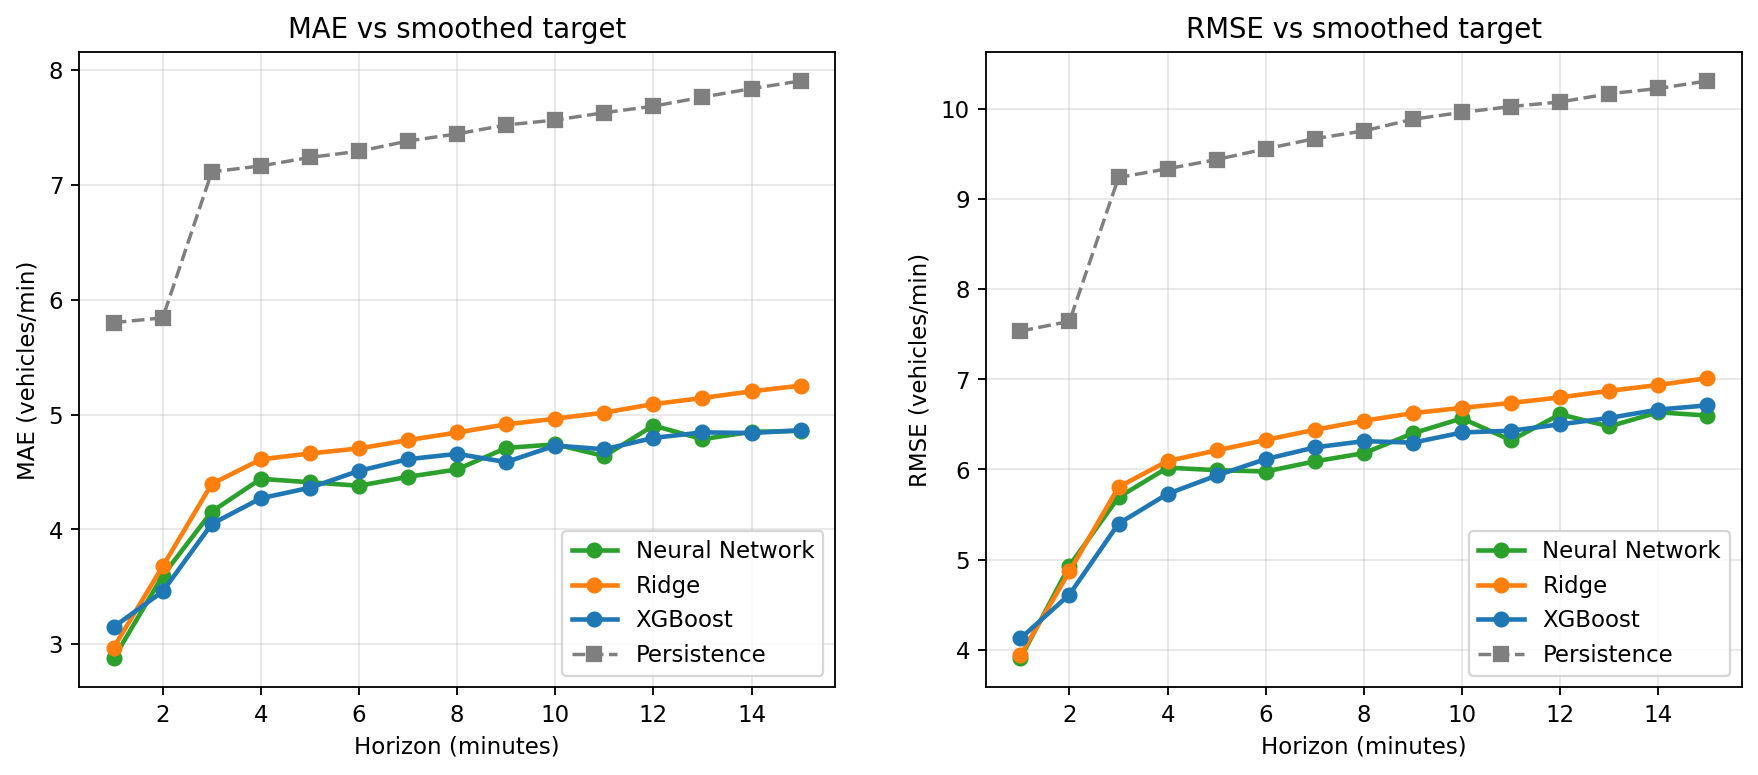

chart_r2_comparison.png


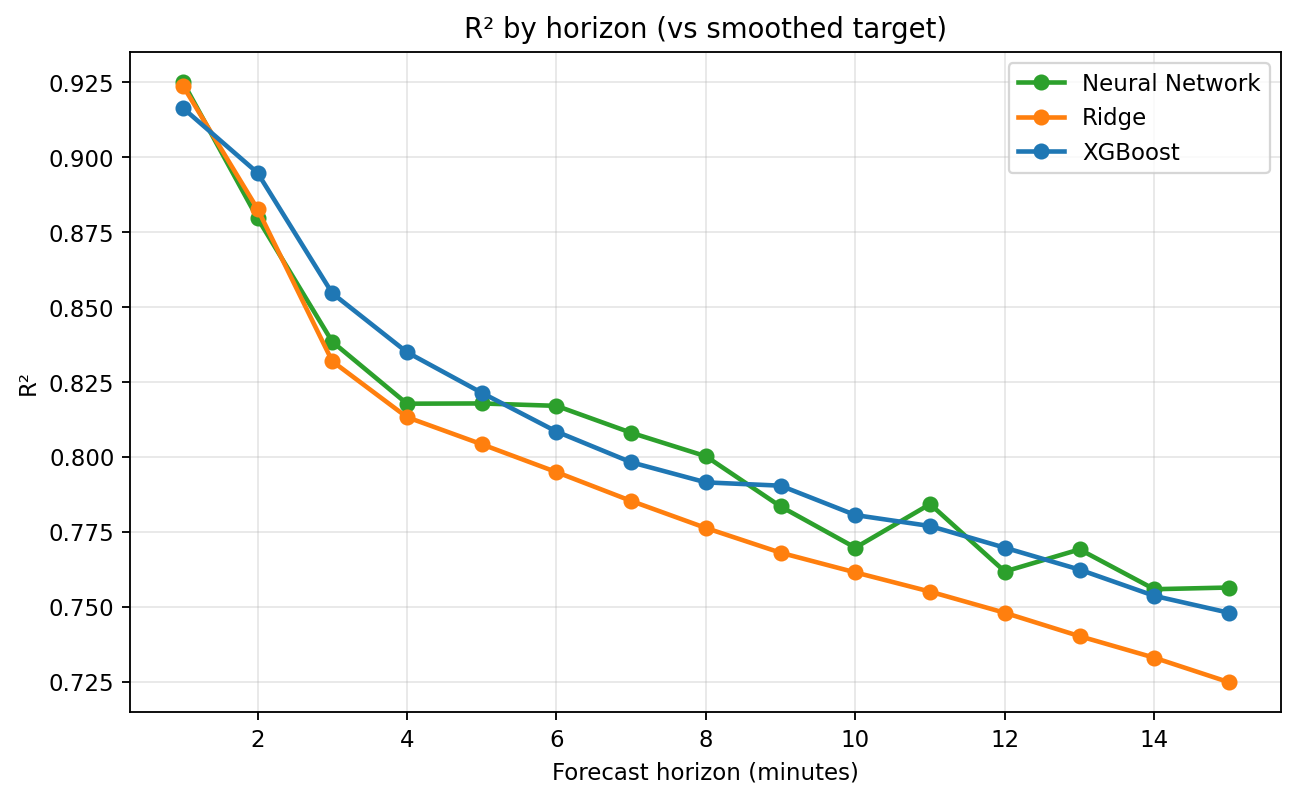

chart_mape_comparison.png


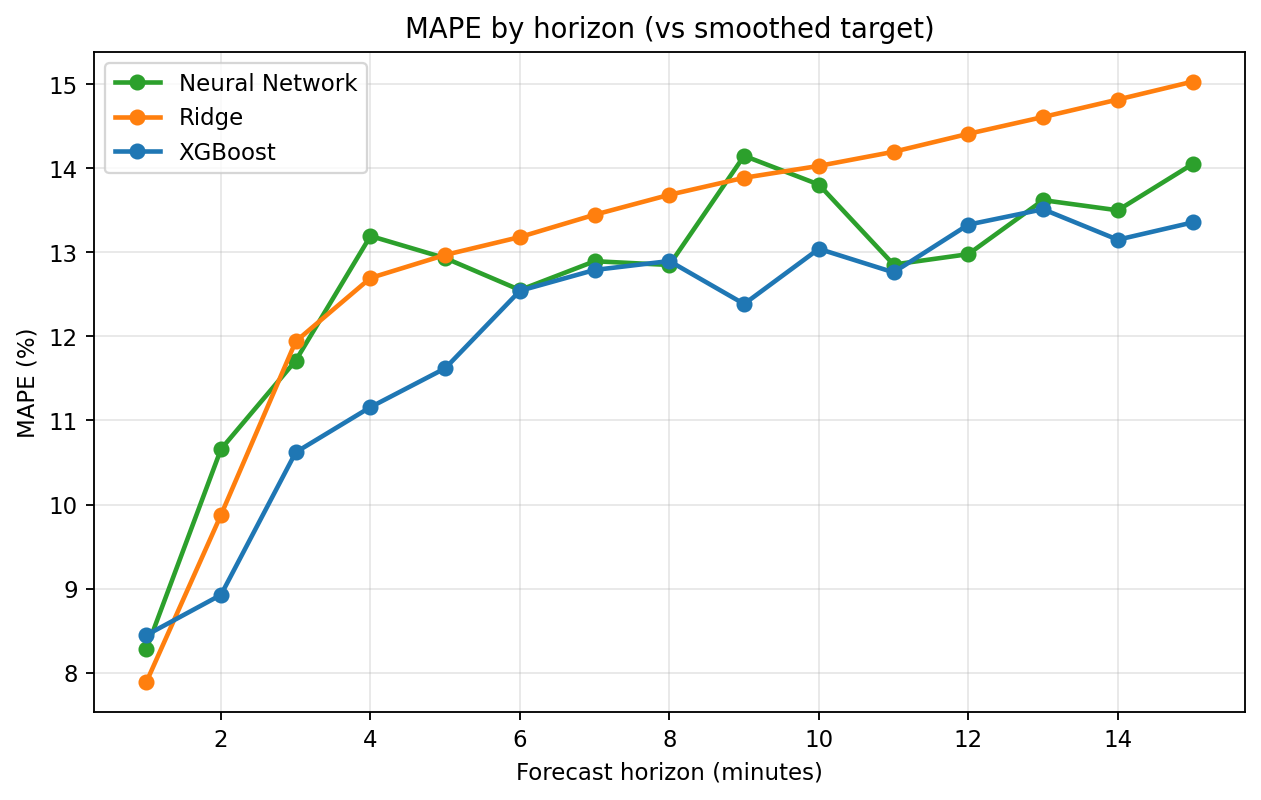

chart_skill_vs_persistence.png


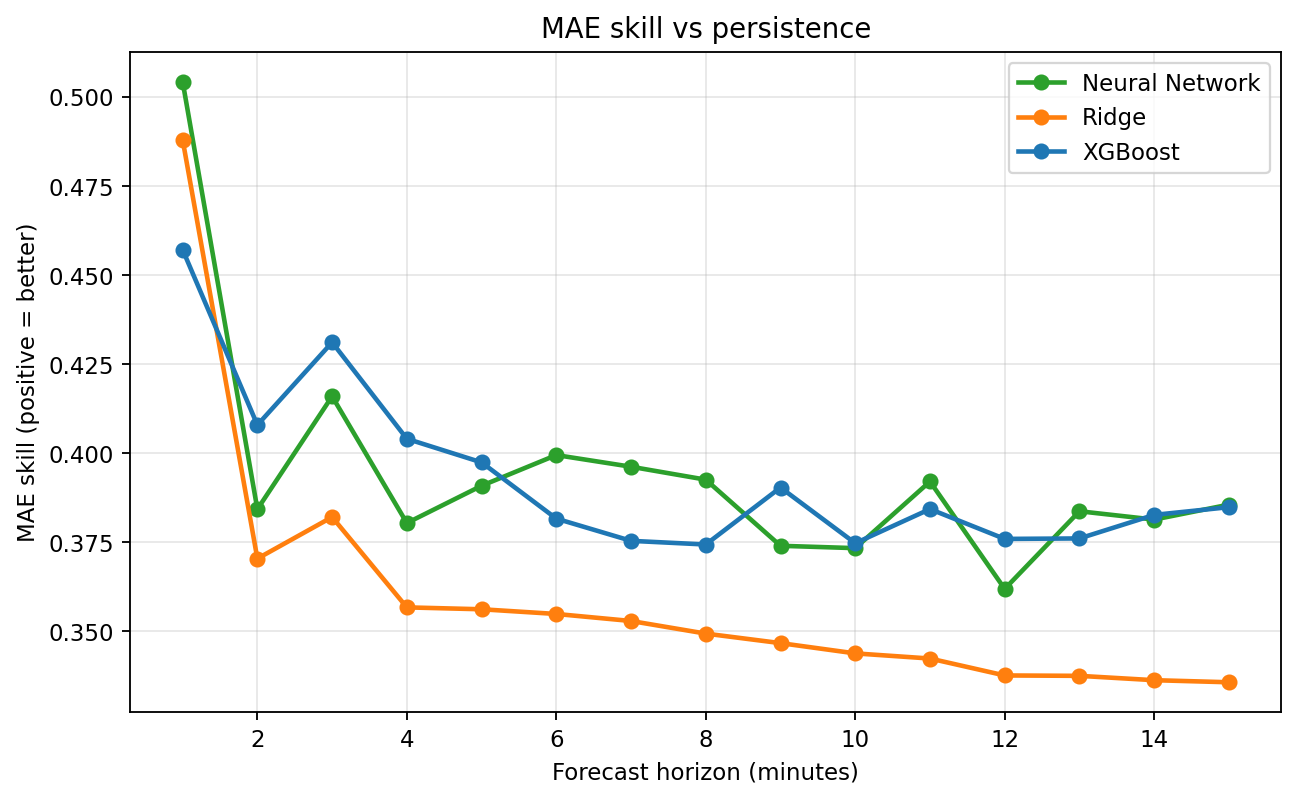

chart_primary_vs_raw.png


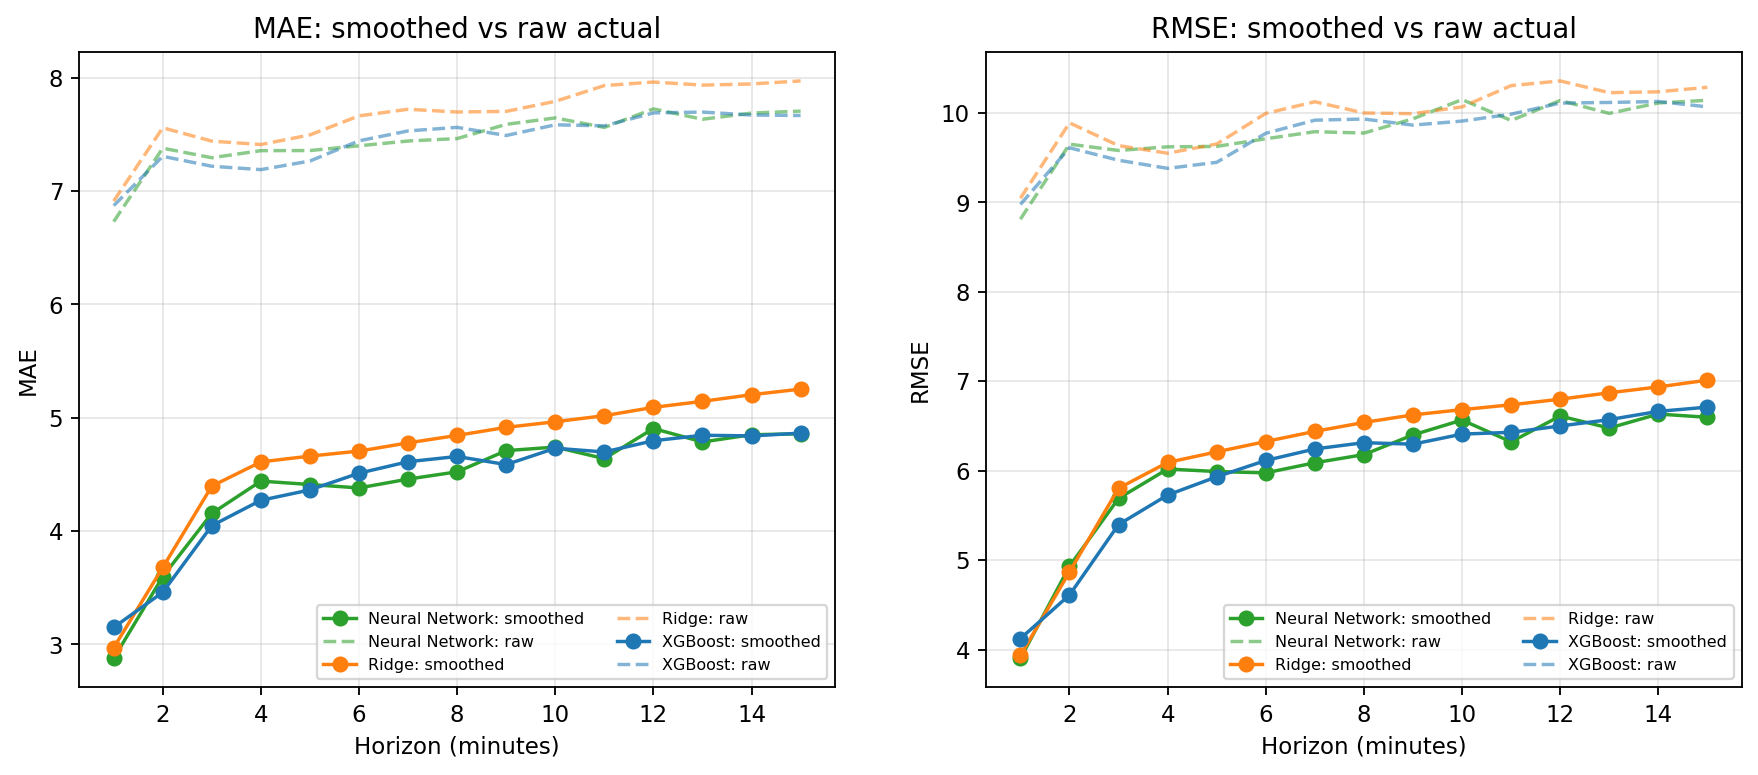

In [ ]:
"""
Fair External Evaluation: XGBoost vs Ridge vs Neural Network -- portal-8 FLOW only
================================================================================
Evaluates the three final f models on EXACTLY the same processed merged evaluation data:
  XGBoost: fS_prediction_model_p78_FINAL_cmax_v82.joblib
  Ridge:   fS_prediction_model_p78_FINAL_cmax_v82_RIDGE.joblib
  NN:      final_models/nn_final_metadata.joblib + nn_f_h01.keras ... nn_f_h15.keras

All artifacts are loaded from MODEL_DIR. All models receive the SAME reconstructed
C_max v8.2 -> S_pred -> 18-feature input frame, the SAME forecast origins, and the SAME
actual flow targets. This makes the comparison fair.

Primary evaluation target: five-minute-centred smoothed portal-8 flow, because all models
were trained on that target. Secondary benchmark: raw one-minute portal-8 flow.

INPUT: processed_merged_evaluation_df_1min.csv from v8_preprocess_merged_evaluation_data.py.
It must already exclude missing/dead days. This script does NOT touch raw CSV files.

OUTPUTS: output/model_comparison_f/
  predictions_all_models_long.csv
  horizon_metrics_primary_smoothed.csv
  horizon_metrics_secondary_raw.csv
  overall_summary.csv
  model_artifact_audit.csv
  chart_mae_rmse_comparison.png
  chart_r2_comparison.png
  chart_mape_comparison.png
  chart_skill_vs_persistence.png
  chart_primary_vs_raw.png

IMPORTANT: this script evaluates only f. Although f uses S_pred among its 18 inputs,
S_pred is reconstructed solely as an input feature; no S_pred output model is loaded.
"""

import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =============================================================================
# CONFIGURATION
# =============================================================================

MODEL_DIR = '/content/drive/MyDrive/AH2179 GP5/prediction model v8.2 (portals 7-8, time-aware)'
XGB_PATH = os.path.join(MODEL_DIR, 'fS_prediction_model_p78_FINAL_cmax_v82.joblib')
RIDGE_PATH = os.path.join(MODEL_DIR, 'fS_prediction_model_p78_FINAL_cmax_v82_RIDGE.joblib')
CMAX_PATH = os.path.join(MODEL_DIR, 'cmax_prediction_model_p78_v82.joblib')

# Metadata path used by the NN development notebook. The direct path is first;
# the final_models fallback supports its original export layout.
NN_METADATA_CANDIDATES = [
    os.path.join(MODEL_DIR, 'nn_final_metadata.joblib'),
    os.path.join(MODEL_DIR, 'final_models', 'nn_final_metadata.joblib'),
]

PROCESSED_EVAL_CANDIDATES = [
    '/content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv',
    '/content/processed_merged_evaluation_df_1min.csv',
    'output/data_processing_eval/processed_merged_evaluation_df_1min.csv',
]

OUTPUT_DIR = 'output/model_comparison_f'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = 'f'
EXPECTED_CMAX_FEATURES = ['v', 'f', 'c_early', 'f_trend_ratio_log', 'v_trend_delta',
                          'day_of_week', 'is_weekend']
AM_WINDOW_START = pd.Timestamp('1900-01-01 07:30').time()
AM_WINDOW_END = pd.Timestamp('1900-01-01 08:30').time()
MORNING_START = pd.Timestamp('1900-01-01 04:00').time()
MORNING_END = pd.Timestamp('1900-01-01 07:30').time()
MORNING_SPLIT = pd.Timestamp('1900-01-01 05:45').time()
MIN_COVERAGE = 0.50
MAPE_EPSILON = 1e-6

COLORS = {'XGBoost': '#1f77b4', 'Ridge': '#ff7f0e', 'Neural Network': '#2ca02c', 'Persistence': '#7f7f7f'}

# =============================================================================
# LOAD AND NORMALISE THE THREE ARTIFACT FORMATS
# =============================================================================

def first_file(paths):
    return next((p for p in paths if os.path.isfile(p)), None)

if not os.path.isdir('/content/drive/MyDrive'):
    raise RuntimeError("Google Drive is not mounted. Run: from google.colab import drive; drive.mount('/content/drive')")
for path in [XGB_PATH, RIDGE_PATH, CMAX_PATH]:
    if not os.path.isfile(path):
        raise FileNotFoundError(f'Missing model artifact: {path}')

nn_metadata_path = first_file(NN_METADATA_CANDIDATES)
if nn_metadata_path is None:
    raise FileNotFoundError('NN metadata not found. Checked:\n  ' + '\n  '.join(NN_METADATA_CANDIDATES))

xgb_artifact = joblib.load(XGB_PATH)
ridge_artifact = joblib.load(RIDGE_PATH)
nn_metadata = joblib.load(nn_metadata_path)
cmax_artifact = joblib.load(CMAX_PATH)

if list(cmax_artifact.get('feature_order', [])) != EXPECTED_CMAX_FEATURES:
    raise ValueError(f"C_max feature mismatch. Expected {EXPECTED_CMAX_FEATURES}; found {cmax_artifact.get('feature_order')}")

try:
    import tensorflow as tf
except ImportError as error:
    raise ImportError('TensorFlow is required to load the NN .keras models. Install/import tensorflow in Colab first.') from error

# scikit-learn artifacts use trained_models[target]. NN uses targets[target] metadata.
def sklearn_entry(artifact, label):
    if 'trained_models' not in artifact or TARGET not in artifact['trained_models']:
        raise KeyError(f'{label} artifact lacks trained_models["{TARGET}"]')
    entry = artifact['trained_models'][TARGET]
    needed = {'models', 'scaler', 'feature_cols'}
    missing = needed - set(entry)
    if missing:
        raise KeyError(f'{label} f entry missing {sorted(missing)}')
    return entry

xgb_entry = sklearn_entry(xgb_artifact, 'XGBoost')
ridge_entry = sklearn_entry(ridge_artifact, 'Ridge')

if 'targets' not in nn_metadata or TARGET not in nn_metadata['targets']:
    raise KeyError('NN metadata must contain targets["f"].')
nn_entry = nn_metadata['targets'][TARGET]
needed_nn = {'model_paths', 'scaler', 'feature_cols'}
missing_nn = needed_nn - set(nn_entry)
if missing_nn:
    raise KeyError(f'NN f metadata missing {sorted(missing_nn)}. Re-export nn_final_metadata.joblib after structure alignment.')

FORECAST_STEPS = int(xgb_artifact['forecast_steps'])
TARGET_PORTAL = int(xgb_artifact['target_portal_seq'])
ACTIVE_PORTALS = list(xgb_artifact['active_portals'])
LAG_STEPS = list(xgb_artifact.get('lag_step_list', [1, 2]))
CAPACITY_MODELS = cmax_artifact['portal_models']
CAPACITY_FEATURES = list(cmax_artifact['feature_order'])

# Validate every model is comparable before any predictions occur.
base_features = list(xgb_entry['feature_cols'])
model_entries = {'XGBoost': xgb_entry, 'Ridge': ridge_entry, 'Neural Network': nn_entry}
audit_rows = []
for name, entry in model_entries.items():
    feature_cols = list(entry['feature_cols'])
    if feature_cols != base_features:
        raise ValueError(f'{name} feature order differs from XGBoost. Comparison would be invalid.\n'
                         f'XGB={base_features}\n{name}={feature_cols}')
    if len(feature_cols) != 18:
        raise ValueError(f'{name} has {len(feature_cols)} inputs; expected 18.')
    smooth = int(entry.get('smooth_window', 5))
    delta = bool(entry.get('predict_delta', False))
    if smooth != 5 or delta:
        raise ValueError(f'{name} f target configuration differs: smooth_window={smooth}, predict_delta={delta}; '
                         'expected 5 and False for a fair f comparison.')
    audit_rows.append({'Model': name, 'N_features': len(feature_cols), 'Smooth_window': smooth,
                       'Predict_delta': delta, 'Forecast_steps': FORECAST_STEPS})

# Normalise NN model paths. If metadata recorded an old folder, use basename in MODEL_DIR.
raw_nn_paths = nn_entry['model_paths']
if isinstance(raw_nn_paths, dict):
    nn_paths = {int(k): v for k, v in raw_nn_paths.items()}
else:
    nn_paths = {i + 1: path for i, path in enumerate(raw_nn_paths)}
if sorted(nn_paths) != list(range(1, FORECAST_STEPS + 1)):
    raise ValueError(f'NN metadata needs one path per horizon 1..{FORECAST_STEPS}; found keys {sorted(nn_paths)}')
resolved_nn_paths = {}
for h, path in nn_paths.items():
    candidates = [path, os.path.join(MODEL_DIR, os.path.basename(path)),
                  os.path.join(MODEL_DIR, 'final_models', os.path.basename(path))]
    resolved = first_file(candidates)
    if resolved is None:
        raise FileNotFoundError(f'NN horizon +{h} model not found. Checked:\n  ' + '\n  '.join(candidates))
    resolved_nn_paths[h] = resolved

nn_models = {h: tf.keras.models.load_model(path, compile=False) for h, path in resolved_nn_paths.items()}
pd.DataFrame(audit_rows).to_csv(os.path.join(OUTPUT_DIR, 'model_artifact_audit.csv'), index=False)
print('[Models] All three f models loaded and feature/target contracts match.')
for row in audit_rows:
    print(' ', row)

# =============================================================================
# LOAD THE PROCESSED MERGED DATA
# =============================================================================

proc_path = first_file(PROCESSED_EVAL_CANDIDATES)
if proc_path is None:
    raise FileNotFoundError('Processed merged evaluation file not found. Checked:\n  ' + '\n  '.join(PROCESSED_EVAL_CANDIDATES))
raw_df = pd.read_csv(proc_path)
need = ['sequence', 'DateTime', 'v', 'f']
missing = [c for c in need if c not in raw_df.columns]
if missing:
    raise KeyError(f'{proc_path} lacks {missing}; run merged evaluation preprocessing first.')
raw_df['DateTime'] = pd.to_datetime(raw_df['DateTime'])
raw_df['sequence'] = raw_df['sequence'].astype(int)
raw_df = raw_df.sort_values(['sequence', 'DateTime']).reset_index(drop=True)
missing_portals = [p for p in ACTIVE_PORTALS if p not in set(raw_df.sequence)]
if missing_portals:
    raise ValueError(f'Processed evaluation data lacks portal(s) {missing_portals}')
print(f'[Data] {proc_path}: {len(raw_df):,} rows; {raw_df.DateTime.dt.date.nunique()} day(s); '
      f'{raw_df.DateTime.min()} -> {raw_df.DateTime.max()}')

# =============================================================================
# REBUILD THE SHARED C_max v8.2 -> S_pred -> 18 FEATURE FRAME
# =============================================================================

def expected_rows(start, end):
    return int((pd.Timestamp(f'1900-01-01 {end}') - pd.Timestamp(f'1900-01-01 {start}')).total_seconds() / 60) + 1


def daily_capacity(seq):
    p = raw_df[raw_df.sequence == seq].copy()
    p['Date'], p['Time'] = p.DateTime.dt.date, p.DateTime.dt.time
    p['C'] = p.v * p.f
    mask = (p.Time >= MORNING_START) & (p.Time < MORNING_END)
    counts = p.loc[mask].groupby('Date').size()
    valid = set(counts[counts >= MIN_COVERAGE * expected_rows(MORNING_START, MORNING_END)].index)
    all_days = set(p.Date.unique())
    p = p[p.Date.isin(valid)].copy()
    early = p[(p.Time >= MORNING_START) & (p.Time < MORNING_END)]
    first = p[(p.Time >= MORNING_START) & (p.Time < MORNING_SPLIT)]
    second = p[(p.Time >= MORNING_SPLIT) & (p.Time < MORNING_END)]
    v = early.groupby('Date').v.mean().rename('v')
    f = early.groupby('Date').f.sum().rename('f')
    c = early.groupby('Date').C.quantile(.98).rename('c_early')
    halves = pd.concat([first.groupby('Date').f.sum().rename('a'), second.groupby('Date').f.sum().rename('b')], axis=1).fillna(0.)
    fr = np.log((halves.b + 1.) / (halves.a + 1.)).rename('f_trend_ratio_log')
    vv = pd.concat([first.groupby('Date').v.mean().rename('a'), second.groupby('Date').v.mean().rename('b')], axis=1).fillna(0.)
    vd = (vv.b - vv.a).rename('v_trend_delta')
    features = pd.concat([v, f, c, fr, vd], axis=1).reset_index().dropna()
    date = pd.to_datetime(features.Date)
    features['day_of_week'] = date.dt.dayofweek.astype(int)
    features['is_weekend'] = (date.dt.dayofweek >= 5).astype(int)
    entry = CAPACITY_MODELS[seq]
    features['C_max_pred'] = entry['model'].predict(entry['scaler'].transform(features[CAPACITY_FEATURES].to_numpy(float)))
    print(f'  [C_max] portal {seq}: {len(features)} of {len(all_days)} day(s) usable')
    return features[['Date', 'C_max_pred']]


def build_corridor():
    caps = {p: daily_capacity(p) for p in ACTIVE_PORTALS}
    frames = {}
    for p in ACTIVE_PORTALS:
        d = raw_df[raw_df.sequence == p][['DateTime', 'v', 'f']].copy()
        d['Date'] = d.DateTime.dt.date
        d['C'] = d.v * d.f
        d = d.merge(caps[p], on='Date', how='inner').sort_values('DateTime').reset_index(drop=True)
        d['S_pred'] = d.C / d.C_max_pred
        for var in ['v', 'f', 'S_pred']:
            for lag in LAG_STEPS:
                d[f'{var}_lag{lag}'] = d.groupby('Date')[var].transform(lambda s, k=lag: s.shift(k).bfill())
        rename = {var: f'p{p}_{var}' for var in ['v', 'f', 'S_pred']}
        rename.update({f'{var}_lag{lag}': f'p{p}_{var}_lag{lag}' for var in ['v', 'f', 'S_pred'] for lag in LAG_STEPS})
        d = d.rename(columns=rename)
        frames[p] = d[['DateTime', 'Date'] + list(rename.values())]
    out = frames[ACTIVE_PORTALS[0]]
    for p in ACTIVE_PORTALS[1:]:
        out = out.merge(frames[p], on=['DateTime', 'Date'], how='inner')
    t = out.DateTime.dt.time
    counts = out.loc[(t >= AM_WINDOW_START) & (t <= AM_WINDOW_END)].groupby('Date').size()
    valid = set(counts[counts >= MIN_COVERAGE * expected_rows(AM_WINDOW_START, AM_WINDOW_END)].index)
    return out[out.Date.isin(valid)].sort_values('DateTime').reset_index(drop=True)


print('\n[Features] Rebuilding one shared evaluation feature frame...')
corridor = build_corridor()
print(f'[Features] corridor={corridor.shape}; valid days={corridor.Date.nunique()}')

# =============================================================================
# SHARED ORIGINS, ACTUAL TARGETS, AND THREE MODEL PREDICTIONS
# =============================================================================

raw_flow = corridor[f'p{TARGET_PORTAL}_f']
actual_smooth = corridor.groupby('Date')[f'p{TARGET_PORTAL}_f'].transform(lambda s: s.rolling(5, center=True, min_periods=1).mean())
ts = pd.DataFrame({'DateTime': corridor.DateTime, 'raw': raw_flow, 'smooth': actual_smooth}).set_index('DateTime')
mask = (corridor.DateTime.dt.time >= AM_WINDOW_START) & (corridor.DateTime.dt.time <= AM_WINDOW_END)
origins = corridor[mask].copy()
X = origins[base_features].to_numpy(float)
if not np.isfinite(X).all():
    raise ValueError('Non-finite values in shared model inputs.')

# Batch all models once per horizon.
xgb_x = xgb_entry['scaler'].transform(X)
ridge_x = ridge_entry['scaler'].transform(X)
nn_x = nn_entry['scaler'].transform(X)
model_predictions = {
    'XGBoost': {h: xgb_entry['models'][h - 1].predict(xgb_x) for h in range(1, FORECAST_STEPS + 1)},
    'Ridge': {h: ridge_entry['models'][h - 1].predict(ridge_x) for h in range(1, FORECAST_STEPS + 1)},
    'Neural Network': {h: nn_models[h].predict(nn_x, verbose=0).reshape(-1) for h in range(1, FORECAST_STEPS + 1)},
}

rows = []
for name, predictions in model_predictions.items():
    for h in range(1, FORECAST_STEPS + 1):
        target_time = origins.DateTime + pd.Timedelta(minutes=h)
        same_day = (target_time.dt.date == origins.Date).to_numpy()
        rows.append(pd.DataFrame({
            'Model': name, 'Target': TARGET, 'Origin_DateTime': origins.DateTime.to_numpy(),
            'Origin_Date': origins.Date.astype(str).to_numpy(), 'Origin_Time': origins.DateTime.dt.strftime('%H:%M').to_numpy(),
            'Horizon_min': h, 'Target_DateTime': target_time.to_numpy(),
            'Current_Raw_Value': origins[f'p{TARGET_PORTAL}_f'].to_numpy(),
            'Predicted_Level': predictions[h],
            'Actual_Smoothed_Level': np.where(same_day, ts.smooth.reindex(target_time).to_numpy(), np.nan),
            'Actual_Raw_Level': np.where(same_day, ts.raw.reindex(target_time).to_numpy(), np.nan),
        }))
pred = pd.concat(rows, ignore_index=True)
full_origins = (pred.dropna(subset=['Actual_Smoothed_Level']).groupby(['Model', 'Origin_DateTime']).size().rename('n').reset_index())
full_origins = full_origins[full_origins.n == FORECAST_STEPS][['Model', 'Origin_DateTime']].assign(Has_Full_Horizon=True)
pred = pred.merge(full_origins, on=['Model', 'Origin_DateTime'], how='left')
pred['Has_Full_Horizon'] = pred.Has_Full_Horizon.fillna(False).astype(bool)
pred['Residual_vs_Smoothed'] = pred.Predicted_Level - pred.Actual_Smoothed_Level
pred['Residual_vs_Raw'] = pred.Predicted_Level - pred.Actual_Raw_Level
pred.to_csv(os.path.join(OUTPUT_DIR, 'predictions_all_models_long.csv'), index=False)

# =============================================================================
# MATCHED METRICS + PERSISTENCE BASELINE
# =============================================================================

def metrics(actual, estimate):
    a, e = np.asarray(actual, float), np.asarray(estimate, float)
    ok = np.isfinite(a) & np.isfinite(e); a, e = a[ok], e[ok]
    err, ae = e - a, np.abs(e - a)
    nz = np.abs(a) > MAPE_EPSILON
    denom = np.abs(a) + np.abs(e); sm = denom > MAPE_EPSILON
    return {'N': len(a), 'MAE': mean_absolute_error(a, e), 'RMSE': np.sqrt(mean_squared_error(a, e)),
            'MAPE_pct': np.mean(ae[nz] / np.abs(a[nz])) * 100 if nz.any() else np.nan,
            'sMAPE_pct': np.mean(2 * ae[sm] / denom[sm]) * 100 if sm.any() else np.nan,
            'R2': r2_score(a, e), 'Bias': err.mean(), 'Median_AE': np.median(ae), 'P90_AE': np.quantile(ae, .9)}

scored = pred[pred.Has_Full_Horizon].copy()
primary_rows, raw_rows = [], []
for (name, h), g in scored.groupby(['Model', 'Horizon_min']):
    pm = metrics(g.Actual_Smoothed_Level, g.Predicted_Level)
    base = metrics(g.Actual_Smoothed_Level, g.Current_Raw_Value)
    primary_rows.append({'Model': name, 'Horizon_min': h, **pm,
                         'Persistence_MAE': base['MAE'], 'Persistence_RMSE': base['RMSE'],
                         'MAE_Skill_vs_Persistence': 1 - pm['MAE'] / base['MAE'],
                         'RMSE_Skill_vs_Persistence': 1 - pm['RMSE'] / base['RMSE']})
    raw_rows.append({'Model': name, 'Horizon_min': h, **metrics(g.Actual_Raw_Level, g.Predicted_Level)})
primary, raw_metrics = pd.DataFrame(primary_rows), pd.DataFrame(raw_rows)
for df in (primary, raw_metrics):
    ncols = df.select_dtypes(include=np.number).columns.difference(['Horizon_min', 'N'])
    df[ncols] = df[ncols].round(5)
primary.to_csv(os.path.join(OUTPUT_DIR, 'horizon_metrics_primary_smoothed.csv'), index=False)
raw_metrics.to_csv(os.path.join(OUTPUT_DIR, 'horizon_metrics_secondary_raw.csv'), index=False)

summary_rows = []
for name, g in scored.groupby('Model'):
    summary_rows.append({'Model': name, 'View': 'Primary: smoothed target', **metrics(g.Actual_Smoothed_Level, g.Predicted_Level)})
    summary_rows.append({'Model': name, 'View': 'Secondary: raw observation', **metrics(g.Actual_Raw_Level, g.Predicted_Level)})
summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(OUTPUT_DIR, 'overall_summary.csv'), index=False)

print('\n' + '=' * 100 + '\nPRIMARY FAIR COMPARISON: f FORECAST vs 5-MIN-SMOOTHED TARGET\n' + '=' * 100)
print(primary[['Model', 'Horizon_min', 'N', 'MAE', 'RMSE', 'MAPE_pct', 'sMAPE_pct', 'R2', 'Bias', 'MAE_Skill_vs_Persistence']]
      .sort_values(['Horizon_min', 'Model']).round(4).to_string(index=False))
print('\nOVERALL SUMMARY')
print(summary[['Model', 'View', 'N', 'MAE', 'RMSE', 'MAPE_pct', 'sMAPE_pct', 'R2', 'Bias']].round(4).to_string(index=False))

# =============================================================================
# CHARTS
# =============================================================================

saved = []
def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name); fig.savefig(path, dpi=165, bbox_inches='tight'); plt.close(fig); saved.append(path)

def multi(metric, ylabel, title, filename, data=primary):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for name, g in data.groupby('Model'):
        g = g.sort_values('Horizon_min')
        ax.plot(g.Horizon_min, g[metric], marker='o', linewidth=2, label=name, color=COLORS[name])
    ax.set(title=title, xlabel='Forecast horizon (minutes)', ylabel=ylabel); ax.grid(alpha=.3); ax.legend(); save(fig, filename)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, label in zip(axes, ['MAE', 'RMSE'], ['MAE (vehicles/min)', 'RMSE (vehicles/min)']):
    for name, g in primary.groupby('Model'):
        g = g.sort_values('Horizon_min'); ax.plot(g.Horizon_min, g[metric], marker='o', linewidth=2, label=name, color=COLORS[name])
    base = primary[primary.Model == 'XGBoost'].sort_values('Horizon_min')
    ax.plot(base.Horizon_min, base[f'Persistence_{metric}'], marker='s', linestyle='--', color=COLORS['Persistence'], label='Persistence')
    ax.set(title=f'{metric} vs smoothed target', xlabel='Horizon (minutes)', ylabel=label); ax.grid(alpha=.3); ax.legend()
save(fig, 'chart_mae_rmse_comparison.png')
multi('R2', 'R²', 'R² by horizon (vs smoothed target)', 'chart_r2_comparison.png')
multi('MAPE_pct', 'MAPE (%)', 'MAPE by horizon (vs smoothed target)', 'chart_mape_comparison.png')
multi('MAE_Skill_vs_Persistence', 'MAE skill (positive = better)', 'MAE skill vs persistence', 'chart_skill_vs_persistence.png')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    for name in primary.Model.unique():
        a = primary[primary.Model == name].sort_values('Horizon_min')
        b = raw_metrics[raw_metrics.Model == name].sort_values('Horizon_min')
        ax.plot(a.Horizon_min, a[metric], marker='o', color=COLORS[name], label=f'{name}: smoothed')
        ax.plot(b.Horizon_min, b[metric], linestyle='--', color=COLORS[name], alpha=.55, label=f'{name}: raw')
    ax.set(title=f'{metric}: smoothed vs raw actual', xlabel='Horizon (minutes)', ylabel=metric); ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
save(fig, 'chart_primary_vs_raw.png')

with open(os.path.join(OUTPUT_DIR, 'run_summary.json'), 'w') as fh:
    json.dump({'models': list(model_entries), 'n_days': int(scored.Origin_Date.nunique()),
               'n_origins_per_model': int(scored[scored.Model == 'XGBoost'].Origin_DateTime.nunique()),
               'forecast_steps': FORECAST_STEPS, 'processed_input': proc_path}, fh, indent=2)
print(f'\n[Done] {len(pred):,} matched prediction rows; {scored.Origin_Date.nunique()} fully scored day(s).')
print(f'[Done] Tables and {len(saved)} charts saved in {OUTPUT_DIR}')
try:
    from IPython.display import display, Image
    for path in saved:
        print(os.path.basename(path)); display(Image(filename=path))
except ImportError:
    pass

## Instance Plot

[Plots] models=['XGBoost', 'Ridge', 'Neural Network']; reference=XGBoost; 175 day(s); 10,675 origins; horizons +1..+15

Horizon winners (first rows):
 Horizon_min       Best_MAE      Best_RMSE Best_MAPE_pct        Best_R2
           1 Neural Network Neural Network         Ridge Neural Network
           2        XGBoost        XGBoost       XGBoost        XGBoost
           3        XGBoost        XGBoost       XGBoost        XGBoost
           4        XGBoost        XGBoost       XGBoost        XGBoost
           5        XGBoost        XGBoost       XGBoost        XGBoost

Horizon-group scorecard:
           Group          Model   MAE  RMSE  MAPE_pct    R2
  Short (+1..+5)        XGBoost 3.858 5.159    10.154 0.864
  Short (+1..+5)          Ridge 4.063 5.383    11.073 0.851
  Short (+1..+5) Neural Network 3.896 5.308    11.354 0.856
Medium (+6..+10)        XGBoost 4.619 6.276    12.730 0.794
Medium (+6..+10)          Ridge 4.841 6.523    13.644 0.777
Medium (+6..+10) Neural Network 

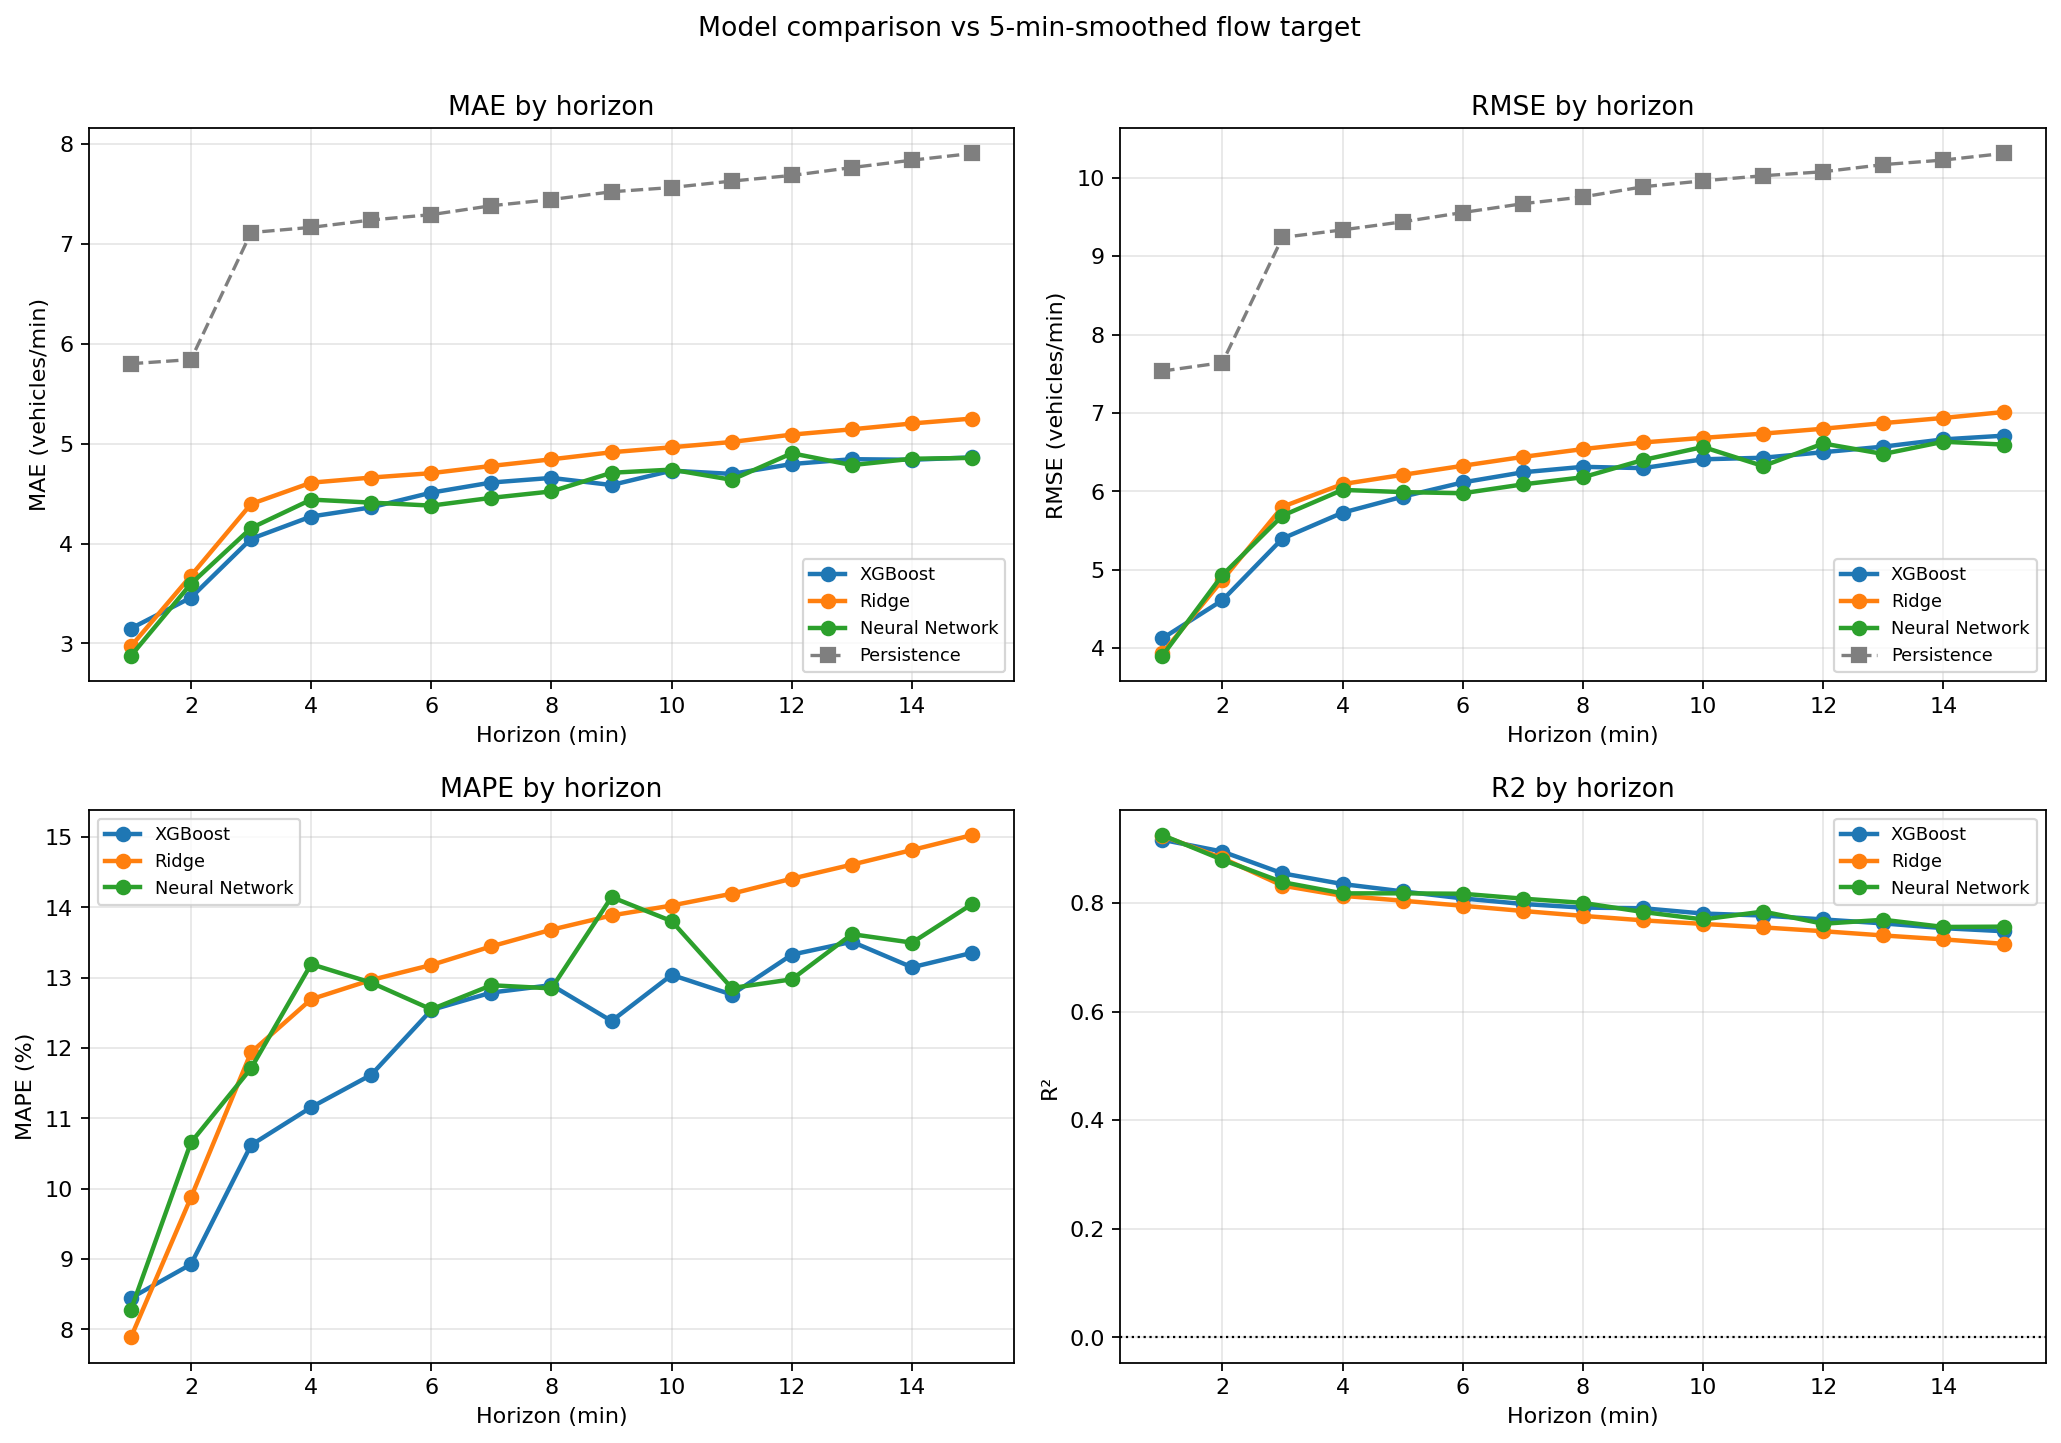

chart_A2_mae_heatmap.png


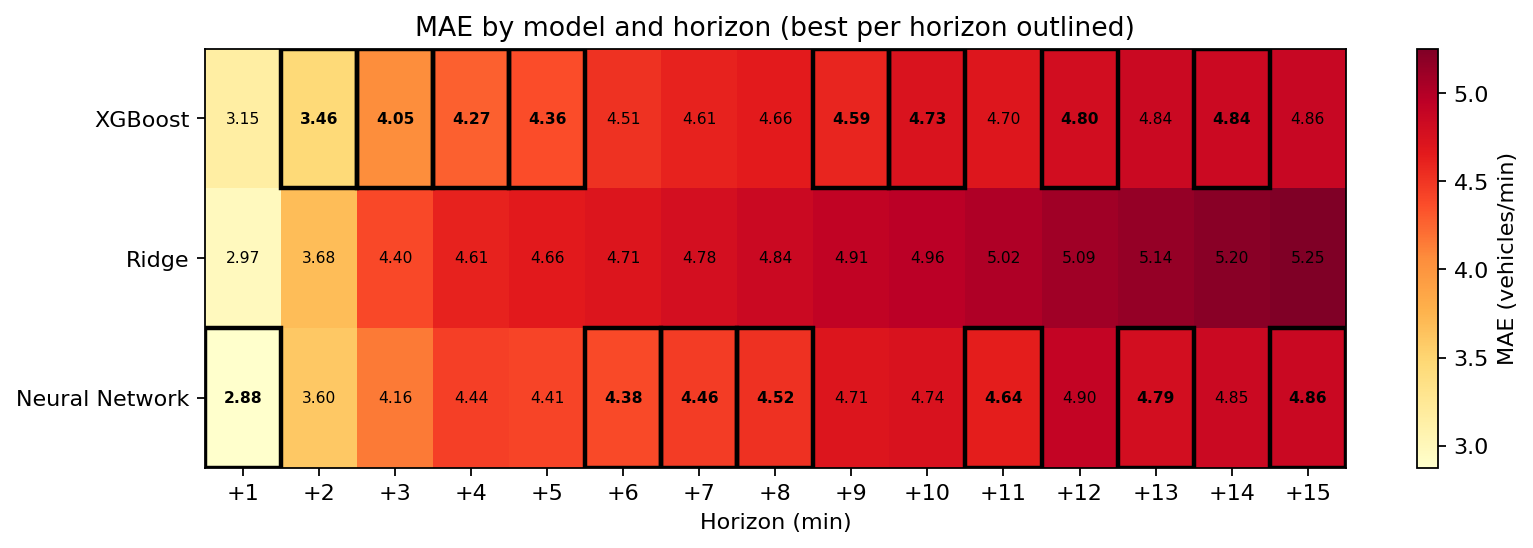

chart_A3_mae_vs_reference.png


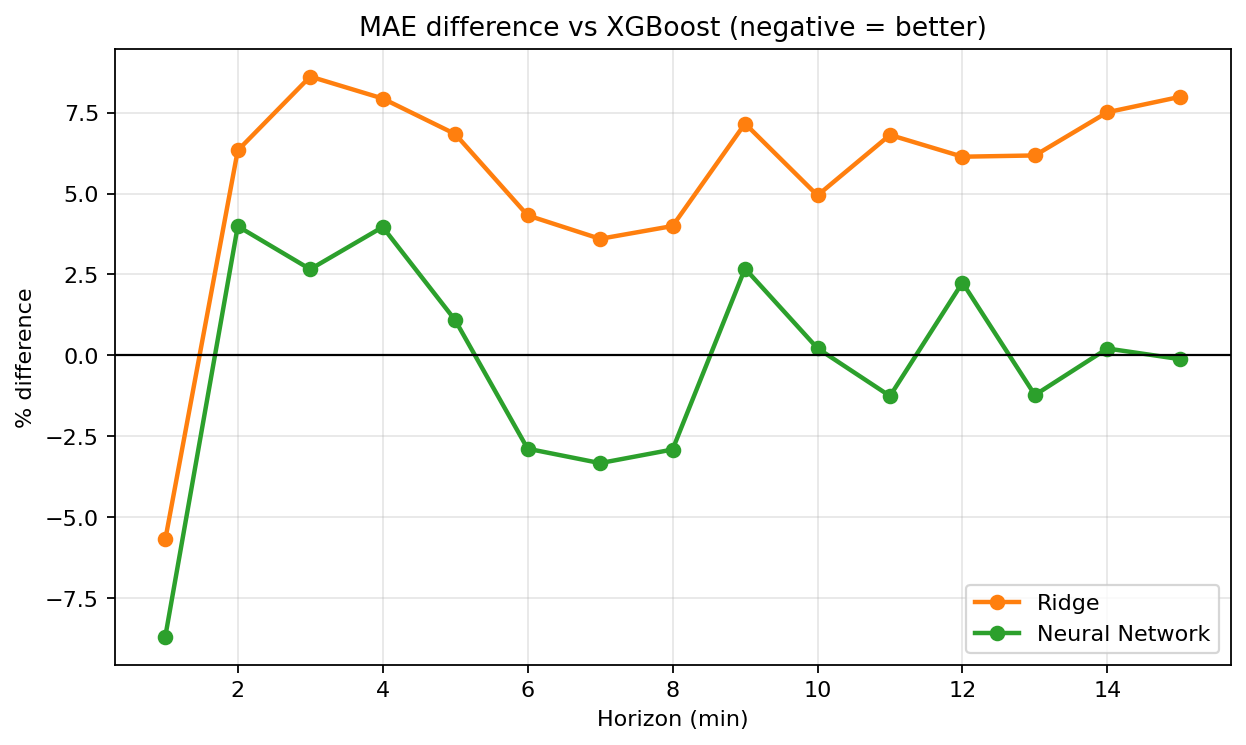

chart_A4_horizon_groups.png


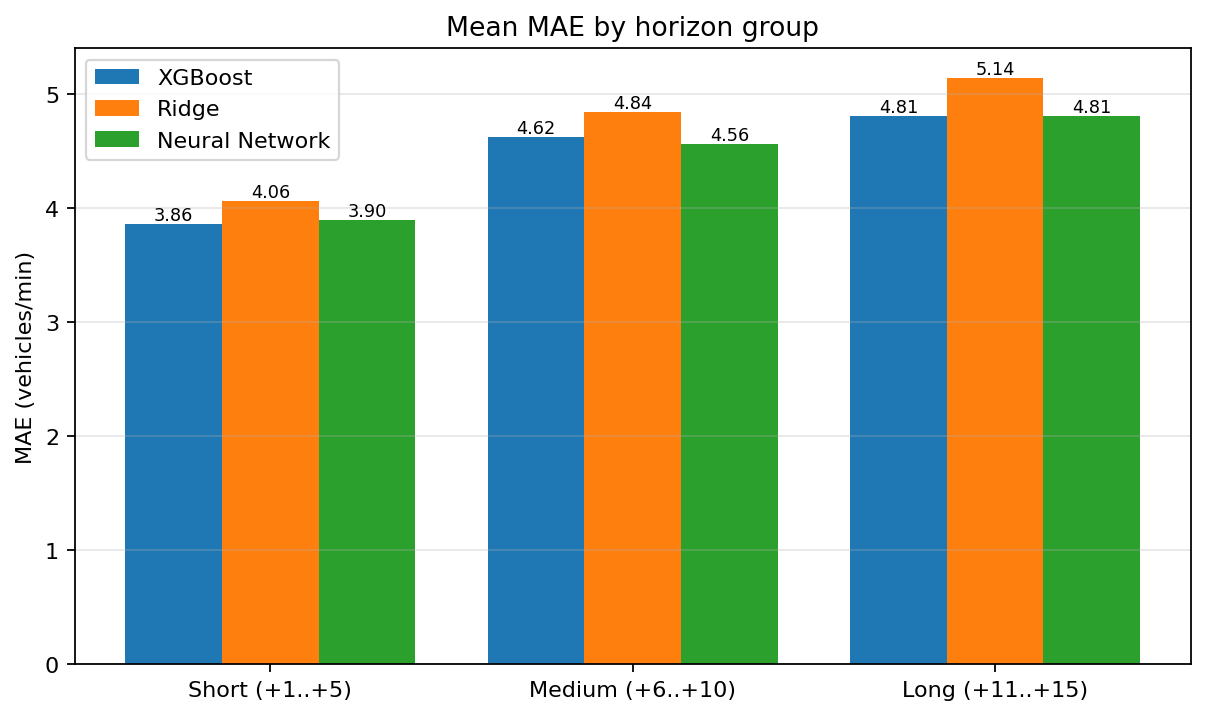

chart_A5_horizons_won.png


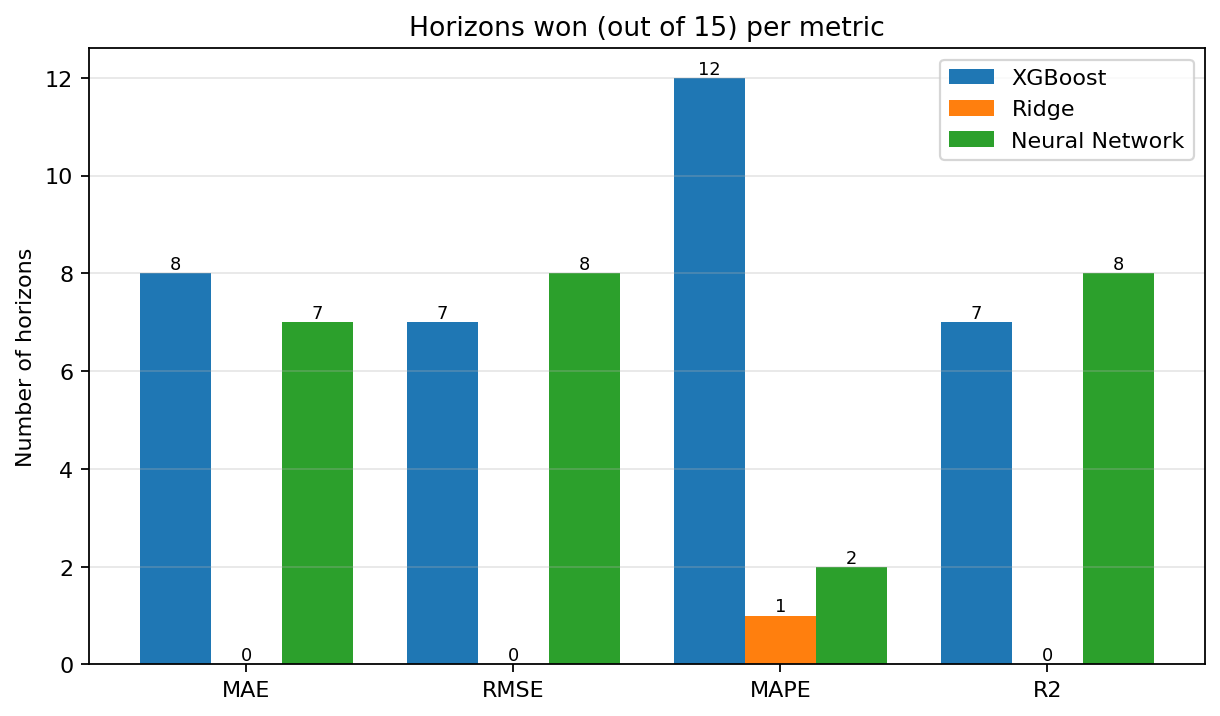

chart_A6_overall_smoothed_vs_raw.png


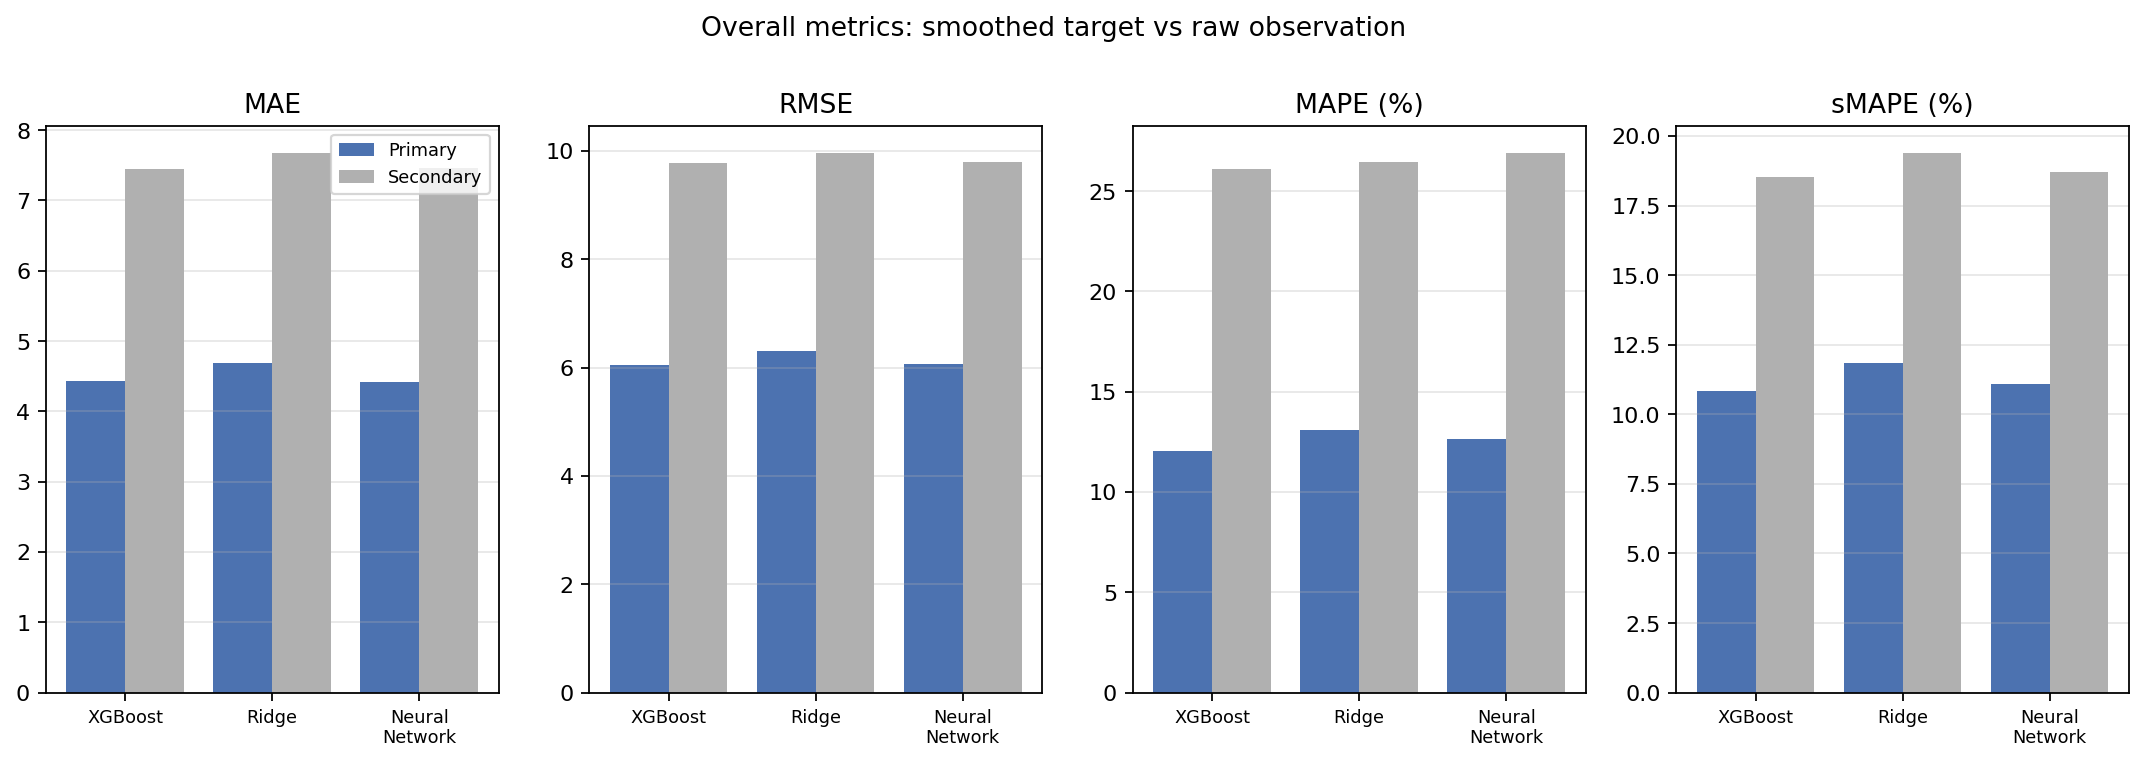

chart_A7_day_level_mae.png


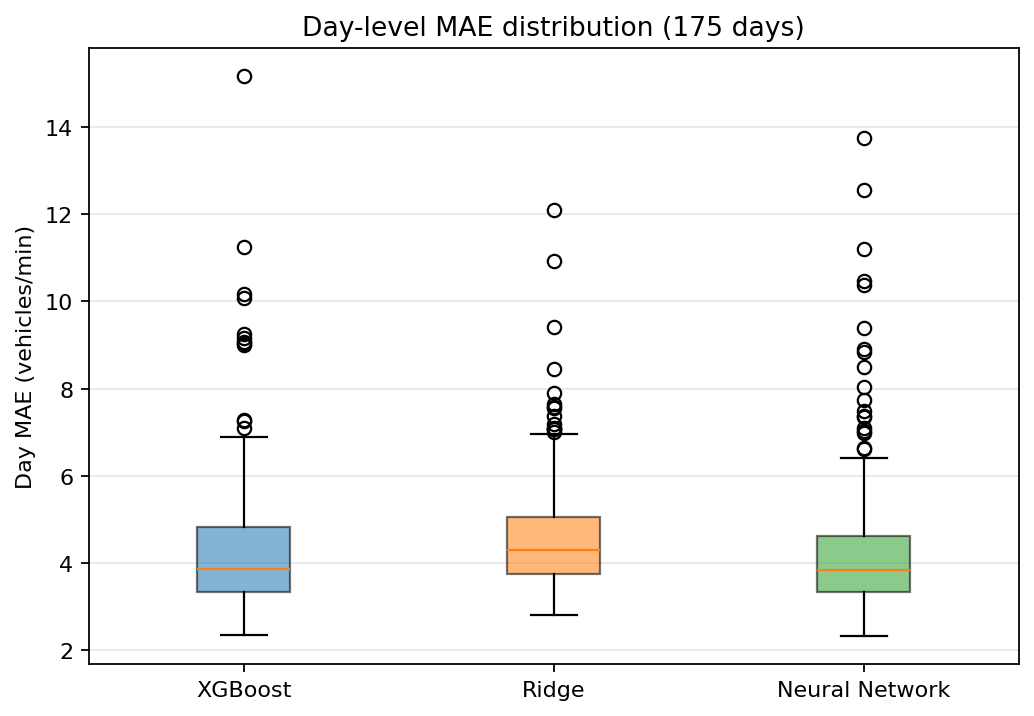

Output()

In [ ]:
"""
ADD-ON: Plotting for the XGBoost vs Ridge vs Neural Network f comparison
================================================================================
Run AFTER v8_compare_xgb_ridge_nn_f.py. Two ways to use it:
  (a) paste/run it in the same session -> it reuses the in-memory tables
      (`pred`, `primary`, `raw_metrics`, `summary`), or
  (b) run it alone -> it reads the CSVs the comparison script saved in
      output/model_comparison_f/.

PART A  turns the evaluation metrics into charts (saved to output/model_comparison_f/plots/)
  - 2x2 dashboard: MAE, RMSE, MAPE, R2 by horizon (all models; persistence reference on MAE/RMSE)
  - MAE heatmap (model x horizon) with the best model per horizon outlined
  - % MAE difference vs the reference model (negative = better than the reference)
  - MAE by horizon group (+1..5, +6..10, +11..15)
  - which model wins each horizon (count of horizons won, per metric)
  - overall metrics per model (smoothed target vs raw observation)
  - day-level MAE distribution per model + paired comparison with the reference
    (win-rate over days and a Wilcoxon signed-rank p-value)
  Tables: horizon_winners.csv, horizon_group_scorecard.csv, day_level_model_comparison.csv

PART B  per-instance plotting (all selected models on one chart)
  show_instance_viewer()                    dropdowns: date, instance, models
  plot_instance('2022-03-07', '07:45')      one static plot + horizon table
  list_hardest_instances(10)                worst origins for the reference model
  list_largest_disagreement(10)             origins where the models differ most
  plot_instance_gallery(n_each=2)           grid: best and hardest origins

How to read an instance plot
  grey dotted = raw one-minute flow; black = 5-min smoothed actual (the models' training target);
  coloured dashed lines = each model's +1..+15 forecast made at the origin (t = 0);
  thin grey dash-dot = persistence (flat at the current raw flow).
Judge each model by its line vs the BLACK line. The instance list offers only origins with a
complete +15 min future.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

COMPARE_DIR = 'output/model_comparison_f'
PLOT_DIR = os.path.join(COMPARE_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

REFERENCE_MODEL = 'XGBoost'
MODEL_ORDER = ['XGBoost', 'Ridge', 'Neural Network']
COLORS = {'XGBoost': '#1f77b4', 'Ridge': '#ff7f0e', 'Neural Network': '#2ca02c', 'Persistence': '#7f7f7f'}
HORIZON_GROUPS = {'Short (+1..+5)': (1, 5), 'Medium (+6..+10)': (6, 10), 'Long (+11..+15)': (11, 15)}
CONTEXT_BEFORE_MINUTES = 10
MAX_HORIZON = 15
PROCESSED_EVAL_CANDIDATES = [
    '/content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv',
    '/content/processed_merged_evaluation_df_1min.csv',
    'output/data_processing_eval/processed_merged_evaluation_df_1min.csv',
]

# =============================================================================
# LOAD (in-memory tables first, CSVs otherwise)
# =============================================================================

def _load(var_name, csv_name, required, parse_dates=None):
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame) \
            and required <= set(globals()[var_name].columns):
        return globals()[var_name].copy()
    path = os.path.join(COMPARE_DIR, csv_name)
    if not os.path.isfile(path):
        raise FileNotFoundError(f'{path} not found. Run v8_compare_xgb_ridge_nn_f.py first.')
    df = pd.read_csv(path, parse_dates=parse_dates)
    if not required <= set(df.columns):
        raise KeyError(f'{csv_name} missing columns: {sorted(required - set(df.columns))}')
    return df


_PRED_COLS = {'Model', 'Origin_DateTime', 'Origin_Date', 'Origin_Time', 'Horizon_min', 'Target_DateTime',
              'Current_Raw_Value', 'Predicted_Level', 'Actual_Smoothed_Level', 'Actual_Raw_Level', 'Has_Full_Horizon'}
_MET_COLS = {'Model', 'Horizon_min', 'MAE', 'RMSE', 'MAPE_pct', 'R2'}

pred_all = _load('pred', 'predictions_all_models_long.csv', _PRED_COLS, ['Origin_DateTime', 'Target_DateTime'])
primary_m = _load('primary', 'horizon_metrics_primary_smoothed.csv', _MET_COLS)
raw_m = _load('raw_metrics', 'horizon_metrics_secondary_raw.csv', {'Model', 'Horizon_min', 'MAE', 'RMSE'})
summary_m = _load('summary', 'overall_summary.csv', {'Model', 'View', 'MAE', 'RMSE'})

pred_all['Origin_Date'] = pd.to_datetime(pred_all['Origin_Date']).dt.strftime('%Y-%m-%d')
pred_all['Has_Full_Horizon'] = pred_all['Has_Full_Horizon'].astype(bool)
pred_all = pred_all[pred_all.Has_Full_Horizon].copy()
pred_all['Residual'] = pred_all['Predicted_Level'] - pred_all['Actual_Smoothed_Level']
pred_all['Abs_Error'] = pred_all['Residual'].abs()

found = list(pred_all.Model.unique())
MODELS = [m for m in MODEL_ORDER if m in found] + [m for m in found if m not in MODEL_ORDER]
if REFERENCE_MODEL not in MODELS:
    REFERENCE_MODEL = MODELS[0]
for m in MODELS:
    COLORS.setdefault(m, plt.get_cmap('tab10')(len(COLORS) % 10))
HORIZONS = sorted(pred_all.Horizon_min.unique())
print(f'[Plots] models={MODELS}; reference={REFERENCE_MODEL}; {pred_all.Origin_Date.nunique()} day(s); '
      f'{pred_all.Origin_DateTime.nunique():,} origins; horizons +{min(HORIZONS)}..+{max(HORIZONS)}')

_saved = []


def _save(fig, name):
    path = os.path.join(PLOT_DIR, name)
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.close(fig)
    _saved.append(path)


def _series(df, model, col):
    s = df[df.Model == model].sort_values('Horizon_min')
    return s.Horizon_min.to_numpy(), s[col].to_numpy(dtype=float)


# =============================================================================
# PART A -- METRICS -> CHARTS
# =============================================================================

# A1. 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
specs = [('MAE', 'MAE (vehicles/min)', True), ('RMSE', 'RMSE (vehicles/min)', True),
         ('MAPE_pct', 'MAPE (%)', False), ('R2', 'R²', False)]
for ax, (metric, label, persistence) in zip(axes.ravel(), specs):
    for m in MODELS:
        x, y = _series(primary_m, m, metric)
        ax.plot(x, y, marker='o', linewidth=2, color=COLORS[m], label=m)
    if persistence and f'Persistence_{metric}' in primary_m.columns:
        x, y = _series(primary_m[primary_m.Model == REFERENCE_MODEL], REFERENCE_MODEL, f'Persistence_{metric}')
        ax.plot(x, y, marker='s', linestyle='--', color=COLORS['Persistence'], label='Persistence')
    if metric == 'R2':
        ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set(title=f'{metric.replace("_pct", "")} by horizon', xlabel='Horizon (min)', ylabel=label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Model comparison vs 5-min-smoothed flow target', y=1.0)
fig.tight_layout()
_save(fig, 'chart_A1_metric_dashboard.png')

# A2. MAE heatmap with best model outlined
mae_pivot = primary_m.pivot(index='Model', columns='Horizon_min', values='MAE').loc[MODELS]
fig, ax = plt.subplots(figsize=(1 + 0.7 * len(HORIZONS), 1.6 + 0.6 * len(MODELS)))
im = ax.imshow(mae_pivot.to_numpy(), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(HORIZONS))); ax.set_xticklabels([f'+{h}' for h in mae_pivot.columns])
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
best_idx = mae_pivot.to_numpy().argmin(axis=0)
for i in range(mae_pivot.shape[0]):
    for j in range(mae_pivot.shape[1]):
        ax.text(j, i, f'{mae_pivot.iat[i, j]:.2f}', ha='center', va='center', fontsize=7,
                fontweight='bold' if best_idx[j] == i else 'normal')
for j, i in enumerate(best_idx):
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))
fig.colorbar(im, ax=ax, label='MAE (vehicles/min)')
ax.set(title='MAE by model and horizon (best per horizon outlined)', xlabel='Horizon (min)')
_save(fig, 'chart_A2_mae_heatmap.png')

# A3. % MAE difference vs reference
ref_mae = primary_m[primary_m.Model == REFERENCE_MODEL].set_index('Horizon_min')['MAE']
fig, ax = plt.subplots(figsize=(9, 5))
for m in MODELS:
    if m == REFERENCE_MODEL:
        continue
    s = primary_m[primary_m.Model == m].set_index('Horizon_min')['MAE']
    ax.plot(s.index, (s - ref_mae) / ref_mae * 100, marker='o', linewidth=2, color=COLORS[m], label=m)
ax.axhline(0, color='black', linewidth=1)
ax.set(title=f'MAE difference vs {REFERENCE_MODEL} (negative = better)', xlabel='Horizon (min)', ylabel='% difference')
ax.grid(alpha=0.3); ax.legend()
_save(fig, 'chart_A3_mae_vs_reference.png')

# A4. horizon-group scorecard
score_rows = []
for g, (lo, hi) in HORIZON_GROUPS.items():
    sub = primary_m[(primary_m.Horizon_min >= lo) & (primary_m.Horizon_min <= hi)]
    for m in MODELS:
        s = sub[sub.Model == m]
        if len(s):
            score_rows.append({'Group': g, 'Model': m, 'MAE': s.MAE.mean(), 'RMSE': s.RMSE.mean(),
                               'MAPE_pct': s.MAPE_pct.mean(), 'R2': s.R2.mean()})
scorecard = pd.DataFrame(score_rows)
scorecard.round(4).to_csv(os.path.join(PLOT_DIR, 'horizon_group_scorecard.csv'), index=False)
groups = list(scorecard.Group.unique())
fig, ax = plt.subplots(figsize=(9, 5))
w = 0.8 / len(MODELS)
for k, m in enumerate(MODELS):
    vals = [scorecard[(scorecard.Group == g) & (scorecard.Model == m)].MAE.mean() for g in groups]
    bars = ax.bar(np.arange(len(groups)) + k * w, vals, w, color=COLORS[m], label=m)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(np.arange(len(groups)) + w * (len(MODELS) - 1) / 2); ax.set_xticklabels(groups)
ax.set(title='Mean MAE by horizon group', ylabel='MAE (vehicles/min)'); ax.grid(axis='y', alpha=0.3); ax.legend()
_save(fig, 'chart_A4_horizon_groups.png')

# A5. winners per horizon
win_rows = []
for h in HORIZONS:
    s = primary_m[primary_m.Horizon_min == h].set_index('Model')
    row = {'Horizon_min': int(h)}
    for metric, better in [('MAE', 'min'), ('RMSE', 'min'), ('MAPE_pct', 'min'), ('R2', 'max')]:
        row[f'Best_{metric}'] = s[metric].idxmin() if better == 'min' else s[metric].idxmax()
    win_rows.append(row)
winners = pd.DataFrame(win_rows)
winners.to_csv(os.path.join(PLOT_DIR, 'horizon_winners.csv'), index=False)
fig, ax = plt.subplots(figsize=(9, 5))
metrics_w = ['MAE', 'RMSE', 'MAPE_pct', 'R2']
for k, m in enumerate(MODELS):
    counts = [int((winners[f'Best_{mt}'] == m).sum()) for mt in metrics_w]
    bars = ax.bar(np.arange(len(metrics_w)) + k * w, counts, w, color=COLORS[m], label=m)
    for b, v in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom', fontsize=8)
ax.set_xticks(np.arange(len(metrics_w)) + w * (len(MODELS) - 1) / 2)
ax.set_xticklabels([mt.replace('_pct', '') for mt in metrics_w])
ax.set(title=f'Horizons won (out of {len(HORIZONS)}) per metric', ylabel='Number of horizons')
ax.grid(axis='y', alpha=0.3); ax.legend()
_save(fig, 'chart_A5_horizons_won.png')

# A6. overall metrics: smoothed vs raw
ov = summary_m.copy()
metric_cols = [c for c in ['MAE', 'RMSE', 'MAPE_pct', 'sMAPE_pct'] if c in ov.columns]
fig, axes = plt.subplots(1, len(metric_cols), figsize=(4.2 * len(metric_cols), 4.6), squeeze=False)
views = list(ov.View.unique())
for ax, mc in zip(axes[0], metric_cols):
    ww = 0.8 / len(views)
    for vi, view in enumerate(views):
        vals = [ov[(ov.Model == m) & (ov.View == view)][mc].mean() for m in MODELS]
        ax.bar(np.arange(len(MODELS)) + vi * ww, vals, ww, label=view.split(':')[0],
               color=['#4c72b0', '#b0b0b0'][vi % 2])
    ax.set_xticks(np.arange(len(MODELS)) + ww * (len(views) - 1) / 2)
    ax.set_xticklabels([m.replace(' ', '\n') for m in MODELS], fontsize=8)
    ax.set(title=mc.replace('_pct', ' (%)')); ax.grid(axis='y', alpha=0.3)
axes[0][0].legend(fontsize=8)
fig.suptitle('Overall metrics: smoothed target vs raw observation', y=1.03)
_save(fig, 'chart_A6_overall_smoothed_vs_raw.png')

# A7. day-level MAE distribution + paired comparison with the reference
day = (pred_all.groupby(['Model', 'Origin_Date']).Abs_Error.mean().rename('Day_MAE').reset_index())
day_wide = day.pivot(index='Origin_Date', columns='Model', values='Day_MAE')[MODELS]
fig, ax = plt.subplots(figsize=(7.5, 5))
bp = ax.boxplot([day_wide[m].dropna().to_numpy() for m in MODELS], patch_artist=True)
ax.set_xticklabels(MODELS)
for patch, m in zip(bp['boxes'], MODELS):
    patch.set_facecolor(COLORS[m]); patch.set_alpha(0.55)
ax.set(title=f'Day-level MAE distribution ({len(day_wide)} days)', ylabel='Day MAE (vehicles/min)')
ax.grid(axis='y', alpha=0.3)
_save(fig, 'chart_A7_day_level_mae.png')

pair_rows = []
for m in MODELS:
    if m == REFERENCE_MODEL:
        continue
    d = (day_wide[REFERENCE_MODEL] - day_wide[m]).dropna()      # positive = m better than reference
    try:
        p = wilcoxon(d).pvalue if len(d) >= 6 and (d != 0).any() else np.nan
    except ValueError:
        p = np.nan
    pair_rows.append({'Model': m, 'Reference': REFERENCE_MODEL, 'N_days': len(d),
                      'Mean_daily_MAE_improvement': d.mean(), 'Median_daily_MAE_improvement': d.median(),
                      'Share_of_days_model_better': float((d > 0).mean()), 'Wilcoxon_p': p})
pairs = pd.DataFrame(pair_rows)
pairs.round(5).to_csv(os.path.join(PLOT_DIR, 'day_level_model_comparison.csv'), index=False)

print('\nHorizon winners (first rows):'); print(winners.head(5).to_string(index=False))
print('\nHorizon-group scorecard:'); print(scorecard.round(3).to_string(index=False))
print(f'\nDay-level paired comparison vs {REFERENCE_MODEL} (improvement > 0 means the model is better):')
print(pairs.round(4).to_string(index=False) if len(pairs) else 'n/a')

# =============================================================================
# PART B -- PER-INSTANCE PLOTS
# =============================================================================

def _load_context():
    """Portal-8 raw and 5-min-smoothed flow series for the context before each origin."""
    src = None
    if 'raw_df' in globals() and {'sequence', 'DateTime', 'f'} <= set(globals()['raw_df'].columns):
        src = globals()['raw_df']
    else:
        path = next((p for p in PROCESSED_EVAL_CANDIDATES if os.path.isfile(p)), None)
        if path:
            src = pd.read_csv(path)
    if src is not None:
        s = src[src.sequence == 8][['DateTime', 'f']].copy()
        s['DateTime'] = pd.to_datetime(s['DateTime'])
        s = s.sort_values('DateTime').set_index('DateTime')['f']
        sm = s.groupby(s.index.date).transform(lambda x: x.rolling(5, center=True, min_periods=1).mean())
        return pd.DataFrame({'raw': s, 'smooth': sm}), 'processed data'
    base = pred_all[pred_all.Model == MODELS[0]]                      # fallback: rebuild from the predictions file
    raw = pd.concat([base[['Origin_DateTime', 'Current_Raw_Value']].rename(
        columns={'Origin_DateTime': 'DateTime', 'Current_Raw_Value': 'raw'}),
        base[['Target_DateTime', 'Actual_Raw_Level']].rename(
            columns={'Target_DateTime': 'DateTime', 'Actual_Raw_Level': 'raw'})]).drop_duplicates('DateTime')
    sm = base[['Target_DateTime', 'Actual_Smoothed_Level']].rename(
        columns={'Target_DateTime': 'DateTime', 'Actual_Smoothed_Level': 'smooth'}).drop_duplicates('DateTime')
    return raw.merge(sm, on='DateTime', how='left').set_index('DateTime').sort_index(), \
        'predictions file (context starts at 07:30)'


context, context_source = _load_context()
_dates = sorted(pred_all.Origin_Date.unique())
print(f'\n[Instances] context from {context_source}; {len(_dates)} date(s). Call show_instance_viewer().')


def instance_times_for_date(date_string):
    return sorted(pred_all.loc[pred_all.Origin_Date == date_string, 'Origin_Time'].unique())


def _instance_rows(origin):
    rows = pred_all[pred_all.Origin_DateTime == origin]
    if rows.empty:
        raise ValueError(f'No complete forecast for origin {origin}.')
    return rows


def _draw_instance(ax, origin, models, show_persistence=True, compact=False):
    rows = _instance_rows(origin)
    ctx = context[(context.index >= origin - pd.Timedelta(minutes=CONTEXT_BEFORE_MINUTES)) &
                  (context.index <= origin + pd.Timedelta(minutes=MAX_HORIZON))].copy()
    rel = (ctx.index - origin).total_seconds() / 60.0
    ax.plot(rel, ctx.raw, color='#9E9E9E', linestyle=':', linewidth=1.4, marker='o', markersize=2.5, label='Raw flow')
    ax.plot(rel, ctx.smooth, color='black', linewidth=2.0, marker='o', markersize=3, label='Actual (5-min smoothed)')
    maes = {}
    for m in models:
        r = rows[rows.Model == m].sort_values('Horizon_min')
        if r.empty:
            continue
        maes[m] = r.Abs_Error.mean()
        ax.plot(r.Horizon_min, r.Predicted_Level, color=COLORS[m], linestyle='--', linewidth=2, marker='o',
                markersize=4.5, label=f'{m} (MAE {maes[m]:.2f})')
    if show_persistence:
        cur = rows.Current_Raw_Value.iloc[0]
        ax.plot([0, MAX_HORIZON], [cur, cur], color=COLORS['Persistence'], linestyle='-.', linewidth=1, label='Persistence')
    ax.axvline(0, color='#444444', linestyle=':', linewidth=1.2)
    ax.grid(alpha=0.25)
    ax.set_xlabel('Minutes relative to forecast origin')
    ax.set_ylabel('Flow (vehicles/min)')
    ax.legend(fontsize=6.5 if compact else 8, loc='best')
    return rows, maes


def plot_instance(selected_date, selected_time, models=None, show_persistence=True):
    """One origin, all selected models. Returns the horizon table."""
    models = [m for m in (models or MODELS) if m in MODELS]
    origin = pd.Timestamp(f'{selected_date} {selected_time}')
    fig, ax = plt.subplots(figsize=(12, 6.4))
    rows, maes = _draw_instance(ax, origin, models, show_persistence)
    best = min(maes, key=maes.get) if maes else 'n/a'
    ax.set_title(f'Portal 8 flow forecasts | origin {origin:%Y-%m-%d %H:%M} | best model here: {best}')
    ax.set_xticks(np.arange(-CONTEXT_BEFORE_MINUTES, MAX_HORIZON + 1))
    fig.tight_layout()
    plt.show()

    base = rows[rows.Model == models[0]].sort_values('Horizon_min')
    table = pd.DataFrame({'Horizon_min': base.Horizon_min.to_numpy(), 'Target_DateTime': base.Target_DateTime.to_numpy(),
                          'Actual_Smoothed': base.Actual_Smoothed_Level.to_numpy(),
                          'Actual_Raw': base.Actual_Raw_Level.to_numpy()})
    for m in models:
        r = rows[rows.Model == m].sort_values('Horizon_min')
        table[f'Pred_{m}'] = r.Predicted_Level.to_numpy()
        table[f'AbsErr_{m}'] = r.Abs_Error.to_numpy()
    print(f'Current raw flow at t=0: {base.Current_Raw_Value.iloc[0]:.1f} | ' +
          ' | '.join(f'{m} MAE {v:.3f}' for m, v in maes.items()))
    print(table.round(3).to_string(index=False))
    return table


def _origin_table():
    g = pred_all.groupby(['Origin_DateTime', 'Model']).Abs_Error.mean().unstack('Model')[MODELS]
    g['Spread'] = g.max(axis=1) - g.min(axis=1)
    g['Best_Model'] = g[MODELS].idxmin(axis=1)
    return g


def list_hardest_instances(n=10, model=None, best=False):
    model = model or REFERENCE_MODEL
    g = _origin_table().sort_values(model, ascending=best).head(n).reset_index()
    g.insert(0, 'Date', g.Origin_DateTime.dt.strftime('%Y-%m-%d'))
    g.insert(1, 'Time', g.Origin_DateTime.dt.strftime('%H:%M'))
    out = g[['Date', 'Time'] + MODELS + ['Best_Model']].round(3)
    print(('Best' if best else 'Hardest') + f' {n} origins for {model} (mean abs error across +1..+15):')
    print(out.to_string(index=False))
    return out


def list_largest_disagreement(n=10):
    g = _origin_table().sort_values('Spread', ascending=False).head(n).reset_index()
    g.insert(0, 'Date', g.Origin_DateTime.dt.strftime('%Y-%m-%d'))
    g.insert(1, 'Time', g.Origin_DateTime.dt.strftime('%H:%M'))
    out = g[['Date', 'Time'] + MODELS + ['Spread', 'Best_Model']].round(3)
    print(f'{n} origins where the models differ most:')
    print(out.to_string(index=False))
    return out


def plot_instance_gallery(n_each=2, models=None, save_name='chart_B_instance_gallery.png'):
    """Grid of the best and hardest origins for the reference model, all models overlaid."""
    models = [m for m in (models or MODELS) if m in MODELS]
    tbl = _origin_table().sort_values(REFERENCE_MODEL)
    picks = [('best', ts) for ts in tbl.index[:n_each]] + [('hardest', ts) for ts in tbl.index[::-1][:n_each]]
    ncols = 2
    nrows = int(np.ceil(len(picks) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 4.6 * nrows), squeeze=False)
    for ax, (kind, ts) in zip(axes.ravel(), picks):
        _draw_instance(ax, ts, models, show_persistence=False, compact=True)
        ax.set_title(f'{kind} for {REFERENCE_MODEL}: {ts:%Y-%m-%d %H:%M}', fontsize=10)
    for ax in axes.ravel()[len(picks):]:
        ax.axis('off')
    fig.tight_layout()
    path = os.path.join(PLOT_DIR, save_name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    return path


def show_instance_viewer():
    import ipywidgets as widgets
    from IPython.display import display
    times0 = instance_times_for_date(_dates[0])
    date_dd = widgets.Dropdown(options=_dates, value=_dates[0], description='Date:', layout=widgets.Layout(width='360px'))
    time_dd = widgets.Dropdown(options=times0, value=times0[0], description='Instance:', layout=widgets.Layout(width='360px'))
    model_sel = widgets.SelectMultiple(options=MODELS, value=tuple(MODELS), description='Models:',
                                       rows=len(MODELS), layout=widgets.Layout(width='360px'))
    persist = widgets.Checkbox(value=True, description='Show persistence')

    def on_date(change):
        opts = instance_times_for_date(change['new'])
        time_dd.options = opts
        if opts:
            time_dd.value = opts[0]

    date_dd.observe(on_date, names='value')
    out = widgets.interactive_output(
        lambda selected_date, selected_time, models, show_persistence:
            plot_instance(selected_date, selected_time, list(models) or MODELS, show_persistence),
        {'selected_date': date_dd, 'selected_time': time_dd, 'models': model_sel, 'show_persistence': persist})
    note = widgets.HTML('<b>Model comparison viewer</b><br>grey = raw flow, black = 5-min smoothed actual, '
                        'coloured dashed = model forecasts from the selected origin. Hold Ctrl/Cmd to pick several models.')
    display(widgets.VBox([note, date_dd, time_dd, model_sel, persist]), out)


# =============================================================================
# DISPLAY SAVED PART-A CHARTS
# =============================================================================

print(f'\n[Done] {len(_saved)} chart(s) and 3 table(s) saved in {PLOT_DIR}')
try:
    from IPython.display import display, Image
    for p in _saved:
        print(os.path.basename(p))
        display(Image(filename=p))
except ImportError:
    pass

show_instance_viewer()

## Clustering

[Load] 480,375 scored rows; 175 day(s); models=['XGBoost', 'Ridge', 'Neural Network']; reference=XGBoost
[Features] Added predicted daily C_max from in-memory `corridor`.
[Features] 175 day(s) with features and scored predictions; 20 feature(s).
[Cluster] 20 features -> 4 PCs (91.6% variance)

[Cluster] Candidate k:
 k  silhouette  min_cluster_size  valid_min_size
 2      0.5591                58            True
 3      0.5518                56            True
 4      0.5859                 5           False
 5      0.6089                 3           False
 6      0.5735                 3           False
[Cluster] Chosen k = 2
[Cluster] K-Means vs Ward agreement (Adjusted Rand Index): 0.887 (1 = identical)

DAY TYPES (what each cluster looks like BEFORE 07:30)
Cluster 0 (n=117, 0 weekend): is_weekend (-0.65 SD); p8_early_f_mean (+0.64 SD); p8_early_f_sum (+0.64 SD); p8_early_c_p98 (+0.63 SD)
Cluster 1 (n=58, 52 weekend): is_weekend (+1.31 SD); p8_early_f_mean (-1.28 SD); p8_early_f_sum

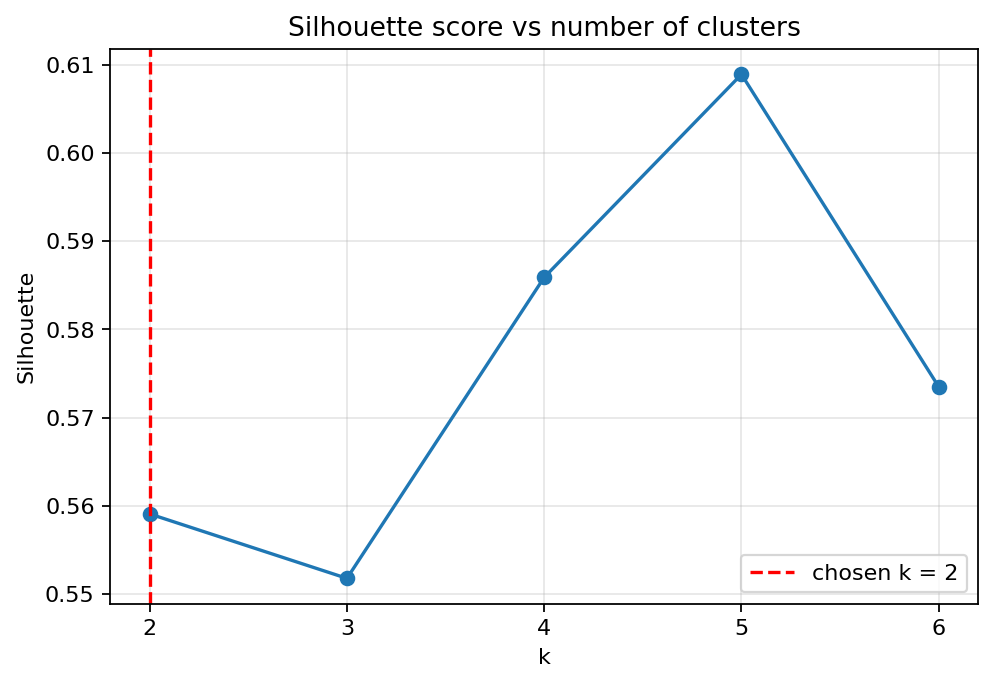

chart_02_pca_clusters.png


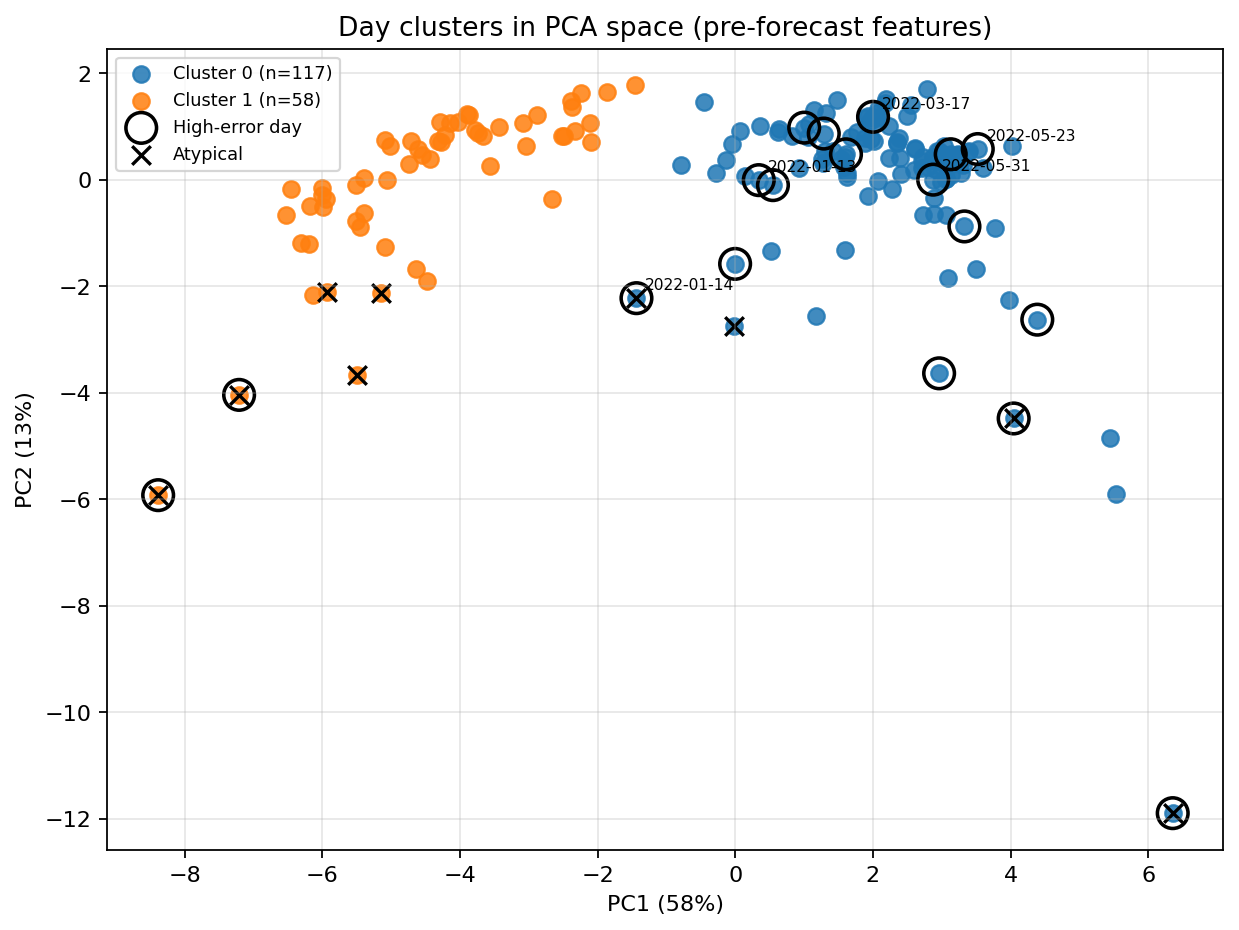

chart_03_pca_best_model.png


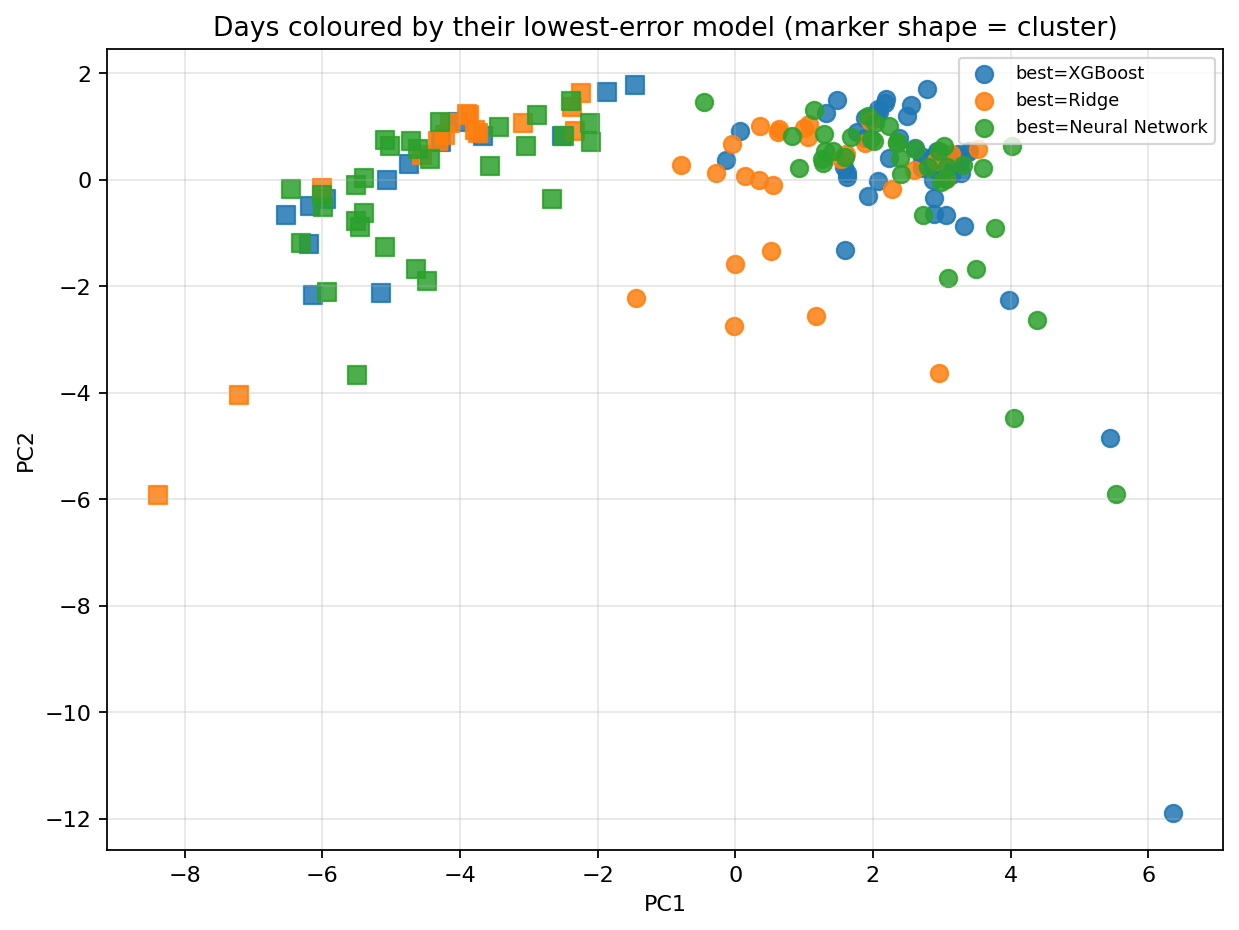

chart_04_cluster_model_mae_heatmap.png


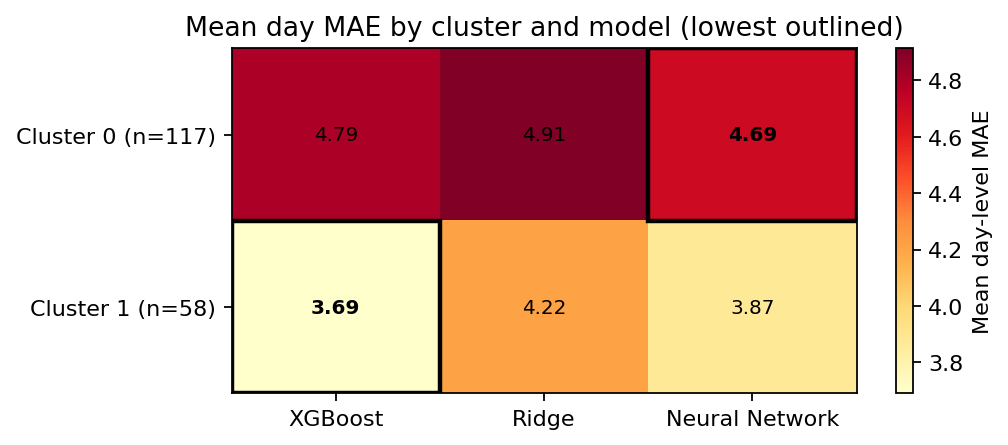

chart_05_vs_reference_by_cluster.png


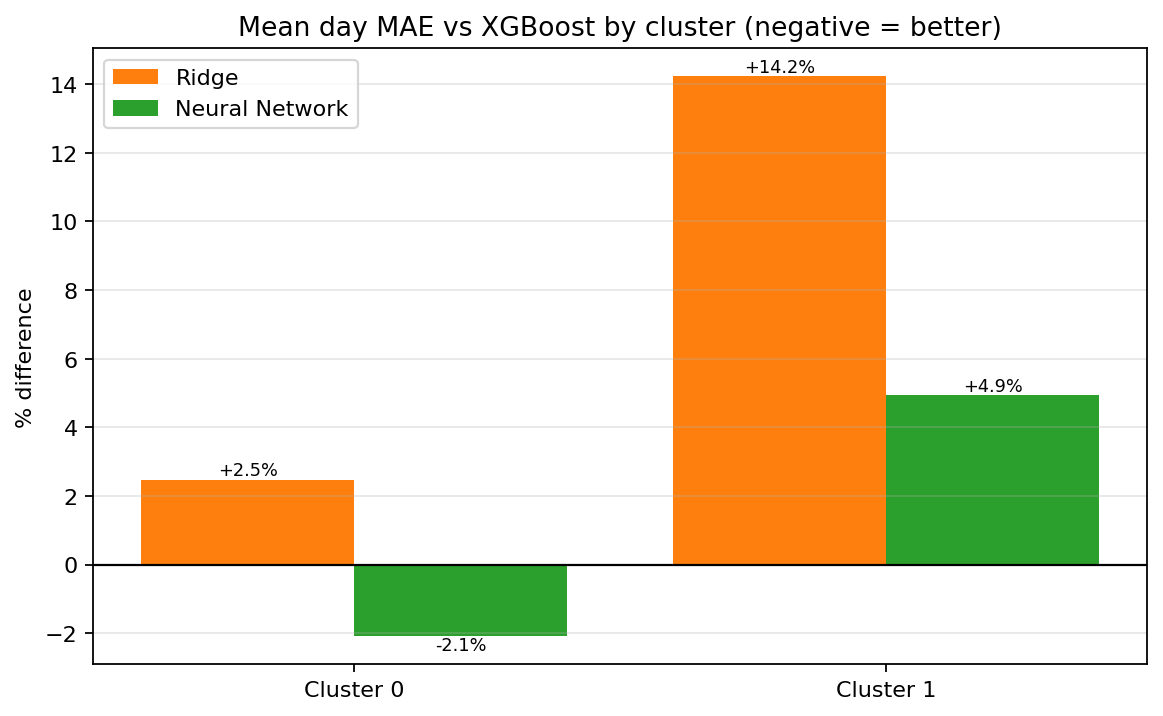

chart_06_mae_by_horizon_per_cluster.png


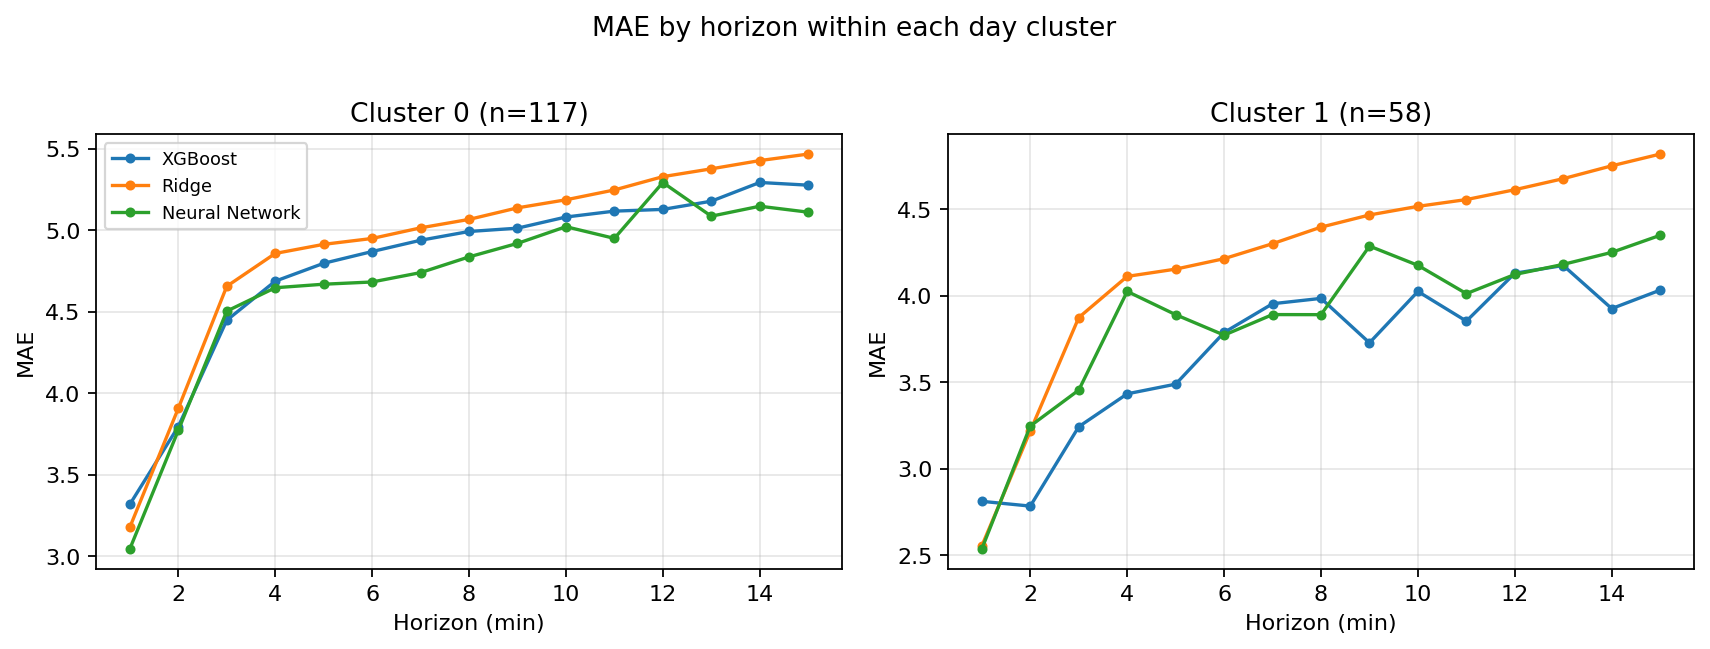

chart_07_day_mae_boxplot.png


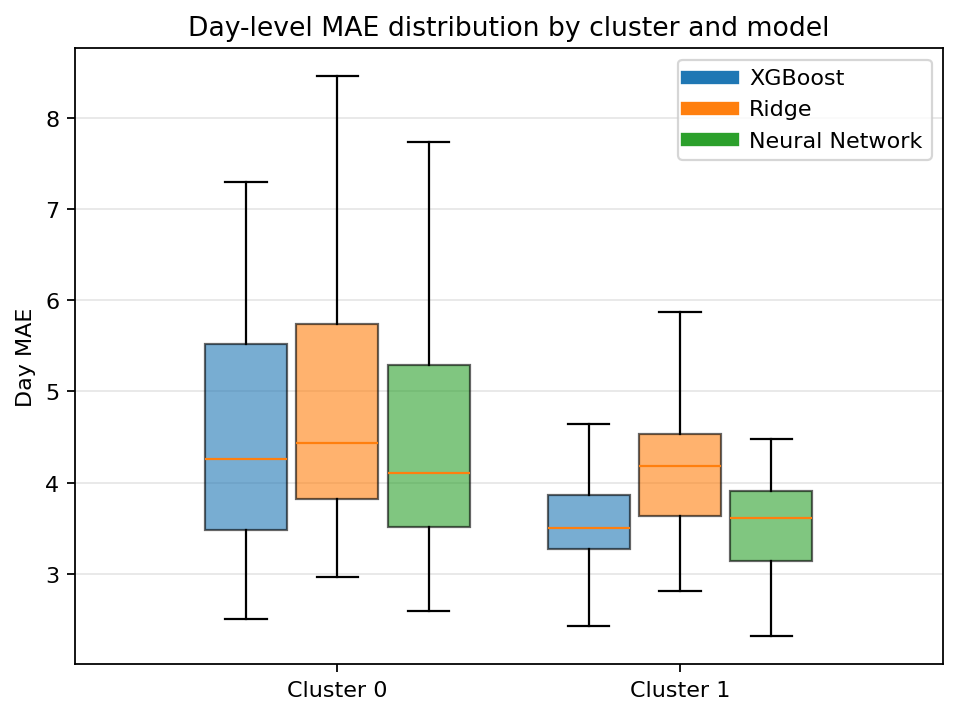

chart_08_best_model_share.png


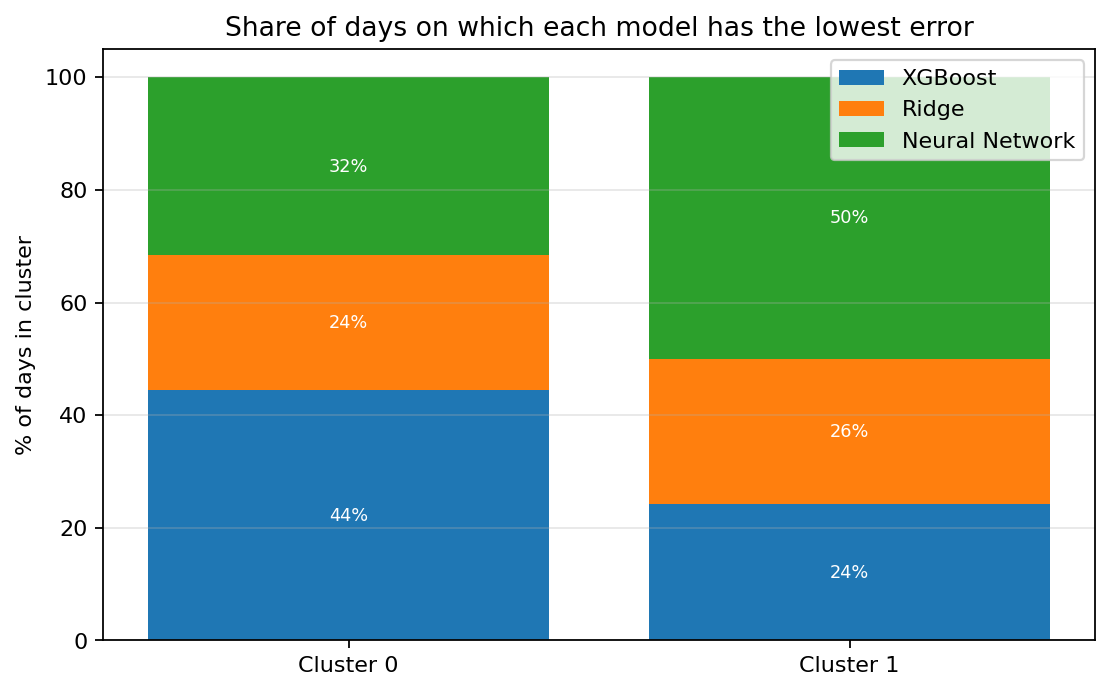

chart_09_selector_gain.png


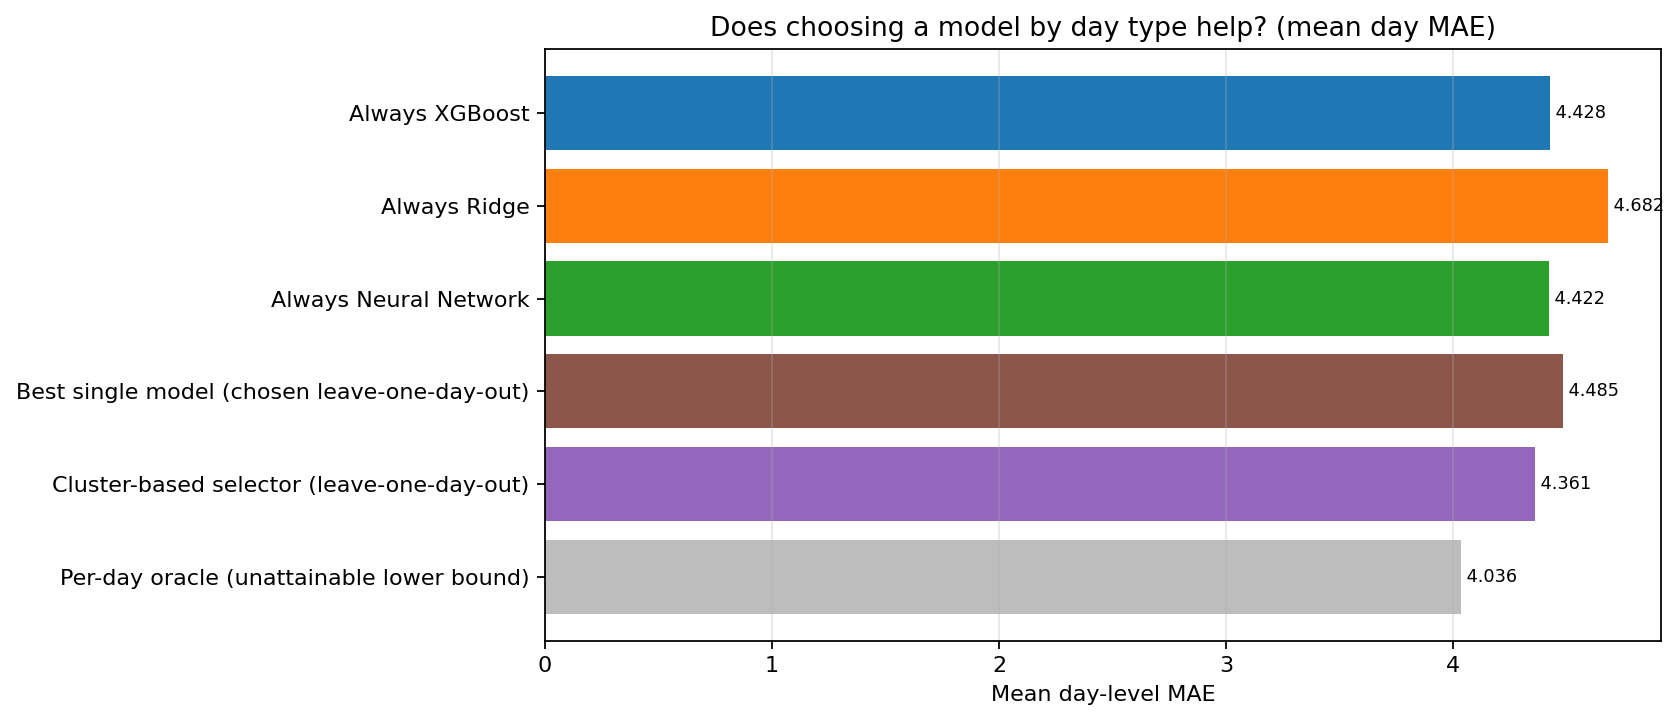

chart_10_cluster_profile_heatmap.png


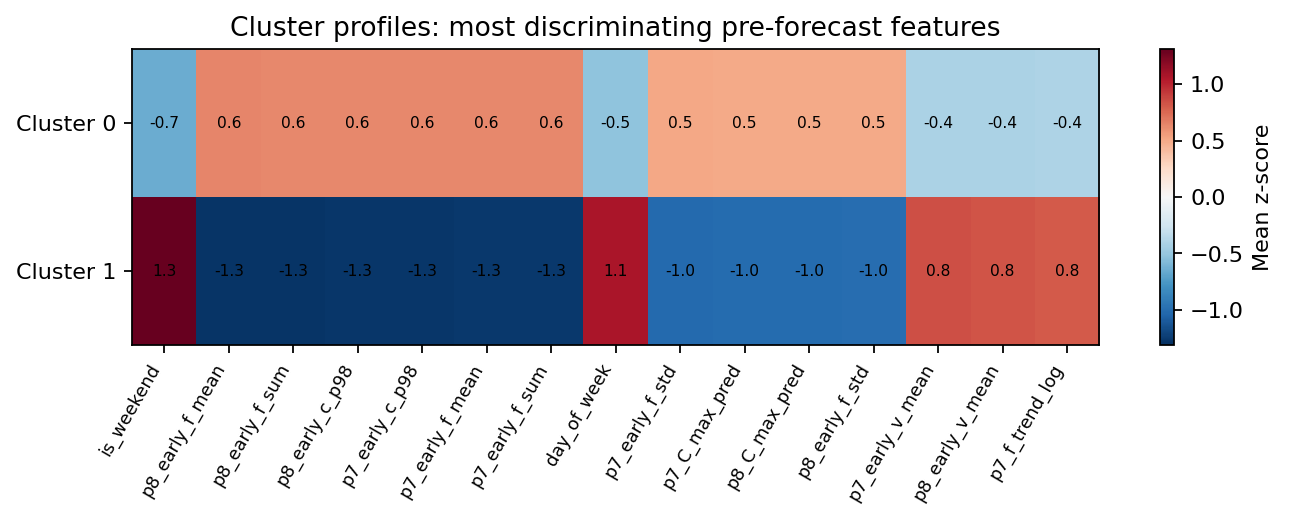

chart_11_cluster_day_of_week.png


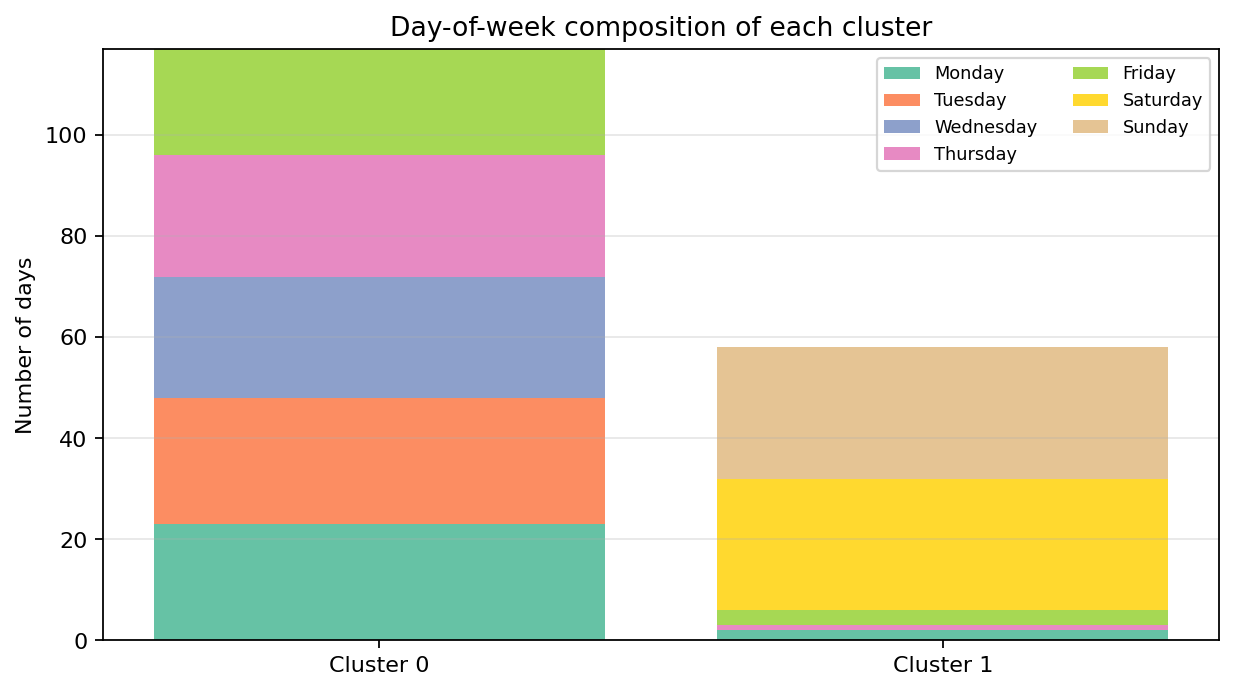

In [ ]:
"""
RESULT CLUSTERING: which kind of day suits which model? (XGBoost vs Ridge vs Neural Network, portal-8 flow)
================================================================================
Run AFTER v8_compare_xgb_ridge_nn_f.py. One row per calendar day.

Questions answered
  1. What day types exist, judged ONLY from information available before 07:30?
  2. Does forecast error depend on day type (per model)?
  3. Within each day type, which model has the lowest error, and is that difference supported
     by a paired test, or just noise?
  4. Would choosing a model by day type beat always using one model? (honest leave-one-day-out test)

Strict separation: clusters are formed from 04:00-07:30 summaries of portals 7 and 8 (speed, flow,
peak-capacity proxy, trends, zero-flow share) + day of week / weekend, plus the predicted daily
C_max if `corridor` is still in memory. NO actual AM-window values and NO forecast errors are used
to form clusters. Errors (vs the 5-min-smoothed target) are attached afterwards.

Method: StandardScaler -> PCA (>=90% variance, min 2 PCs) -> K-Means k=2..6 chosen by silhouette
(minimum cluster size enforced) -> Ward check (Adjusted Rand Index) -> IsolationForest for atypical days.

INPUTS
  output/model_comparison_f/predictions_all_models_long.csv
  processed_merged_evaluation_df_1min.csv (from v8_preprocess_merged_evaluation_data.py)

OUTPUTS (output/model_comparison_f/day_clustering/)
  daily_cluster_features.csv        pre-forecast features per day
  cluster_assignments.csv           cluster, PCA coords, atypical flag, per-model day MAE, best model
  cluster_summary_profiles.csv      mean z-score profile + plain-language descriptor per cluster
  cluster_model_performance.csv     pooled MAE/RMSE/R2/bias per cluster x model x horizon
  cluster_model_day_mae.csv         mean/median day-level MAE per cluster x model
  cluster_pairwise_tests.csv        paired tests vs the reference model within each cluster
  best_model_by_cluster.csv         lowest-error model per cluster + runner-up test + evidence label
  cluster_error_dependence_tests.csv Kruskal-Wallis: does day-level error differ across clusters?
  selector_gain.csv                 single models vs cluster-based selector vs per-day oracle
  high_error_days.csv, k_selection.csv, chart_*.png (also shown inline)

Statistics caveat: many cluster x model comparisons are made; treat p-values as guides, not proof.
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, friedmanchisquare
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, adjusted_rand_score, r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

# =============================================================================
# CONFIGURATION
# =============================================================================

PREDICTIONS_PATH = 'output/model_comparison_f/predictions_all_models_long.csv'
PROCESSED_CANDIDATES = [
    '/content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv',
    '/content/processed_merged_evaluation_df_1min.csv',
    'output/data_processing_eval/processed_merged_evaluation_df_1min.csv',
]
OUTPUT_DIR = 'output/model_comparison_f/day_clustering'
os.makedirs(OUTPUT_DIR, exist_ok=True)

REFERENCE_MODEL = 'XGBoost'
MODEL_ORDER = ['XGBoost', 'Ridge', 'Neural Network']
COLORS = {'XGBoost': '#1f77b4', 'Ridge': '#ff7f0e', 'Neural Network': '#2ca02c'}
PORTALS = [7, 8]
MORNING_START = pd.Timestamp('1900-01-01 04:00').time()
MORNING_END = pd.Timestamp('1900-01-01 07:30').time()
MORNING_SPLIT = pd.Timestamp('1900-01-01 05:45').time()
MIN_MORNING_COVERAGE = 0.50
EXPECTED_MORNING_ROWS = 210

K_MIN, K_MAX = 2, 6
FORCE_K = None
MIN_CLUSTER_FRACTION = 0.08
PCA_VARIANCE = 0.90
HIGH_ERROR_QUANTILE = 0.90
ATYPICAL_CONTAMINATION = 0.05
MIN_DAYS_FOR_TEST = 6
ALPHA = 0.05
SHORT_LONG_SPLIT = 8            # horizons <= split are "short", others "long" (for the group table)
RANDOM_STATE = 42

# =============================================================================
# 1. LOAD PREDICTIONS (all models, complete-horizon origins only)
# =============================================================================

if not os.path.isfile(PREDICTIONS_PATH):
    raise FileNotFoundError(f'{PREDICTIONS_PATH} not found. Run v8_compare_xgb_ridge_nn_f.py first.')
pred = pd.read_csv(PREDICTIONS_PATH, parse_dates=['Origin_DateTime'])
need = {'Model', 'Origin_Date', 'Horizon_min', 'Predicted_Level', 'Actual_Smoothed_Level', 'Has_Full_Horizon'}
if need - set(pred.columns):
    raise KeyError(f'predictions file missing: {sorted(need - set(pred.columns))}')
pred = pred[pred['Has_Full_Horizon'].astype(bool)].dropna(subset=['Actual_Smoothed_Level']).copy()
pred['Origin_Date'] = pd.to_datetime(pred['Origin_Date']).dt.strftime('%Y-%m-%d')
pred['Error'] = pred['Predicted_Level'] - pred['Actual_Smoothed_Level']
pred['Abs_Error'] = pred['Error'].abs()
pred['Sq_Error'] = pred['Error'] ** 2
found = list(pred.Model.unique())
MODELS = [m for m in MODEL_ORDER if m in found] + [m for m in found if m not in MODEL_ORDER]
if REFERENCE_MODEL not in MODELS:
    REFERENCE_MODEL = MODELS[0]
for m in MODELS:
    COLORS.setdefault(m, plt.get_cmap('tab10')(len(COLORS) % 10))
print(f'[Load] {len(pred):,} scored rows; {pred.Origin_Date.nunique()} day(s); models={MODELS}; reference={REFERENCE_MODEL}')

# =============================================================================
# 2. PRE-FORECAST DAILY FEATURES (04:00-07:30 only)
# =============================================================================

proc_path = next((p for p in PROCESSED_CANDIDATES if os.path.isfile(p)), None)
if proc_path is None:
    raise FileNotFoundError('Processed 1-minute data not found. Checked:\n  ' + '\n  '.join(PROCESSED_CANDIDATES))
proc = pd.read_csv(proc_path)
proc['DateTime'] = pd.to_datetime(proc['DateTime'])
proc = proc[proc['sequence'].isin(PORTALS)].copy()
proc['Date'] = proc['DateTime'].dt.date
proc['Time'] = proc['DateTime'].dt.time
proc['C'] = proc['v'] * proc['f']


def build_daily_features():
    frames = []
    for seq in PORTALS:
        p = proc[proc.sequence == seq]
        early = p[(p.Time >= MORNING_START) & (p.Time < MORNING_END)]
        counts = early.groupby('Date').size()
        early = early[early.Date.isin(counts[counts >= MIN_MORNING_COVERAGE * EXPECTED_MORNING_ROWS].index)]
        first, second = early[early.Time < MORNING_SPLIT], early[early.Time >= MORNING_SPLIT]
        g = early.groupby('Date')
        feats = pd.DataFrame({
            f'p{seq}_early_v_mean': early[early.v > 0].groupby('Date')['v'].mean(),
            f'p{seq}_early_f_mean': g['f'].mean(),
            f'p{seq}_early_f_std': g['f'].std(),
            f'p{seq}_early_f_sum': g['f'].sum(),
            f'p{seq}_early_c_p98': g['C'].quantile(0.98),
            f'p{seq}_early_zero_flow_frac': g['f'].apply(lambda s: float((s == 0).mean())),
        })
        fa, fb = first.groupby('Date')['f'].sum(), second.groupby('Date')['f'].sum()
        feats[f'p{seq}_f_trend_log'] = np.log((fb.reindex(feats.index).fillna(0) + 1) / (fa.reindex(feats.index).fillna(0) + 1))
        va = first[first.v > 0].groupby('Date')['v'].mean()
        vb = second[second.v > 0].groupby('Date')['v'].mean()
        feats[f'p{seq}_v_trend'] = vb.reindex(feats.index) - va.reindex(feats.index)
        frames.append(feats)
    daily = pd.concat(frames, axis=1, join='inner')
    idx = pd.to_datetime(daily.index)
    daily['day_of_week'] = idx.dayofweek
    daily['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    if 'corridor' in globals():
        cor = globals()['corridor']
        for seq in PORTALS:
            cols = [f'p{seq}_v', f'p{seq}_f', f'p{seq}_S_pred']
            if all(c in cor.columns for c in cols):
                s = cor[f'p{seq}_S_pred']
                cmax = (cor[f'p{seq}_v'] * cor[f'p{seq}_f'] / s).where(s > 0)
                daily[f'p{seq}_C_max_pred'] = cmax.groupby(cor['Date']).median().reindex(daily.index)
        print('[Features] Added predicted daily C_max from in-memory `corridor`.')
    else:
        print('[Features] `corridor` not in memory -> daily C_max_pred feature skipped.')
    daily.index = pd.to_datetime(daily.index).strftime('%Y-%m-%d')
    daily.index.name = 'Date'
    return daily


daily = build_daily_features()
common = sorted(set(daily.index) & set(pred.Origin_Date.unique()))
daily, pred = daily.loc[common], pred[pred.Origin_Date.isin(common)].copy()
print(f'[Features] {len(daily)} day(s) with features and scored predictions; {daily.shape[1]} feature(s).')
if len(daily) < 8:
    raise ValueError(f'Only {len(daily)} usable day(s); need at least 8 for meaningful clustering.')
daily.round(5).to_csv(os.path.join(OUTPUT_DIR, 'daily_cluster_features.csv'))

# =============================================================================
# 3. CLUSTER THE DAYS (pre-forecast information only)
# =============================================================================

X_df = daily.loc[:, daily.std(skipna=True) > 1e-9]
X_df = X_df.fillna(X_df.median())
names = list(X_df.columns)
X = StandardScaler().fit_transform(X_df.to_numpy(dtype=float))
Z_df = pd.DataFrame(X, index=X_df.index, columns=names)
pca = PCA(random_state=RANDOM_STATE).fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)
n_keep = max(2, int(np.argmax(cum >= PCA_VARIANCE) + 1))
Z = pca.transform(X)[:, :n_keep]
print(f'[Cluster] {len(names)} features -> {n_keep} PCs ({cum[n_keep - 1]:.1%} variance)')

min_size = max(3, int(np.ceil(MIN_CLUSTER_FRACTION * len(daily))))
k_upper = min(K_MAX, max(K_MIN, len(daily) // min_size))
k_rows, kms = [], {}
for k in range(K_MIN, k_upper + 1):
    km = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE).fit(Z)
    sizes = np.bincount(km.labels_, minlength=k)
    k_rows.append({'k': k, 'silhouette': round(float(silhouette_score(Z, km.labels_)), 4),
                   'min_cluster_size': int(sizes.min()), 'valid_min_size': bool(sizes.min() >= min_size)})
    kms[k] = km
k_table = pd.DataFrame(k_rows)
k_table.to_csv(os.path.join(OUTPUT_DIR, 'k_selection.csv'), index=False)
print('\n[Cluster] Candidate k:'); print(k_table.to_string(index=False))
if FORCE_K is not None:
    chosen_k = int(FORCE_K)
    kms.setdefault(chosen_k, KMeans(n_clusters=chosen_k, n_init=25, random_state=RANDOM_STATE).fit(Z))
else:
    pool = k_table[k_table.valid_min_size]
    chosen_k = int((pool if len(pool) else k_table).sort_values('silhouette', ascending=False).iloc[0]['k'])
print(f'[Cluster] Chosen k = {chosen_k}')

order = pd.Series(kms[chosen_k].labels_).value_counts().index.tolist()
labels = np.array([order.index(x) for x in kms[chosen_k].labels_])
ari = adjusted_rand_score(labels, AgglomerativeClustering(n_clusters=chosen_k, linkage='ward').fit_predict(Z))
print(f'[Cluster] K-Means vs Ward agreement (Adjusted Rand Index): {ari:.3f} (1 = identical)')
atypical = IsolationForest(contamination=ATYPICAL_CONTAMINATION, random_state=RANDOM_STATE).fit(X).predict(X) == -1

assign = pd.DataFrame({'Date': daily.index, 'Cluster': labels, 'PC1': Z[:, 0], 'PC2': Z[:, 1],
                       'Atypical_Day_Flag': atypical, 'Day_Name': pd.to_datetime(daily.index).day_name(),
                       'Is_Weekend': daily['is_weekend'].to_numpy()}).set_index('Date')
profile = Z_df.groupby(assign['Cluster']).mean()
descriptors = {c: '; '.join(f'{f} ({profile.loc[c, f]:+.2f} SD)' for f in profile.loc[c].abs().sort_values(ascending=False).head(4).index)
               for c in profile.index}
prof_out = profile.copy()
prof_out.insert(0, 'N_days', assign.Cluster.value_counts().sort_index())
prof_out.insert(1, 'Descriptor', pd.Series(descriptors))
prof_out.round(4).to_csv(os.path.join(OUTPUT_DIR, 'cluster_summary_profiles.csv'))
clusters = sorted(assign.Cluster.unique())

# =============================================================================
# 4. DAY-LEVEL ERRORS PER MODEL, THEN PER CLUSTER
# =============================================================================

day_mae = pred.groupby(['Origin_Date', 'Model']).Abs_Error.mean().unstack('Model')[MODELS].reindex(assign.index)
assign = assign.join(day_mae.add_prefix('MAE_'))
assign['Best_Model'] = day_mae.idxmin(axis=1)
assign['Difficulty_Score'] = day_mae.mean(axis=1).rank(pct=True)
assign['High_Error_Day'] = assign['Difficulty_Score'] >= assign['Difficulty_Score'].quantile(HIGH_ERROR_QUANTILE)
assign.round(5).to_csv(os.path.join(OUTPUT_DIR, 'cluster_assignments.csv'))

lab = pred.merge(assign[['Cluster']].reset_index().rename(columns={'Date': 'Origin_Date'}), on='Origin_Date')
perf_rows = []
for (c, m, h), g in lab.groupby(['Cluster', 'Model', 'Horizon_min']):
    a, p = g.Actual_Smoothed_Level.to_numpy(), g.Predicted_Level.to_numpy()
    perf_rows.append({'Cluster': c, 'Model': m, 'Horizon_min': int(h), 'N_days': g.Origin_Date.nunique(), 'N_rows': len(g),
                      'MAE': mean_absolute_error(a, p), 'RMSE': float(np.sqrt(mean_squared_error(a, p))),
                      'R2': r2_score(a, p) if len(g) > 2 and np.var(a) > 0 else np.nan, 'Bias': float(np.mean(p - a))})
perf = pd.DataFrame(perf_rows).sort_values(['Cluster', 'Model', 'Horizon_min'])
perf.round(5).to_csv(os.path.join(OUTPUT_DIR, 'cluster_model_performance.csv'), index=False)

cm_rows = []
for c in clusters:
    sub = day_mae[assign.Cluster == c]
    for m in MODELS:
        cm_rows.append({'Cluster': c, 'Model': m, 'N_days': int(sub[m].notna().sum()),
                        'Mean_day_MAE': sub[m].mean(), 'Median_day_MAE': sub[m].median(), 'Std_day_MAE': sub[m].std()})
cm = pd.DataFrame(cm_rows)
cm.round(5).to_csv(os.path.join(OUTPUT_DIR, 'cluster_model_day_mae.csv'), index=False)
mean_mat = cm.pivot(index='Cluster', columns='Model', values='Mean_day_MAE')[MODELS]


def paired(a, b):
    """a, b = day MAE of two models on the same days. Improvement > 0 means b is better than a."""
    d = (a - b).dropna()
    p = np.nan
    if len(d) >= MIN_DAYS_FOR_TEST and (d != 0).any():
        try:
            p = wilcoxon(d).pvalue
        except ValueError:
            p = np.nan
    return {'N_days': len(d), 'Mean_improvement': d.mean() if len(d) else np.nan,
            'Median_improvement': d.median() if len(d) else np.nan,
            'Share_days_b_better': float((d > 0).mean()) if len(d) else np.nan, 'Wilcoxon_p': p}


pair_rows = []
for c in clusters:
    sub = day_mae[assign.Cluster == c]
    for m in MODELS:
        if m != REFERENCE_MODEL:
            pair_rows.append({'Cluster': c, 'Reference': REFERENCE_MODEL, 'Model': m, **paired(sub[REFERENCE_MODEL], sub[m])})
for m in MODELS:
    if m != REFERENCE_MODEL:
        pair_rows.append({'Cluster': 'ALL', 'Reference': REFERENCE_MODEL, 'Model': m, **paired(day_mae[REFERENCE_MODEL], day_mae[m])})
pairs = pd.DataFrame(pair_rows)
pairs.round(5).to_csv(os.path.join(OUTPUT_DIR, 'cluster_pairwise_tests.csv'), index=False)

best_rows = []
for c in clusters:
    sub = day_mae[assign.Cluster == c]
    ranked = sub.mean().sort_values()
    best, second = ranked.index[0], (ranked.index[1] if len(ranked) > 1 else None)
    t = paired(sub[second], sub[best]) if second else {'N_days': 0, 'Wilcoxon_p': np.nan, 'Share_days_b_better': np.nan}
    if len(sub) < MIN_DAYS_FOR_TEST:
        evidence = f'too few days (<{MIN_DAYS_FOR_TEST}) to test'
    elif not np.isnan(t['Wilcoxon_p']) and t['Wilcoxon_p'] < ALPHA:
        evidence = f'supported (p={t["Wilcoxon_p"]:.3g} vs runner-up)'
    else:
        evidence = f'NOT clearly better than runner-up (p={t["Wilcoxon_p"]:.3g})' if not np.isnan(t['Wilcoxon_p']) else 'not testable'
    best_rows.append({'Cluster': c, 'N_days': len(sub), 'Lowest_error_model': best, 'Mean_day_MAE': ranked.iloc[0],
                      'Runner_up': second, 'Runner_up_MAE': ranked.iloc[1] if second else np.nan,
                      'Share_days_best_beats_runner_up': t['Share_days_b_better'], 'Evidence': evidence})
best_df = pd.DataFrame(best_rows)
best_df.round(5).to_csv(os.path.join(OUTPUT_DIR, 'best_model_by_cluster.csv'), index=False)

dep_rows = []
for m in MODELS:
    groups = [day_mae.loc[assign.Cluster == c, m].dropna().to_numpy() for c in clusters]
    groups = [g for g in groups if len(g)]
    try:
        H, pv = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    except ValueError:
        H, pv = np.nan, np.nan
    dep_rows.append({'Model': m, 'Test': 'Kruskal-Wallis: day MAE across clusters', 'H': H, 'p_value': pv})
if len(MODELS) >= 3 and len(day_mae.dropna()) >= MIN_DAYS_FOR_TEST:
    try:
        fr = friedmanchisquare(*[day_mae[m].to_numpy() for m in MODELS])
        dep_rows.append({'Model': 'ALL MODELS', 'Test': 'Friedman: do the models differ on the same days?',
                         'H': fr.statistic, 'p_value': fr.pvalue})
    except ValueError:
        pass
dep = pd.DataFrame(dep_rows)
dep.round(5).to_csv(os.path.join(OUTPUT_DIR, 'cluster_error_dependence_tests.csv'), index=False)

# Honest selector test: choose each day's model using only OTHER days (leave-one-day-out).
lab_series = assign.Cluster
sel_err, single_err = [], []
for d in day_mae.index:
    others = day_mae.drop(index=d)
    same = others[lab_series.drop(index=d) == lab_series[d]]
    pick_cluster = (same if len(same) else others).mean().idxmin()
    pick_single = others.mean().idxmin()
    sel_err.append(day_mae.loc[d, pick_cluster])
    single_err.append(day_mae.loc[d, pick_single])
gain_rows = [{'Strategy': f'Always {m}', 'Mean_day_MAE': day_mae[m].mean()} for m in MODELS]
gain_rows += [{'Strategy': 'Best single model (chosen leave-one-day-out)', 'Mean_day_MAE': float(np.mean(single_err))},
              {'Strategy': 'Cluster-based selector (leave-one-day-out)', 'Mean_day_MAE': float(np.mean(sel_err))},
              {'Strategy': 'Per-day oracle (unattainable lower bound)', 'Mean_day_MAE': float(day_mae.min(axis=1).mean())}]
gain = pd.DataFrame(gain_rows)
gain.round(5).to_csv(os.path.join(OUTPUT_DIR, 'selector_gain.csv'), index=False)

hard = assign[assign.High_Error_Day].sort_values('Difficulty_Score', ascending=False)
hard[['Cluster', 'Day_Name', 'Atypical_Day_Flag', 'Best_Model'] + [f'MAE_{m}' for m in MODELS]].round(4).to_csv(
    os.path.join(OUTPUT_DIR, 'high_error_days.csv'))

# =============================================================================
# 5. PRINTED SUMMARY
# =============================================================================

print('\n' + '=' * 96 + '\nDAY TYPES (what each cluster looks like BEFORE 07:30)\n' + '=' * 96)
for c in clusters:
    sub = assign[assign.Cluster == c]
    print(f'Cluster {c} (n={len(sub)}, {int(sub.Is_Weekend.sum())} weekend): {descriptors[c]}')
print('\n' + '=' * 96 + '\nMEAN DAY-LEVEL MAE: CLUSTER x MODEL (vehicles/min, lower is better)\n' + '=' * 96)
print(mean_mat.round(3).to_string())
print('\n' + '=' * 96 + '\nLOWEST-ERROR MODEL PER CLUSTER AND THE EVIDENCE\n' + '=' * 96)
print(best_df[['Cluster', 'N_days', 'Lowest_error_model', 'Mean_day_MAE', 'Runner_up', 'Evidence']].round(3).to_string(index=False))
print('\n' + '=' * 96 + '\nDOES ERROR DEPEND ON DAY TYPE? / DO MODELS DIFFER?\n' + '=' * 96)
print(dep.round(5).to_string(index=False))
print('\n' + '=' * 96 + '\nWOULD CHOOSING A MODEL BY DAY TYPE HELP? (leave-one-day-out)\n' + '=' * 96)
print(gain.round(4).to_string(index=False))
single_best = gain.iloc[len(MODELS)].Mean_day_MAE
selector = gain.iloc[len(MODELS) + 1].Mean_day_MAE
rel = (single_best - selector) / single_best * 100
print(f'\nCluster-based selection changes mean day MAE by {rel:+.1f}% relative to the best single model '
      f'({"a gain" if rel > 0 else "no gain"}).')
print(f'High-error days (top {round((1 - HIGH_ERROR_QUANTILE) * 100)}%): {len(hard)}; atypical: {int(hard.Atypical_Day_Flag.sum())}; '
      f'by cluster: {hard.Cluster.value_counts().sort_index().to_dict()}')

# =============================================================================
# 6. CHARTS
# =============================================================================

palette = plt.get_cmap('tab10')
saved = []


def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.close(fig)
    saved.append(path)


fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_table.k, k_table.silhouette, marker='o')
ax.axvline(chosen_k, color='red', linestyle='--', label=f'chosen k = {chosen_k}')
ax.set(title='Silhouette score vs number of clusters', xlabel='k', ylabel='Silhouette')
ax.set_xticks(k_table.k); ax.grid(alpha=0.3); ax.legend()
save(fig, 'chart_01_k_selection.png')

fig, ax = plt.subplots(figsize=(9, 6.5))
for c in clusters:
    s = assign[assign.Cluster == c]
    ax.scatter(s.PC1, s.PC2, s=55, color=palette(c % 10), alpha=0.85, label=f'Cluster {c} (n={len(s)})')
he = assign[assign.High_Error_Day]
ax.scatter(he.PC1, he.PC2, s=190, facecolors='none', edgecolors='black', linewidths=1.6, label='High-error day')
ax.scatter(assign[assign.Atypical_Day_Flag].PC1, assign[assign.Atypical_Day_Flag].PC2, s=70, marker='x', color='black', label='Atypical')
for d in hard.head(5).index:
    ax.annotate(d, (assign.loc[d, 'PC1'], assign.loc[d, 'PC2']), fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set(title='Day clusters in PCA space (pre-forecast features)', xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
save(fig, 'chart_02_pca_clusters.png')

markers = ['o', 's', '^', 'D', 'v', 'P']
fig, ax = plt.subplots(figsize=(9, 6.5))
for c in clusters:
    for m in MODELS:
        s = assign[(assign.Cluster == c) & (assign.Best_Model == m)]
        if len(s):
            ax.scatter(s.PC1, s.PC2, s=60, color=COLORS[m], marker=markers[c % len(markers)], alpha=0.85,
                       label=f'best={m}' if c == clusters[0] else None)
ax.set(title='Days coloured by their lowest-error model (marker shape = cluster)', xlabel='PC1', ylabel='PC2')
ax.grid(alpha=0.3)
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)
save(fig, 'chart_03_pca_best_model.png')

fig, ax = plt.subplots(figsize=(1.8 + 1.5 * len(MODELS), 1.4 + 0.7 * len(clusters)))
im = ax.imshow(mean_mat.to_numpy(), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
ax.set_yticks(range(len(clusters))); ax.set_yticklabels([f'Cluster {c} (n={int((assign.Cluster == c).sum())})' for c in mean_mat.index])
best_col = mean_mat.to_numpy().argmin(axis=1)
for i in range(mean_mat.shape[0]):
    for j in range(mean_mat.shape[1]):
        ax.text(j, i, f'{mean_mat.iat[i, j]:.2f}', ha='center', va='center', fontsize=9, fontweight='bold' if best_col[i] == j else 'normal')
    ax.add_patch(plt.Rectangle((best_col[i] - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))
fig.colorbar(im, ax=ax, label='Mean day-level MAE')
ax.set_title('Mean day MAE by cluster and model (lowest outlined)')
save(fig, 'chart_04_cluster_model_mae_heatmap.png')

fig, ax = plt.subplots(figsize=(8.5, 5))
others = [m for m in MODELS if m != REFERENCE_MODEL]
w = 0.8 / max(1, len(others))
for k, m in enumerate(others):
    diff = [(mean_mat.loc[c, m] - mean_mat.loc[c, REFERENCE_MODEL]) / mean_mat.loc[c, REFERENCE_MODEL] * 100 for c in clusters]
    bars = ax.bar(np.arange(len(clusters)) + k * w, diff, w, color=COLORS[m], label=m)
    for b, v in zip(bars, diff):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:+.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(np.arange(len(clusters)) + w * (len(others) - 1) / 2)
ax.set_xticklabels([f'Cluster {c}' for c in clusters])
ax.set(title=f'Mean day MAE vs {REFERENCE_MODEL} by cluster (negative = better)', ylabel='% difference')
ax.grid(axis='y', alpha=0.3); ax.legend()
save(fig, 'chart_05_vs_reference_by_cluster.png')

ncols = min(3, len(clusters))
nrows = int(np.ceil(len(clusters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 4 * nrows), squeeze=False)
for ax, c in zip(axes.ravel(), clusters):
    for m in MODELS:
        s = perf[(perf.Cluster == c) & (perf.Model == m)].sort_values('Horizon_min')
        ax.plot(s.Horizon_min, s.MAE, marker='o', markersize=3.5, color=COLORS[m], label=m)
    ax.set(title=f'Cluster {c} (n={int((assign.Cluster == c).sum())})', xlabel='Horizon (min)', ylabel='MAE')
    ax.grid(alpha=0.3)
axes.ravel()[0].legend(fontsize=8)
for ax in axes.ravel()[len(clusters):]:
    ax.axis('off')
fig.suptitle('MAE by horizon within each day cluster', y=1.01)
fig.tight_layout()
save(fig, 'chart_06_mae_by_horizon_per_cluster.png')

fig, ax = plt.subplots(figsize=(max(7, 2.4 * len(clusters)), 5))
width = 0.8 / len(MODELS)
for k, m in enumerate(MODELS):
    data = [day_mae.loc[assign.Cluster == c, m].dropna().to_numpy() for c in clusters]
    bp = ax.boxplot(data, positions=np.arange(len(clusters)) + k * width, widths=width * 0.9, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS[m]); patch.set_alpha(0.6)
    ax.plot([], [], color=COLORS[m], linewidth=6, label=m)
ax.set_xticks(np.arange(len(clusters)) + width * (len(MODELS) - 1) / 2)
ax.set_xticklabels([f'Cluster {c}' for c in clusters])
ax.set(title='Day-level MAE distribution by cluster and model', ylabel='Day MAE')
ax.grid(axis='y', alpha=0.3); ax.legend()
save(fig, 'chart_07_day_mae_boxplot.png')

share = pd.crosstab(assign.Cluster, assign.Best_Model).reindex(columns=MODELS, fill_value=0)
share = share.div(share.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(8, 4.8))
bottom = np.zeros(len(share))
for m in MODELS:
    ax.bar([f'Cluster {c}' for c in share.index], share[m], bottom=bottom, color=COLORS[m], label=m)
    for i, v in enumerate(share[m]):
        if v >= 8:
            ax.text(i, bottom[i] + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white')
    bottom += share[m].to_numpy()
ax.set(title='Share of days on which each model has the lowest error', ylabel='% of days in cluster')
ax.legend(); ax.grid(axis='y', alpha=0.3)
save(fig, 'chart_08_best_model_share.png')

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [COLORS.get(s.replace('Always ', ''), '#9a9a9a') for s in gain.Strategy]
colors[-3:] = ['#8c564b', '#9467bd', '#bdbdbd']
bars = ax.barh(gain.Strategy, gain.Mean_day_MAE, color=colors)
for b, v in zip(bars, gain.Mean_day_MAE):
    ax.text(v, b.get_y() + b.get_height() / 2, f' {v:.3f}', va='center', fontsize=8)
ax.invert_yaxis()
ax.set(title='Does choosing a model by day type help? (mean day MAE)', xlabel='Mean day-level MAE')
ax.grid(axis='x', alpha=0.3)
save(fig, 'chart_09_selector_gain.png')

spread = profile.std(axis=0).sort_values(ascending=False).head(15).index
hm = profile[spread]
fig, ax = plt.subplots(figsize=(max(8, 0.65 * len(spread)), 1.0 + 0.7 * len(hm)))
vmax = max(1e-6, float(np.abs(hm.to_numpy()).max()))
im = ax.imshow(hm.to_numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(spread))); ax.set_xticklabels(spread, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(hm))); ax.set_yticklabels([f'Cluster {c}' for c in hm.index])
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f'{hm.iat[i, j]:.1f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, label='Mean z-score')
ax.set_title('Cluster profiles: most discriminating pre-forecast features')
save(fig, 'chart_10_cluster_profile_heatmap.png')

comp = pd.crosstab(assign.Cluster, assign.Day_Name)
order_days = [d for d in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] if d in comp.columns]
comp = comp[order_days]
fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(comp))
for i, d in enumerate(order_days):
    ax.bar([f'Cluster {c}' for c in comp.index], comp[d], bottom=bottom, label=d, color=plt.get_cmap('Set2')(i % 8))
    bottom += comp[d].to_numpy()
ax.set(title='Day-of-week composition of each cluster', ylabel='Number of days')
ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
save(fig, 'chart_11_cluster_day_of_week.png')

print(f'\n[Done] Tables and {len(saved)} chart(s) saved in {OUTPUT_DIR}')
try:
    from IPython.display import display, Image
    for p in saved:
        print(os.path.basename(p))
        display(Image(filename=p))
except ImportError:
    pass

# S_pred

In [ ]:
"""
S_pred -- ALL THREE MODELS AT ONCE: XGBoost vs Ridge vs Neural Network (portal 8), prediction + full metrics
================================================================================
Loads from MODEL_DIR and evaluates the three final models on the SAME processed merged evaluation data:
  XGBoost: fS_prediction_model_p78_FINAL_cmax_v82.joblib                 trained_models['S_pred']
  Ridge:   fS_prediction_model_p78_FINAL_cmax_v82_RIDGE.joblib           trained_models['S_pred']
  NN:      nn_final_metadata.joblib (targets['S_pred']) + nn_S_pred_h01.keras ... nn_S_pred_h15.keras
  C_max:   cmax_prediction_model_p78_v82.joblib

FAIRNESS: one shared C_max v8.2 -> S_pred -> 18-feature frame, one set of forecast origins, one set of actuals.
The run stops if the three models disagree on feature order or target setup (smoothing, delta).

HOW S_pred IS PREDICTED: the models are trained on the CHANGE from the current value (predict_delta = True). Each model's
output has the current raw S_pred at the origin added back to give a LEVEL. Persistence ("S stays where it is") is a
zero-change forecast, so skill = 1 - model_error / persistence_error shows the value of the learned change alone.

RELIABLE RANGE: S_pred was reliable only through ~+8 min (read from the artifacts). Results are given per horizon and
pooled for the operational range (+1..limit) vs the informational range beyond it (shaded on the charts).

METRICS: MAE, RMSE, MAPE, sMAPE, R2, bias, median AE, P90 AE + persistence baseline and skill. Primary = vs the 5-min
smoothed target; secondary = vs the raw one-minute value. MAPE leaves out actuals below MAPE_MIN_ACTUAL (counts reported).

OUTPUTS: output/model_comparison_S_pred/
  predictions_all_models_long.csv, horizon_metrics_primary_smoothed.csv, horizon_metrics_secondary_raw.csv,
  overall_summary.csv, range_summary.csv, horizon_winners.csv, day_level_model_comparison.csv,
  day_level_mae_operational.csv, model_artifact_audit.csv, run_summary.json, chart_*.png (also shown inline)
"""

import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =============================================================================
# CONFIGURATION
# =============================================================================

TARGET = 'S_pred'
MODEL_DIR = '/content/drive/MyDrive/AH2179 GP5/prediction model v8.2 (portals 7-8, time-aware)'
XGB_PATH = os.path.join(MODEL_DIR, 'fS_prediction_model_p78_FINAL_cmax_v82.joblib')
RIDGE_PATH = os.path.join(MODEL_DIR, 'fS_prediction_model_p78_FINAL_cmax_v82_RIDGE.joblib')
CMAX_PATH = os.path.join(MODEL_DIR, 'cmax_prediction_model_p78_v82.joblib')
NN_METADATA_CANDIDATES = [os.path.join(MODEL_DIR, 'nn_final_metadata.joblib'),
                          os.path.join(MODEL_DIR, 'final_models', 'nn_final_metadata.joblib')]
PROCESSED_EVAL_CANDIDATES = [
    '/content/drive/MyDrive/AH2179 GP5/Colab/processed_merged_evaluation_df_1min.csv',
    '/content/processed_merged_evaluation_df_1min.csv',
    'output/data_processing_eval/processed_merged_evaluation_df_1min.csv',
]
OUTPUT_ROOT = 'output'
OUTPUT_DIR = os.path.join(OUTPUT_ROOT, f'model_comparison_{TARGET}')
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXPECTED_CMAX_FEATURES = ['v', 'f', 'c_early', 'f_trend_ratio_log', 'v_trend_delta', 'day_of_week', 'is_weekend']
AM_WINDOW_START = pd.Timestamp('1900-01-01 07:30').time()
AM_WINDOW_END = pd.Timestamp('1900-01-01 08:30').time()
MORNING_START = pd.Timestamp('1900-01-01 04:00').time()
MORNING_END = pd.Timestamp('1900-01-01 07:30').time()
MORNING_SPLIT = pd.Timestamp('1900-01-01 05:45').time()
MIN_COVERAGE = 0.50
MAPE_MIN_ACTUAL = 0.05
COLORS = {'XGBoost': '#1f77b4', 'Ridge': '#ff7f0e', 'Neural Network': '#2ca02c', 'Persistence': '#7f7f7f'}

# =============================================================================
# LOAD AND NORMALISE THE THREE ARTIFACT FORMATS
# =============================================================================

def first_file(paths):
    return next((p for p in paths if os.path.isfile(p)), None)


if not os.path.isdir('/content/drive/MyDrive'):
    raise RuntimeError("Google Drive is not mounted. Run: from google.colab import drive; drive.mount('/content/drive')")
for path in [XGB_PATH, RIDGE_PATH, CMAX_PATH]:
    if not os.path.isfile(path):
        raise FileNotFoundError(f'Missing model artifact: {path}')
nn_metadata_path = first_file(NN_METADATA_CANDIDATES)
if nn_metadata_path is None:
    raise FileNotFoundError('NN metadata not found. Checked:\n  ' + '\n  '.join(NN_METADATA_CANDIDATES))

xgb_artifact, ridge_artifact = joblib.load(XGB_PATH), joblib.load(RIDGE_PATH)
nn_metadata, cmax_artifact = joblib.load(nn_metadata_path), joblib.load(CMAX_PATH)
if list(cmax_artifact.get('feature_order', [])) != EXPECTED_CMAX_FEATURES:
    raise ValueError(f"C_max feature mismatch. Expected {EXPECTED_CMAX_FEATURES}; found {cmax_artifact.get('feature_order')}")

try:
    import tensorflow as tf
except ImportError as error:
    raise ImportError('TensorFlow is required to load the NN .keras models.') from error


def sklearn_entry(artifact, label):
    if TARGET not in artifact.get('trained_models', {}):
        raise KeyError(f'{label} artifact lacks trained_models["{TARGET}"]')
    entry = artifact['trained_models'][TARGET]
    missing = {'models', 'scaler', 'feature_cols'} - set(entry)
    if missing:
        raise KeyError(f'{label} {TARGET} entry missing {sorted(missing)}')
    return entry


xgb_entry, ridge_entry = sklearn_entry(xgb_artifact, 'XGBoost'), sklearn_entry(ridge_artifact, 'Ridge')
if TARGET not in nn_metadata.get('targets', {}):
    raise KeyError(f'NN metadata has no targets["{TARGET}"]; found {list(nn_metadata.get("targets", {}))}')
nn_entry = nn_metadata['targets'][TARGET]
missing_nn = {'scaler', 'feature_cols'} - set(nn_entry)
if missing_nn:
    raise KeyError(f'NN {TARGET} metadata missing {sorted(missing_nn)}. Re-export nn_final_metadata.joblib after structure alignment.')

FORECAST_STEPS = int(xgb_artifact['forecast_steps'])
TARGET_PORTAL = int(xgb_artifact['target_portal_seq'])
ACTIVE_PORTALS = list(xgb_artifact['active_portals'])
LAG_STEPS = list(xgb_artifact.get('lag_step_list', [1, 2]))
CAPACITY_MODELS = cmax_artifact['portal_models']
CAPACITY_FEATURES = list(cmax_artifact['feature_order'])

model_entries = {'XGBoost': xgb_entry, 'Ridge': ridge_entry, 'Neural Network': nn_entry}
MODELS = list(model_entries)
REFERENCE_MODEL = 'XGBoost'
base_features = list(xgb_entry['feature_cols'])
SMOOTH_WINDOW = int(xgb_entry.get('smooth_window', 5))
DELTA_MODE = bool(xgb_entry.get('predict_delta', False))
RELIABLE_THROUGH = int(xgb_entry.get('documented_reliable_through_min', FORECAST_STEPS))

audit_rows = []
for name, entry in model_entries.items():
    cols = list(entry['feature_cols'])
    if cols != base_features:
        raise ValueError(f'{name} feature order differs from XGBoost; the comparison would be invalid.')
    if len(cols) != 18:
        raise ValueError(f'{name} has {len(cols)} inputs; expected 18.')
    sw, dm = int(entry.get('smooth_window', 5)), bool(entry.get('predict_delta', False))
    if sw != SMOOTH_WINDOW or dm != DELTA_MODE:
        raise ValueError(f'{name} target configuration differs from XGBoost: smooth_window={sw}, predict_delta={dm} '
                         f'(XGBoost: {SMOOTH_WINDOW}, {DELTA_MODE}). Models are not comparable.')
    audit_rows.append({'Model': name, 'N_features': len(cols), 'Smooth_window': sw, 'Predict_delta': dm,
                       'Documented_reliable_through_min': entry.get('documented_reliable_through_min', np.nan)})
pd.DataFrame(audit_rows).to_csv(os.path.join(OUTPUT_DIR, 'model_artifact_audit.csv'), index=False)
print(f'[Models] {TARGET}: smooth_window={SMOOTH_WINDOW}, predict_delta={DELTA_MODE} (identical across all three), '
      f'reliable through +{RELIABLE_THROUGH} min')

raw_paths = nn_entry.get('model_paths') or {}
paths_by_h = {int(k): v for k, v in raw_paths.items()} if isinstance(raw_paths, dict) else {i + 1: p for i, p in enumerate(raw_paths)}
resolved_nn = {}
for h in range(1, FORECAST_STEPS + 1):
    default_name = f'nn_{TARGET}_h{h:02d}.keras'
    candidates = []
    if h in paths_by_h:
        candidates += [paths_by_h[h], os.path.join(MODEL_DIR, os.path.basename(paths_by_h[h])),
                       os.path.join(MODEL_DIR, 'final_models', os.path.basename(paths_by_h[h]))]
    candidates += [os.path.join(MODEL_DIR, default_name), os.path.join(MODEL_DIR, 'final_models', default_name)]
    found = first_file(candidates)
    if found is None:
        raise FileNotFoundError(f'NN {TARGET} horizon +{h} model not found. Checked:\n  ' + '\n  '.join(candidates))
    resolved_nn[h] = found
nn_models = {h: tf.keras.models.load_model(p, compile=False) for h, p in resolved_nn.items()}
print('[Models] XGBoost, Ridge and Neural Network loaded; features and target configuration match.')

# =============================================================================
# LOAD PROCESSED DATA
# =============================================================================

proc_path = first_file(PROCESSED_EVAL_CANDIDATES)
if proc_path is None:
    raise FileNotFoundError('Processed merged evaluation file not found. Checked:\n  ' + '\n  '.join(PROCESSED_EVAL_CANDIDATES))
raw_df = pd.read_csv(proc_path)
miss = [c for c in ['sequence', 'DateTime', 'v', 'f'] if c not in raw_df.columns]
if miss:
    raise KeyError(f'{proc_path} lacks {miss}; run the merged evaluation preprocessing first.')
raw_df['DateTime'] = pd.to_datetime(raw_df['DateTime'])
raw_df['sequence'] = raw_df['sequence'].astype(int)
raw_df = raw_df.sort_values(['sequence', 'DateTime']).reset_index(drop=True)
absent = [p for p in ACTIVE_PORTALS if p not in set(raw_df.sequence)]
if absent:
    raise ValueError(f'Processed evaluation data lacks portal(s) {absent}')
print(f'[Data] {proc_path}: {len(raw_df):,} rows; {raw_df.DateTime.dt.date.nunique()} day(s); '
      f'{raw_df.DateTime.min()} -> {raw_df.DateTime.max()}')

# =============================================================================
# SHARED C_max v8.2 -> S_pred -> 18 FEATURE FRAME
# =============================================================================

def expected_rows(start, end):
    return int((pd.Timestamp(f'1900-01-01 {end}') - pd.Timestamp(f'1900-01-01 {start}')).total_seconds() / 60) + 1


def daily_capacity(seq):
    p = raw_df[raw_df.sequence == seq].copy()
    p['Date'], p['Time'] = p.DateTime.dt.date, p.DateTime.dt.time
    p['C'] = p.v * p.f
    mask = (p.Time >= MORNING_START) & (p.Time < MORNING_END)
    counts = p.loc[mask].groupby('Date').size()
    valid = set(counts[counts >= MIN_COVERAGE * expected_rows(MORNING_START, MORNING_END)].index)
    all_days = set(p.Date.unique())
    p = p[p.Date.isin(valid)].copy()
    early = p[(p.Time >= MORNING_START) & (p.Time < MORNING_END)]
    first = p[(p.Time >= MORNING_START) & (p.Time < MORNING_SPLIT)]
    second = p[(p.Time >= MORNING_SPLIT) & (p.Time < MORNING_END)]
    v = early.groupby('Date').v.mean().rename('v')
    f = early.groupby('Date').f.sum().rename('f')
    c = early.groupby('Date').C.quantile(.98).rename('c_early')
    halves = pd.concat([first.groupby('Date').f.sum().rename('a'), second.groupby('Date').f.sum().rename('b')], axis=1).fillna(0.)
    fr = np.log((halves.b + 1.) / (halves.a + 1.)).rename('f_trend_ratio_log')
    vv = pd.concat([first.groupby('Date').v.mean().rename('a'), second.groupby('Date').v.mean().rename('b')], axis=1).fillna(0.)
    vd = (vv.b - vv.a).rename('v_trend_delta')
    feats = pd.concat([v, f, c, fr, vd], axis=1).reset_index().dropna()
    dt = pd.to_datetime(feats.Date)
    feats['day_of_week'] = dt.dt.dayofweek.astype(int)
    feats['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    cap = CAPACITY_MODELS[seq]
    feats['C_max_pred'] = cap['model'].predict(cap['scaler'].transform(feats[CAPACITY_FEATURES].to_numpy(float)))
    print(f'  [C_max] portal {seq}: {len(feats)} of {len(all_days)} day(s) usable')
    return feats[['Date', 'C_max_pred']]


def build_corridor():
    caps = {p: daily_capacity(p) for p in ACTIVE_PORTALS}
    frames = {}
    for p in ACTIVE_PORTALS:
        d = raw_df[raw_df.sequence == p][['DateTime', 'v', 'f']].copy()
        d['Date'] = d.DateTime.dt.date
        d['C'] = d.v * d.f
        d = d.merge(caps[p], on='Date', how='inner').sort_values('DateTime').reset_index(drop=True)
        d['S_pred'] = d.C / d.C_max_pred
        for var in ['v', 'f', 'S_pred']:
            for lag in LAG_STEPS:
                d[f'{var}_lag{lag}'] = d.groupby('Date')[var].transform(lambda s, k=lag: s.shift(k).bfill())
        rename = {var: f'p{p}_{var}' for var in ['v', 'f', 'S_pred']}
        rename.update({f'{var}_lag{lag}': f'p{p}_{var}_lag{lag}' for var in ['v', 'f', 'S_pred'] for lag in LAG_STEPS})
        d = d.rename(columns=rename)
        frames[p] = d[['DateTime', 'Date'] + list(rename.values())]
    out = frames[ACTIVE_PORTALS[0]]
    for p in ACTIVE_PORTALS[1:]:
        out = out.merge(frames[p], on=['DateTime', 'Date'], how='inner')
    t = out.DateTime.dt.time
    counts = out.loc[(t >= AM_WINDOW_START) & (t <= AM_WINDOW_END)].groupby('Date').size()
    valid = set(counts[counts >= MIN_COVERAGE * expected_rows(AM_WINDOW_START, AM_WINDOW_END)].index)
    out = out[out.Date.isin(valid)].sort_values('DateTime').reset_index(drop=True)
    if out.empty:
        raise ValueError('No valid days remain (need 04:00-07:30 and 07:30-08:30 coverage for portals 7 and 8).')
    return out


print('\n[Features] Rebuilding one shared evaluation feature frame...')
corridor = build_corridor()
print(f'[Features] corridor={corridor.shape}; valid days={corridor.Date.nunique()}')

# =============================================================================
# SHARED ORIGINS + ACTUALS, THEN THREE MODELS' LEVEL PREDICTIONS
# =============================================================================

tcol = f'p{TARGET_PORTAL}_{TARGET}'
smooth_series = (corridor[tcol] if SMOOTH_WINDOW <= 1 else corridor.groupby('Date')[tcol].transform(
    lambda s: s.rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean()))
ts = pd.DataFrame({'DateTime': corridor.DateTime, 'raw': corridor[tcol].to_numpy(), 'smooth': smooth_series.to_numpy()}).set_index('DateTime')
origins = corridor[(corridor.DateTime.dt.time >= AM_WINDOW_START) & (corridor.DateTime.dt.time <= AM_WINDOW_END)].copy()
X = origins[base_features].to_numpy(float)
if not np.isfinite(X).all():
    raise ValueError('Non-finite values in the shared model inputs.')
current = origins[tcol].to_numpy(float)

scaled = {n: e['scaler'].transform(X) for n, e in model_entries.items()}
raw_outputs = {
    'XGBoost': {h: xgb_entry['models'][h - 1].predict(scaled['XGBoost']) for h in range(1, FORECAST_STEPS + 1)},
    'Ridge': {h: ridge_entry['models'][h - 1].predict(scaled['Ridge']) for h in range(1, FORECAST_STEPS + 1)},
    'Neural Network': {h: nn_models[h].predict(scaled['Neural Network'], verbose=0).reshape(-1) for h in range(1, FORECAST_STEPS + 1)},
}

frames = []
for name, outputs in raw_outputs.items():
    for h in range(1, FORECAST_STEPS + 1):
        level = outputs[h] + current if DELTA_MODE else outputs[h]
        tt = origins.DateTime + pd.Timedelta(minutes=h)
        same_day = (tt.dt.date == origins.Date).to_numpy()
        frames.append(pd.DataFrame({
            'Model': name, 'Target': TARGET, 'Origin_DateTime': origins.DateTime.to_numpy(),
            'Origin_Date': origins.Date.astype(str).to_numpy(), 'Origin_Time': origins.DateTime.dt.strftime('%H:%M').to_numpy(),
            'Horizon_min': h, 'Target_DateTime': tt.to_numpy(), 'Current_Raw_Value': current, 'Predicted_Level': level,
            'Actual_Smoothed_Level': np.where(same_day, ts.smooth.reindex(tt).to_numpy(), np.nan),
            'Actual_Raw_Level': np.where(same_day, ts.raw.reindex(tt).to_numpy(), np.nan),
            'Smoothing_Window': SMOOTH_WINDOW, 'Predict_Delta': DELTA_MODE, 'Documented_Reliable_Through_Min': RELIABLE_THROUGH}))
pred = pd.concat(frames, ignore_index=True)
full = pred.dropna(subset=['Actual_Smoothed_Level']).groupby(['Model', 'Origin_DateTime']).size().rename('n').reset_index()
full = full[full.n == FORECAST_STEPS][['Model', 'Origin_DateTime']].assign(Has_Full_Horizon=True)
pred = pred.merge(full, on=['Model', 'Origin_DateTime'], how='left')
pred['Has_Full_Horizon'] = pred.Has_Full_Horizon.fillna(False).astype(bool)
pred['Residual_vs_Smoothed'] = pred.Predicted_Level - pred.Actual_Smoothed_Level
pred['Residual_vs_Raw'] = pred.Predicted_Level - pred.Actual_Raw_Level
pred.to_csv(os.path.join(OUTPUT_DIR, 'predictions_all_models_long.csv'), index=False)
scored = pred[pred.Has_Full_Horizon].copy()
if scored.empty:
    raise ValueError('No origins have a complete +15 min future, so nothing can be scored.')

# =============================================================================
# METRICS
# =============================================================================

def metrics(actual, estimate):
    a, e = np.asarray(actual, float), np.asarray(estimate, float)
    ok = np.isfinite(a) & np.isfinite(e)
    a, e = a[ok], e[ok]
    err, ae = e - a, np.abs(e - a)
    nz = a >= MAPE_MIN_ACTUAL
    den = np.abs(a) + np.abs(e)
    sm = den > 1e-9
    return {'N': len(a), 'MAE': mean_absolute_error(a, e), 'RMSE': float(np.sqrt(mean_squared_error(a, e))),
            'MAPE_pct': float(np.mean(ae[nz] / a[nz]) * 100) if nz.any() else np.nan, 'MAPE_N': int(nz.sum()),
            'sMAPE_pct': float(np.mean(2 * ae[sm] / den[sm]) * 100) if sm.any() else np.nan,
            'R2': r2_score(a, e), 'Bias': float(err.mean()), 'Median_AE': float(np.median(ae)), 'P90_AE': float(np.quantile(ae, .9))}


primary_rows, raw_rows = [], []
for (name, h), g in scored.groupby(['Model', 'Horizon_min']):
    pm = metrics(g.Actual_Smoothed_Level, g.Predicted_Level)
    base = metrics(g.Actual_Smoothed_Level, g.Current_Raw_Value)
    primary_rows.append({'Model': name, 'Horizon_min': h, **pm, 'Persistence_MAE': base['MAE'], 'Persistence_RMSE': base['RMSE'],
                         'Persistence_R2': base['R2'], 'MAE_Skill_vs_Persistence': 1 - pm['MAE'] / base['MAE'],
                         'RMSE_Skill_vs_Persistence': 1 - pm['RMSE'] / base['RMSE']})
    raw_rows.append({'Model': name, 'Horizon_min': h, **metrics(g.Actual_Raw_Level, g.Predicted_Level)})
primary, raw_metrics = pd.DataFrame(primary_rows), pd.DataFrame(raw_rows)
for df, fname in [(primary, 'horizon_metrics_primary_smoothed.csv'), (raw_metrics, 'horizon_metrics_secondary_raw.csv')]:
    nc = df.select_dtypes(include=np.number).columns.difference(['Horizon_min', 'N', 'MAPE_N'])
    out = df.copy(); out[nc] = out[nc].round(5)
    out.to_csv(os.path.join(OUTPUT_DIR, fname), index=False)

summary_rows, range_rows = [], []
for name, g in scored.groupby('Model'):
    summary_rows.append({'Model': name, 'View': 'Primary: smoothed target', **metrics(g.Actual_Smoothed_Level, g.Predicted_Level)})
    summary_rows.append({'Model': name, 'View': 'Secondary: raw observation', **metrics(g.Actual_Raw_Level, g.Predicted_Level)})
    for label, sub in [(f'Operational (+1..+{RELIABLE_THROUGH})', g[g.Horizon_min <= RELIABLE_THROUGH]),
                       (f'Informational (+{RELIABLE_THROUGH + 1}..+{FORECAST_STEPS})', g[g.Horizon_min > RELIABLE_THROUGH])]:
        if len(sub):
            pm, base = metrics(sub.Actual_Smoothed_Level, sub.Predicted_Level), metrics(sub.Actual_Smoothed_Level, sub.Current_Raw_Value)
            range_rows.append({'Model': name, 'Range': label, **pm, 'Persistence_MAE': base['MAE'],
                               'MAE_Skill_vs_Persistence': 1 - pm['MAE'] / base['MAE']})
summary, ranges = pd.DataFrame(summary_rows), pd.DataFrame(range_rows)
summary.round(5).to_csv(os.path.join(OUTPUT_DIR, 'overall_summary.csv'), index=False)
ranges.round(5).to_csv(os.path.join(OUTPUT_DIR, 'range_summary.csv'), index=False)

pd.set_option('display.width', 200)
print('\n' + '=' * 104 + f'\nPRIMARY FAIR COMPARISON: {TARGET} vs 5-MIN-SMOOTHED TARGET (per horizon)\n' + '=' * 104)
print(primary[['Model', 'Horizon_min', 'N', 'MAE', 'RMSE', 'MAPE_pct', 'sMAPE_pct', 'R2', 'Bias', 'MAE_Skill_vs_Persistence']]
      .sort_values(['Horizon_min', 'Model']).round(4).to_string(index=False))
print('\n' + '=' * 104 + '\nOPERATIONAL vs INFORMATIONAL RANGE (pooled over horizons)\n' + '=' * 104)
print(ranges[['Model', 'Range', 'N', 'MAE', 'RMSE', 'MAPE_pct', 'sMAPE_pct', 'R2', 'Persistence_MAE', 'MAE_Skill_vs_Persistence']]
      .round(4).to_string(index=False))
excl = (primary.N - primary.MAPE_N).groupby(primary.Model).sum()
print(f'\nMAPE excluded rows with actual < {MAPE_MIN_ACTUAL}: up to {int(excl.max()):,} per model (all horizons).')

# =============================================================================
# CHARTS (operational limit marked; region beyond it shaded)
# =============================================================================

saved = []


def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=165, bbox_inches='tight')
    plt.close(fig)
    saved.append(path)


def mark_limit(ax):
    if RELIABLE_THROUGH < FORECAST_STEPS:
        ax.axvspan(RELIABLE_THROUGH + 0.5, FORECAST_STEPS + 0.5, color='#F4A261', alpha=0.13)
        ax.axvline(RELIABLE_THROUGH + 0.5, color='#C2701B', linestyle=':', linewidth=1.2)


def lines(ax, metric):
    for name in MODELS:
        g = primary[primary.Model == name].sort_values('Horizon_min')
        ax.plot(g.Horizon_min, g[metric], marker='o', linewidth=2, label=name, color=COLORS[name])


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m in zip(axes, ['MAE', 'RMSE']):
    lines(ax, m)
    b = primary[primary.Model == REFERENCE_MODEL].sort_values('Horizon_min')
    ax.plot(b.Horizon_min, b[f'Persistence_{m}'], marker='s', linestyle='--', color=COLORS['Persistence'], label='Persistence')
    mark_limit(ax)
    ax.set(title=f'{m} vs smoothed {TARGET} (shaded = beyond reliable range)', xlabel='Horizon (min)', ylabel=m)
    ax.grid(alpha=.3); ax.legend()
save(fig, 'chart_mae_rmse_comparison.png')

fig, ax = plt.subplots(figsize=(9, 5.2))
lines(ax, 'R2')
b = primary[primary.Model == REFERENCE_MODEL].sort_values('Horizon_min')
ax.plot(b.Horizon_min, b.Persistence_R2, marker='s', linestyle='--', color=COLORS['Persistence'], label='Persistence')
ax.axhline(0, color='black', linestyle=':', linewidth=1)
mark_limit(ax)
ax.set(title=f'R² by horizon ({TARGET}, vs smoothed target)', xlabel='Horizon (min)', ylabel='R²'); ax.grid(alpha=.3); ax.legend()
save(fig, 'chart_r2_comparison.png')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, t in zip(axes, ['MAPE_pct', 'sMAPE_pct'], [f'MAPE (actual >= {MAPE_MIN_ACTUAL})', 'sMAPE']):
    lines(ax, m); mark_limit(ax)
    ax.set(title=f'{t} by horizon', xlabel='Horizon (min)', ylabel='%'); ax.grid(alpha=.3); ax.legend()
save(fig, 'chart_mape_smape_comparison.png')

fig, ax = plt.subplots(figsize=(9, 5.2))
lines(ax, 'MAE_Skill_vs_Persistence')
ax.axhline(0, color='black', linewidth=1)
mark_limit(ax)
ax.set(title='MAE skill vs persistence (positive = the learned change helps)', xlabel='Horizon (min)', ylabel='MAE skill')
ax.grid(alpha=.3); ax.legend()
save(fig, 'chart_skill_vs_persistence.png')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m in zip(axes, ['MAE', 'RMSE']):
    for name in MODELS:
        a_ = primary[primary.Model == name].sort_values('Horizon_min')
        b_ = raw_metrics[raw_metrics.Model == name].sort_values('Horizon_min')
        ax.plot(a_.Horizon_min, a_[m], marker='o', color=COLORS[name], label=f'{name}: smoothed')
        ax.plot(b_.Horizon_min, b_[m], linestyle='--', color=COLORS[name], alpha=.55, label=f'{name}: raw')
    mark_limit(ax)
    ax.set(title=f'{m}: smoothed vs raw actual', xlabel='Horizon (min)', ylabel=m); ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
save(fig, 'chart_primary_vs_raw.png')

fig, ax = plt.subplots(figsize=(8.5, 5))
rng_labels = list(ranges.Range.unique())
w = 0.8 / len(MODELS)
for k, name in enumerate(MODELS):
    vals = [ranges[(ranges.Model == name) & (ranges.Range == r)].MAE.mean() for r in rng_labels]
    bars = ax.bar(np.arange(len(rng_labels)) + k * w, vals, w, color=COLORS[name], label=name)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
pers = [ranges[ranges.Range == r].Persistence_MAE.mean() for r in rng_labels]
ax.plot(np.arange(len(rng_labels)) + w * (len(MODELS) - 1) / 2, pers, 'k_', markersize=26, label='Persistence')
ax.set_xticks(np.arange(len(rng_labels)) + w * (len(MODELS) - 1) / 2); ax.set_xticklabels(rng_labels)
ax.set(title=f'{TARGET}: MAE in operational vs informational horizons', ylabel='MAE'); ax.grid(axis='y', alpha=.3); ax.legend()
save(fig, 'chart_operational_vs_informational.png')

# --- residual spread by horizon, one panel per model (shared axes) ---
hs = sorted(scored.Horizon_min.unique())
fig, axes = plt.subplots(len(MODELS), 1, figsize=(11, 3.4 * len(MODELS)), sharex=True, sharey=True, squeeze=False)
for ax, name in zip(axes[:, 0], MODELS):
    g = scored[scored.Model == name]
    bp = ax.boxplot([g[g.Horizon_min == h].Residual_vs_Smoothed.dropna().to_numpy() for h in hs], positions=hs,
                    patch_artist=True, showfliers=False)
    for bx in bp['boxes']:
        bx.set_facecolor(COLORS[name]); bx.set_alpha(0.4)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    mark_limit(ax)
    ax.set_ylabel(f'{name}\nresidual'); ax.grid(alpha=.3)
axes[-1, 0].set_xlabel('Horizon (min)')
fig.suptitle('Residual (prediction - smoothed actual) by horizon; outliers hidden', y=1.0)
fig.tight_layout()
save(fig, 'chart_residual_boxplots.png')

# --- predicted vs actual: rows = models, columns = horizons ---
pick = [h for h in (1, 4, 8, 15) if h in hs]
act_all = scored.Actual_Smoothed_Level.dropna()
lo, hi = act_all.quantile(0.005), act_all.quantile(0.995)
fig, axes = plt.subplots(len(MODELS), len(pick), figsize=(3.9 * len(pick), 3.7 * len(MODELS)), squeeze=False, sharex=True, sharey=True)
for i, name in enumerate(MODELS):
    for j, h in enumerate(pick):
        g = scored[(scored.Model == name) & (scored.Horizon_min == h)].dropna(subset=['Actual_Smoothed_Level'])
        g = g.sample(min(len(g), 2500), random_state=0)
        ax = axes[i, j]
        ax.scatter(g.Actual_Smoothed_Level, g.Predicted_Level, s=6, alpha=0.25, color=COLORS[name])
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.grid(alpha=.3)
        if i == 0:
            ax.set_title(f'+{h} min')
        if j == 0:
            ax.set_ylabel(f'{name}\npredicted')
        if i == len(MODELS) - 1:
            ax.set_xlabel('actual (smoothed)')
fig.suptitle(f'Predicted vs actual {TARGET}', y=1.0)
fig.tight_layout()
save(fig, 'chart_pred_vs_actual_scatter.png')

# =============================================================================
# WHO WINS EACH HORIZON, AND IS IT DISTINGUISHABLE OVER DAYS?
# =============================================================================

win_rows = []
for h in hs:
    s_ = primary[primary.Horizon_min == h].set_index('Model').loc[MODELS]
    row = {'Horizon_min': int(h)}
    for metric, ascending in [('MAE', True), ('RMSE', True), ('R2', False)]:
        order = s_[metric].sort_values(ascending=ascending)
        row[f'Best_{metric}'] = order.index[0]
        if len(order) > 1 and order.iloc[1] != 0:
            row[f'{metric}_margin_vs_second_pct'] = abs(order.iloc[0] - order.iloc[1]) / abs(order.iloc[1]) * 100
    win_rows.append(row)
winners = pd.DataFrame(win_rows)
winners.round(3).to_csv(os.path.join(OUTPUT_DIR, 'horizon_winners.csv'), index=False)
op_w = winners[winners.Horizon_min <= RELIABLE_THROUGH]
print('\n' + '=' * 104 + f'\nBEST MODEL PER HORIZON (by MAE), operational range +1..+{RELIABLE_THROUGH}\n' + '=' * 104)
print(op_w[['Horizon_min', 'Best_MAE', 'MAE_margin_vs_second_pct', 'Best_RMSE', 'Best_R2']].round(2).to_string(index=False))
print('Horizons won on MAE (operational): ' + ', '.join(f'{m} {int((op_w.Best_MAE == m).sum())}' for m in MODELS))

op_rows = scored[scored.Horizon_min <= RELIABLE_THROUGH].assign(abs_err=lambda d: d.Residual_vs_Smoothed.abs())
day_mae = op_rows.groupby(['Origin_Date', 'Model']).abs_err.mean().unstack('Model')[MODELS]
day_mae.round(5).to_csv(os.path.join(OUTPUT_DIR, 'day_level_mae_operational.csv'))
pair_rows = []
for m in MODELS:
    if m == REFERENCE_MODEL:
        continue
    d = (day_mae[REFERENCE_MODEL] - day_mae[m]).dropna()              # positive = m better than the reference
    try:
        pv = wilcoxon(d).pvalue if len(d) >= 6 and (d != 0).any() else np.nan
    except ValueError:
        pv = np.nan
    pair_rows.append({'Model': m, 'Reference': REFERENCE_MODEL, 'N_days': len(d), 'Mean_daily_MAE_improvement': d.mean(),
                      'Median_daily_MAE_improvement': d.median(), 'Share_of_days_model_better': float((d > 0).mean()),
                      'Wilcoxon_p': pv})
pairs = pd.DataFrame(pair_rows)
pairs.round(5).to_csv(os.path.join(OUTPUT_DIR, 'day_level_model_comparison.csv'), index=False)

fig, ax = plt.subplots(figsize=(7.5, 5))
bp = ax.boxplot([day_mae[m].dropna().to_numpy() for m in MODELS], patch_artist=True)
ax.set_xticklabels(MODELS)
for bx, m in zip(bp['boxes'], MODELS):
    bx.set_facecolor(COLORS[m]); bx.set_alpha(0.55)
ax.set(title=f'Day-level MAE, operational range ({len(day_mae)} days)', ylabel='Day MAE'); ax.grid(axis='y', alpha=.3)
save(fig, 'chart_day_level_mae.png')

print('\n' + '=' * 104 + f'\nDAY-LEVEL PAIRED COMPARISON vs {REFERENCE_MODEL} (operational range; improvement > 0 = model better)\n' + '=' * 104)
print(pairs.round(4).to_string(index=False) if len(pairs) else 'n/a')
ranked = day_mae.mean().sort_values()
if len(ranked) > 1 and len(day_mae.dropna()) >= 6:
    dd = (day_mae[ranked.index[1]] - day_mae[ranked.index[0]]).dropna()
    try:
        pv = wilcoxon(dd).pvalue if (dd != 0).any() else np.nan
    except ValueError:
        pv = np.nan
    verdict = 'a statistically clear difference' if (not np.isnan(pv) and pv < 0.05) else 'NOT a clear difference over days'
    print(f'\nLowest day-level operational MAE: {ranked.index[0]} ({ranked.iloc[0]:.4f}) vs runner-up {ranked.index[1]} '
          f'({ranked.iloc[1]:.4f}): {verdict} (paired p = {pv:.3g}, {len(dd)} days).')

with open(os.path.join(OUTPUT_DIR, 'run_summary.json'), 'w') as fh:
    json.dump({'target': TARGET, 'models': MODELS, 'n_days': int(scored.Origin_Date.nunique()), 'smooth_window': SMOOTH_WINDOW,
               'predict_delta': DELTA_MODE, 'reliable_through_min': RELIABLE_THROUGH, 'processed_input': proc_path}, fh, indent=2)
print(f'\n[Done] {len(pred):,} matched prediction rows; {scored.Origin_Date.nunique()} fully scored day(s). '
      f'Tables and {len(saved)} charts saved in {OUTPUT_DIR}')
try:
    from IPython.display import display, Image
    for path in saved:
        print(os.path.basename(path)); display(Image(filename=path))
except ImportError:
    pass